<a href="https://www.kaggle.com/code/lalit7881/bakery-sales-inventory-analytics-eda-100?scriptVersionId=354306873" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shreyashdodekar/synthetic-bakery-sales-dataset/bakery_synthetic_dataset.csv (1).xlsx


## Loading dataset

In [2]:


file_path = "/kaggle/input/datasets/shreyashdodekar/synthetic-bakery-sales-dataset/bakery_synthetic_dataset.csv (1).xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (16569, 41)


,Transaction_ID,Date,Time,Customer_ID,Customer_Age,Customer_Gender,Product,Category,Quantity,Unit_Price,...,Promotion_Applied,Promotion_Type,Promotion_Score,Customer_Rating,Customer_Segment,Loyalty_Member,Profit,Waste_Cost,Recommended_Product,Recommended_Discount
0,TXN000038,2023-01-01,07:13:00,CUST01289,32,Male,Rusk,Biscuits & Cookies,1,34.79,...,Yes,Festival,100,4,Young Professional,Yes,-4.28,7.71,Rusk,13.0
1,TXN000039,2023-01-01,07:13:00,CUST01289,32,Male,Peanut Butter,Spreads,4,176.62,...,Yes,Festival,100,4,Young Professional,Yes,-105.15,171.43,Bread,9.0
2,TXN000040,2023-01-01,07:13:00,CUST01289,32,Male,Black Forest Cake,Cakes,2,448.03,...,Yes,Festival,100,4,Young Professional,Yes,-461.14,520.00,Soft Drink,14.7
3,TXN000041,2023-01-01,07:13:00,CUST01289,32,Male,Honey,Spreads,4,219.12,...,Yes,Festival,100,4,Young Professional,Yes,-92.52,222.86,Honey,3.3
4,TXN000043,2023-01-01,08:15:00,CUST01077,17,Female,Tea,Beverages,2,29.85,...,Yes,Festival,100,4,Student,No,-0.66,24.00,Biscuit,25.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16569 entries, 0 to 16568
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction_ID        16569 non-null  object        
 1   Date                  16569 non-null  datetime64[ns]
 2   Time                  16569 non-null  object        
 3   Customer_ID           16569 non-null  object        
 4   Customer_Age          16569 non-null  int64         
 5   Customer_Gender       16569 non-null  object        
 6   Product               16569 non-null  object        
 7   Category              16569 non-null  object        
 8   Quantity              16569 non-null  int64         
 9   Unit_Price            16569 non-null  float64       
 10  Discount_Percentage   16569 non-null  float64       
 11  Discount_Amount       16569 non-null  float64       
 12  Selling_Price         16569 non-null  float64       
 13  Total_Bill      

In [3]:
df.head()

,Transaction_ID,Date,Time,Customer_ID,Customer_Age,Customer_Gender,Product,Category,Quantity,Unit_Price,...,Promotion_Applied,Promotion_Type,Promotion_Score,Customer_Rating,Customer_Segment,Loyalty_Member,Profit,Waste_Cost,Recommended_Product,Recommended_Discount
0,TXN000038,2023-01-01,07:13:00,CUST01289,32,Male,Rusk,Biscuits & Cookies,1,34.79,...,Yes,Festival,100,4,Young Professional,Yes,-4.28,7.71,Rusk,13.0
1,TXN000039,2023-01-01,07:13:00,CUST01289,32,Male,Peanut Butter,Spreads,4,176.62,...,Yes,Festival,100,4,Young Professional,Yes,-105.15,171.43,Bread,9.0
2,TXN000040,2023-01-01,07:13:00,CUST01289,32,Male,Black Forest Cake,Cakes,2,448.03,...,Yes,Festival,100,4,Young Professional,Yes,-461.14,520.00,Soft Drink,14.7
3,TXN000041,2023-01-01,07:13:00,CUST01289,32,Male,Honey,Spreads,4,219.12,...,Yes,Festival,100,4,Young Professional,Yes,-92.52,222.86,Honey,3.3
4,TXN000043,2023-01-01,08:15:00,CUST01077,17,Female,Tea,Beverages,2,29.85,...,Yes,Festival,100,4,Student,No,-0.66,24.00,Biscuit,25.2


In [4]:
df.tail()

,Transaction_ID,Date,Time,Customer_ID,Customer_Age,Customer_Gender,Product,Category,Quantity,Unit_Price,...,Promotion_Applied,Promotion_Type,Promotion_Score,Customer_Rating,Customer_Segment,Loyalty_Member,Profit,Waste_Cost,Recommended_Product,Recommended_Discount
16564,TXN016563,2024-12-31,16:13:00,CUST01577,68,Male,Coffee,Beverages,2,49.04,...,No,NaN,47,3,Senior Citizen,Yes,50.08,12.0,Donut,10.1
16565,TXN016558,2024-12-31,17:43:00,CUST01436,61,Female,Chocolate Cupcake,Cupcakes,2,40.38,...,No,NaN,25,2,Senior Citizen,Yes,20.76,20.0,Chocolate Cupcake,0.0
16566,TXN016564,2024-12-31,18:10:00,CUST00836,48,Female,Coffee,Beverages,3,50.06,...,No,NaN,44,4,Family,No,78.18,18.0,Muffin,24.9
16567,TXN016565,2024-12-31,18:10:00,CUST00836,48,Female,Donut,Bakery Snacks,6,39.48,...,No,NaN,44,4,Family,No,76.88,40.0,Coffee,10.5
16568,TXN016562,2024-12-31,20:05:00,CUST01217,30,Male,Whole Wheat Bread,Bakery Staples,1,46.87,...,No,NaN,60,4,Young Professional,No,-34.13,54.0,Whole Wheat Bread,23.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16569 entries, 0 to 16568
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction_ID        16569 non-null  object        
 1   Date                  16569 non-null  datetime64[ns]
 2   Time                  16569 non-null  object        
 3   Customer_ID           16569 non-null  object        
 4   Customer_Age          16569 non-null  int64         
 5   Customer_Gender       16569 non-null  object        
 6   Product               16569 non-null  object        
 7   Category              16569 non-null  object        
 8   Quantity              16569 non-null  int64         
 9   Unit_Price            16569 non-null  float64       
 10  Discount_Percentage   16569 non-null  float64       
 11  Discount_Amount       16569 non-null  float64       
 12  Selling_Price         16569 non-null  float64       
 13  Total_Bill      

In [6]:
df.describe()

,Date,Customer_Age,Quantity,Unit_Price,Discount_Percentage,Discount_Amount,Selling_Price,Total_Bill,Temperature,Shelf_Life_Days,...,Expiry_Date,Stock_Available,Units_Produced,Units_Sold,Unsold_Units,Promotion_Score,Customer_Rating,Profit,Waste_Cost,Recommended_Discount
count,16569,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000,16569.00000,16569.000000,16569.000000,16569.000000,...,16569,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000,16569.000000
mean,2024-01-04 00:36:45.757740544,34.478786,2.590621,85.691360,6.656159,14.785769,79.96156,207.864865,25.720255,33.566238,...,2024-02-06 14:12:08.734383360,2.747661,7.647414,4.899753,2.747661,62.002595,3.677168,-13.901820,83.819953,14.644976
min,2023-01-01 00:00:00,16.000000,1.000000,24.250000,0.000000,0.000000,17.17000,17.610000,6.400000,1.000000,...,2023-01-02 00:00:00,1.000000,2.000000,1.000000,1.000000,0.000000,1.000000,-2152.660000,1.250000,0.000000
25%,2023-07-06 00:00:00,23.000000,2.000000,39.540000,0.000000,0.000000,36.50000,74.340000,19.900000,2.000000,...,2023-08-05 00:00:00,2.000000,5.000000,2.000000,2.000000,47.000000,3.000000,-34.120000,20.250000,7.000000
50%,2024-01-05 00:00:00,30.000000,2.000000,50.810000,3.800000,4.180000,48.24000,119.960000,26.100000,3.000000,...,2024-02-07 00:00:00,2.000000,7.000000,4.000000,2.000000,63.000000,4.000000,-0.420000,42.000000,13.900000
75%,2024-07-06 00:00:00,44.000000,3.000000,71.910000,10.200000,14.520000,70.55000,209.110000,32.100000,20.000000,...,2024-08-09 00:00:00,3.000000,10.000000,6.000000,3.000000,77.000000,4.000000,25.140000,84.000000,21.000000
max,2024-12-31 00:00:00,74.000000,6.000000,463.490000,30.000000,694.990000,463.30000,2758.980000,45.800000,365.000000,...,2025-12-20 00:00:00,21.000000,39.000000,25.000000,21.000000,100.000000,5.000000,898.420000,1820.000000,40.000000
std,NaN,15.298997,1.251657,96.951194,8.000234,35.453266,91.04616,281.230170,8.891182,74.682588,...,NaN,1.900341,4.435466,3.332442,1.900341,21.163254,0.824545,109.335028,131.696669,9.344917


In [7]:
df.isnull().sum()

Transaction_ID              0
Date                        0
Time                        0
Customer_ID                 0
Customer_Age                0
Customer_Gender             0
Product                     0
Category                    0
Quantity                    0
Unit_Price                  0
Discount_Percentage         0
Discount_Amount             0
Selling_Price               0
Total_Bill                  0
Payment_Method              0
Weather                     0
Temperature                 0
Season                      0
Day_of_Week                 0
Weekend                     0
Festival                15960
Store_ID                    0
Employee_ID                 0
Shelf_Life_Days             0
Manufacturing_Date          0
Expiry_Date                 0
Stock_Available             0
Units_Produced              0
Units_Sold                  0
Unsold_Units                0
Expiry_Risk                 0
Promotion_Applied           0
Promotion_Type          13209
Promotion_

In [8]:
df.dtypes

Transaction_ID                  object
Date                    datetime64[ns]
Time                            object
Customer_ID                     object
Customer_Age                     int64
Customer_Gender                 object
Product                         object
Category                        object
Quantity                         int64
Unit_Price                     float64
Discount_Percentage            float64
Discount_Amount                float64
Selling_Price                  float64
Total_Bill                     float64
Payment_Method                  object
Weather                         object
Temperature                    float64
Season                          object
Day_of_Week                     object
Weekend                         object
Festival                        object
Store_ID                        object
Employee_ID                     object
Shelf_Life_Days                  int64
Manufacturing_Date      datetime64[ns]
Expiry_Date             d

In [9]:
df.shape

(16569, 41)

In [10]:
df.columns

Index(['Transaction_ID', 'Date', 'Time', 'Customer_ID', 'Customer_Age',
       'Customer_Gender', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Discount_Percentage', 'Discount_Amount', 'Selling_Price', 'Total_Bill',
       'Payment_Method', 'Weather', 'Temperature', 'Season', 'Day_of_Week',
       'Weekend', 'Festival', 'Store_ID', 'Employee_ID', 'Shelf_Life_Days',
       'Manufacturing_Date', 'Expiry_Date', 'Stock_Available',
       'Units_Produced', 'Units_Sold', 'Unsold_Units', 'Expiry_Risk',
       'Promotion_Applied', 'Promotion_Type', 'Promotion_Score',
       'Customer_Rating', 'Customer_Segment', 'Loyalty_Member', 'Profit',
       'Waste_Cost', 'Recommended_Product', 'Recommended_Discount'],
      dtype='object')

In [11]:
df.nunique()

Transaction_ID          16569
Date                      731
Time                      840
Customer_ID              2173
Customer_Age               58
Customer_Gender             3
Product                    35
Category                   10
Quantity                    6
Unit_Price               6394
Discount_Percentage       301
Discount_Amount          4326
Selling_Price            7924
Total_Bill              12479
Payment_Method              4
Weather                     9
Temperature               283
Season                      4
Day_of_Week                 7
Weekend                     2
Festival                    7
Store_ID                    3
Employee_ID                20
Shelf_Life_Days            14
Manufacturing_Date        731
Expiry_Date               981
Stock_Available            20
Units_Produced             34
Units_Sold                 24
Unsold_Units               20
Expiry_Risk                 3
Promotion_Applied           2
Promotion_Type              6
Promotion_

## EDA

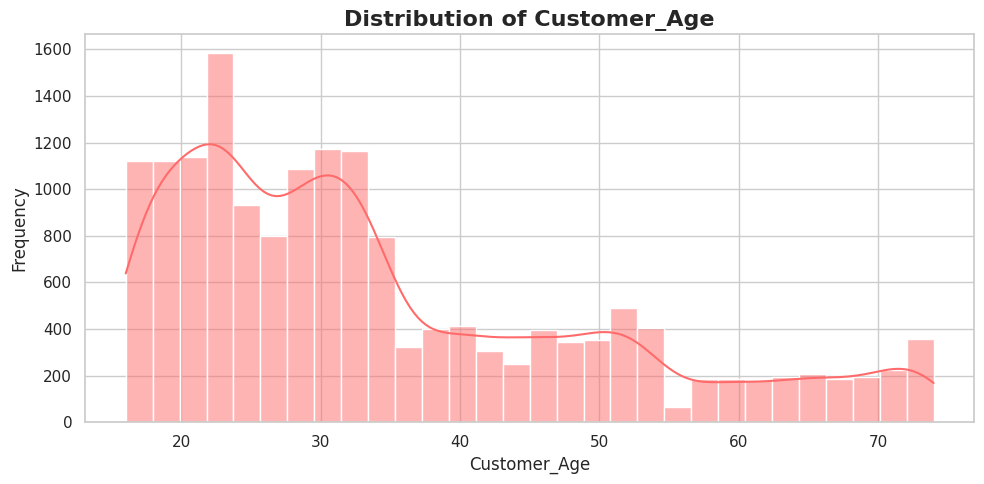

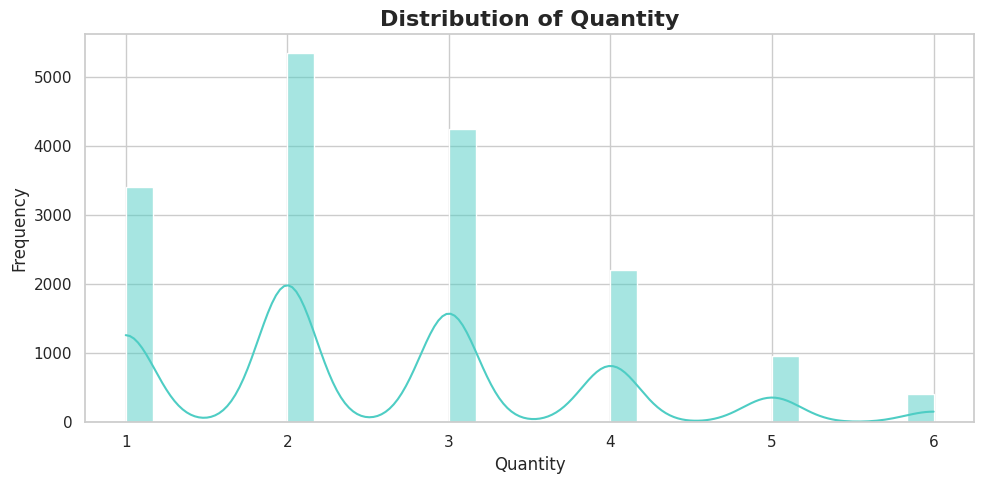

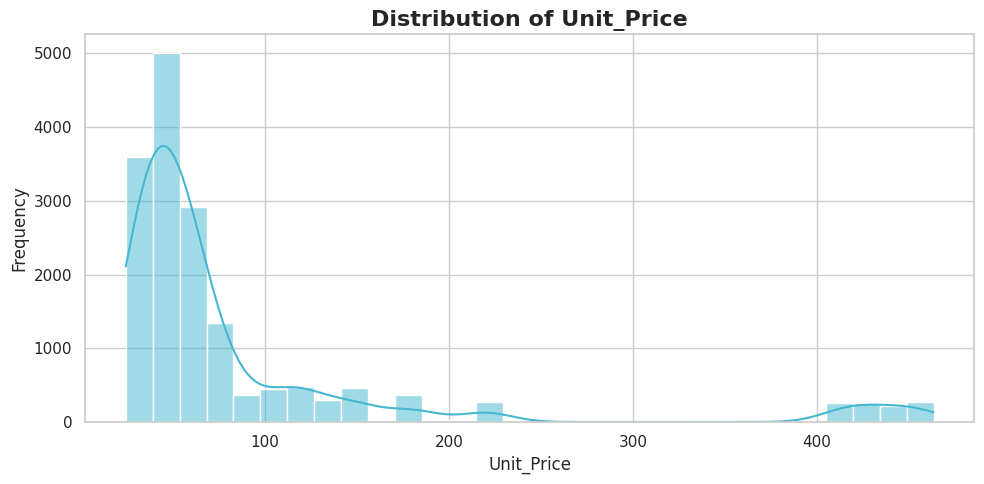

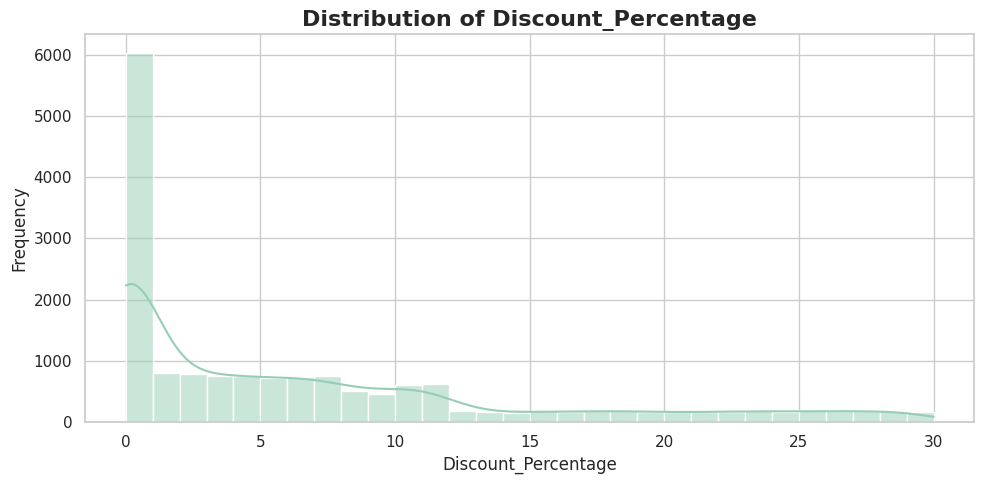

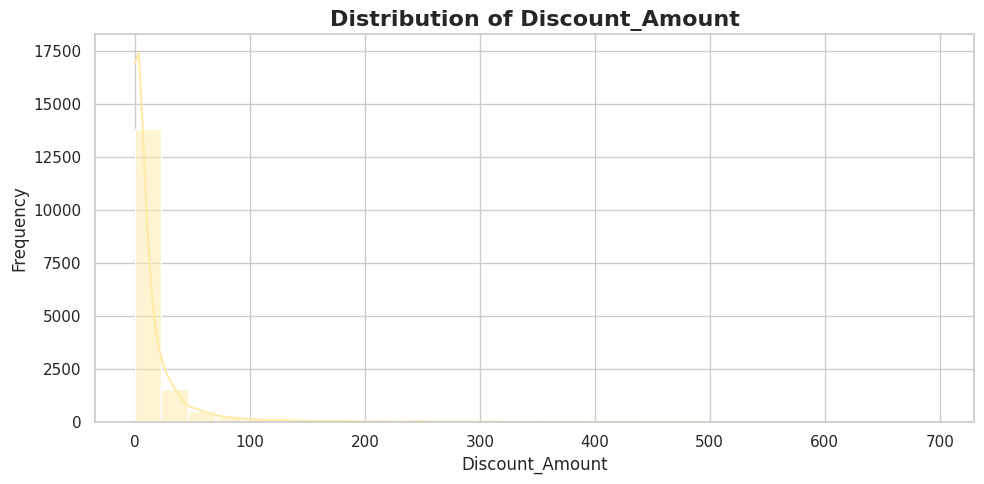

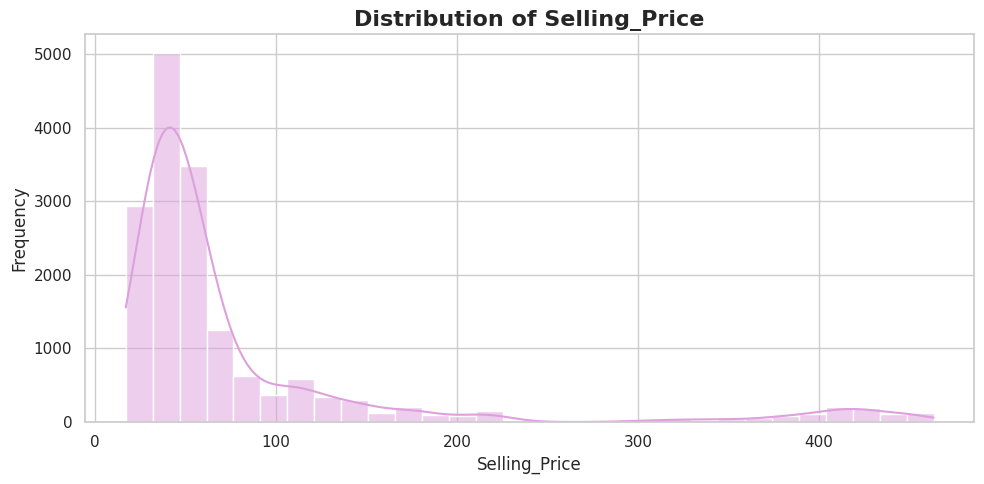

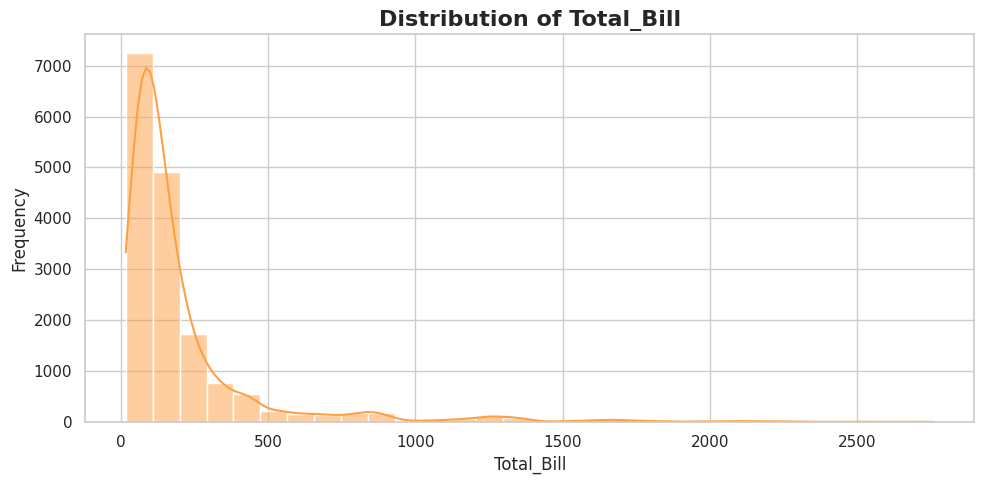

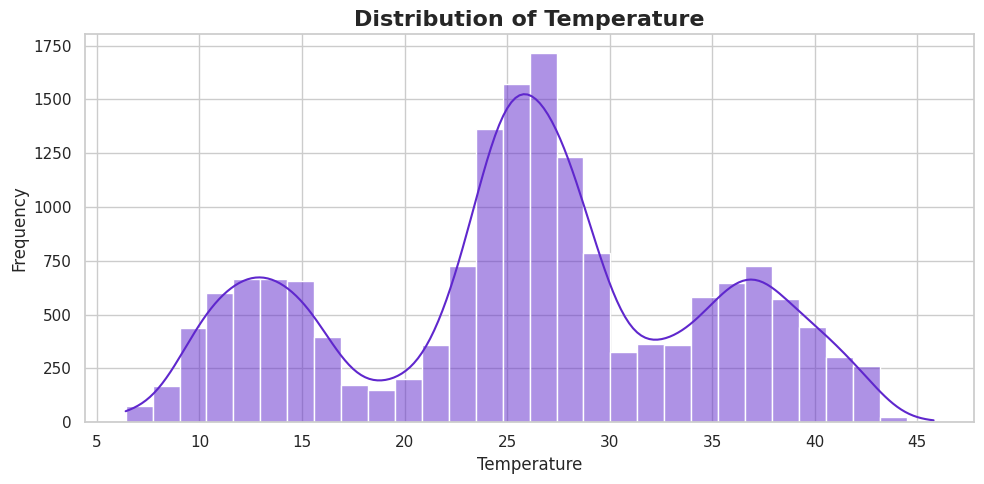

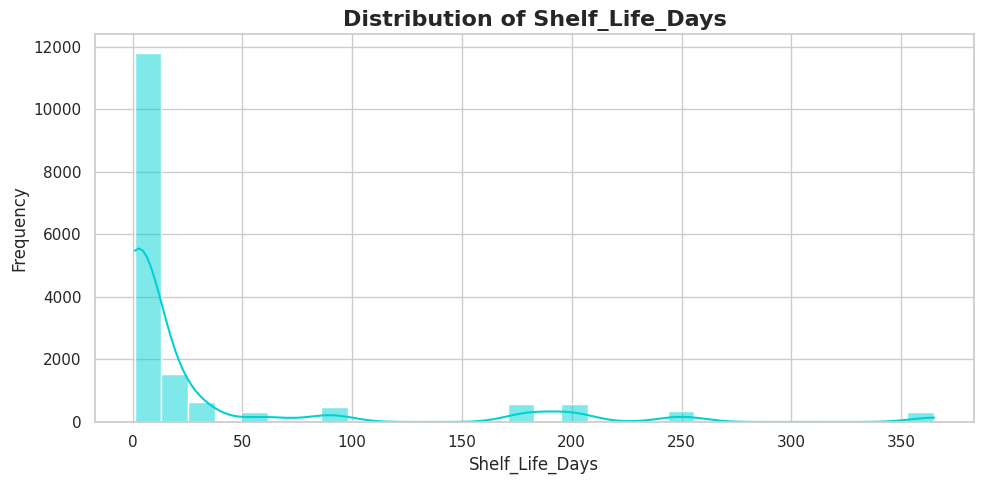

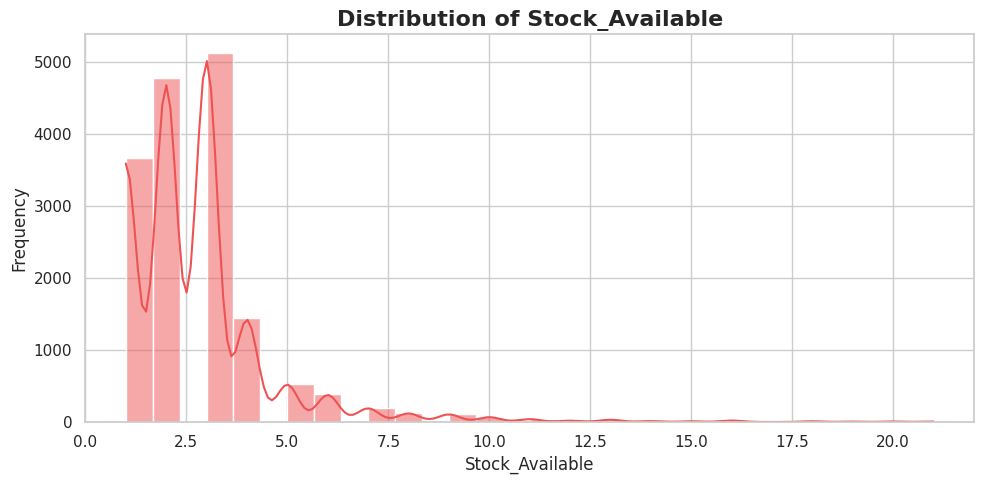

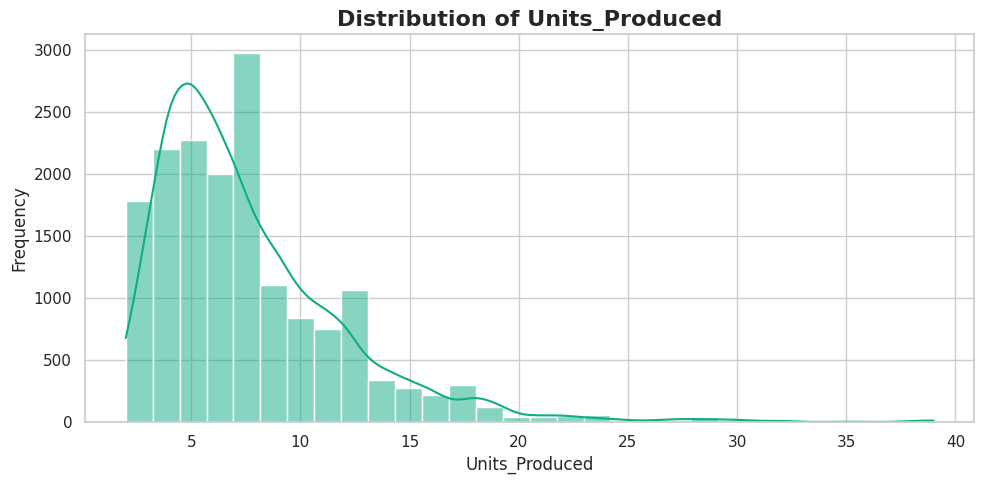

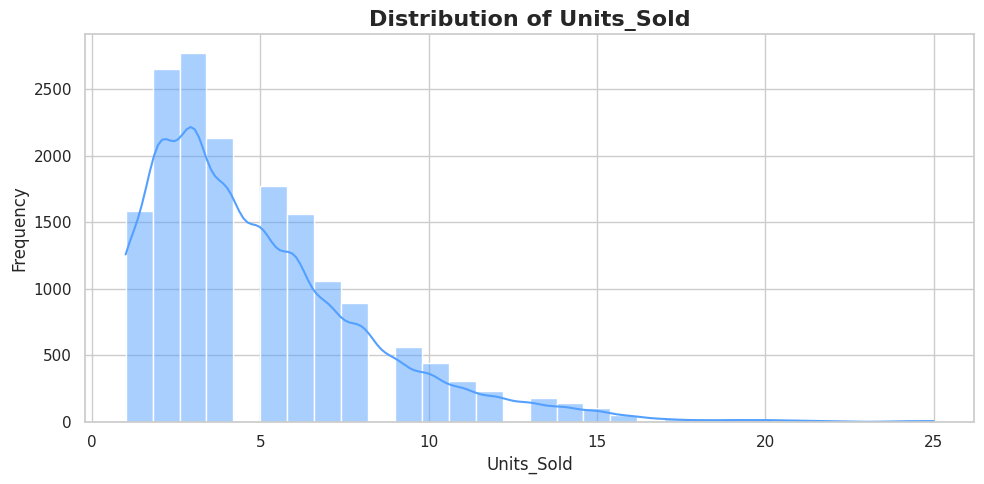

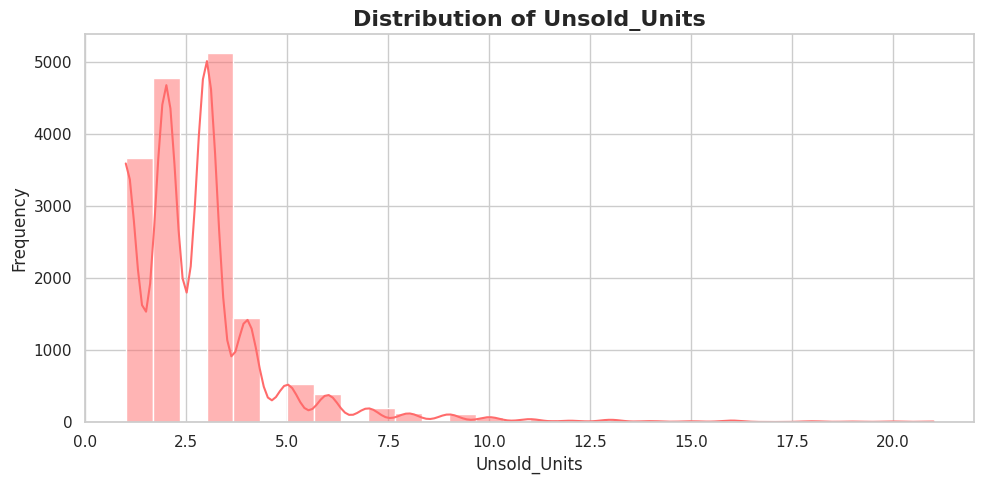

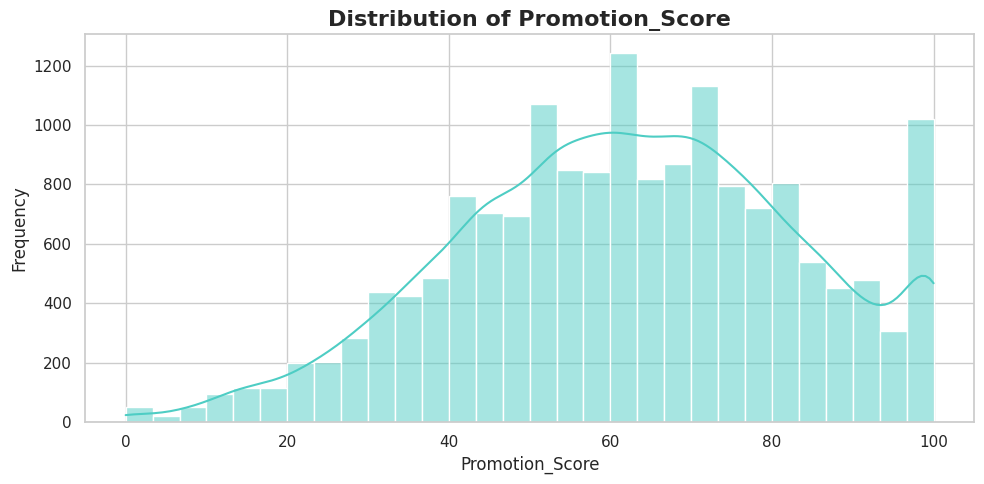

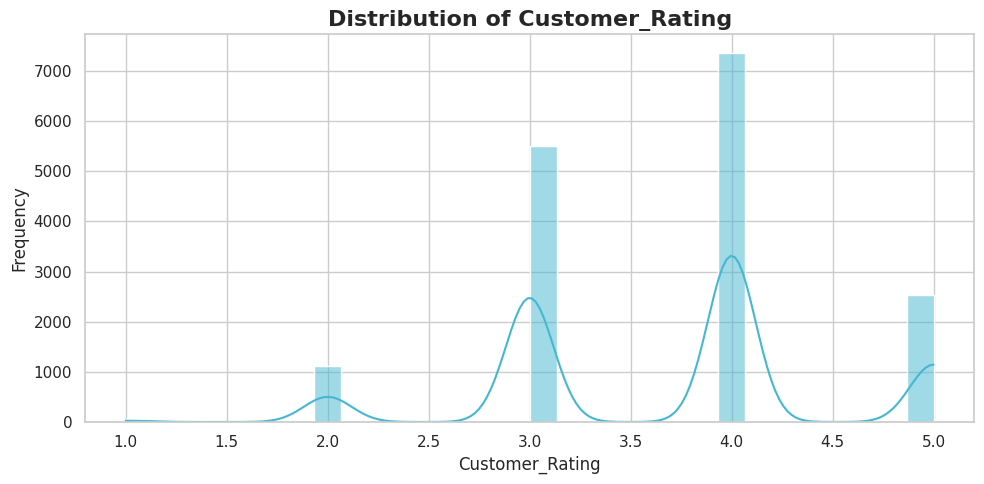

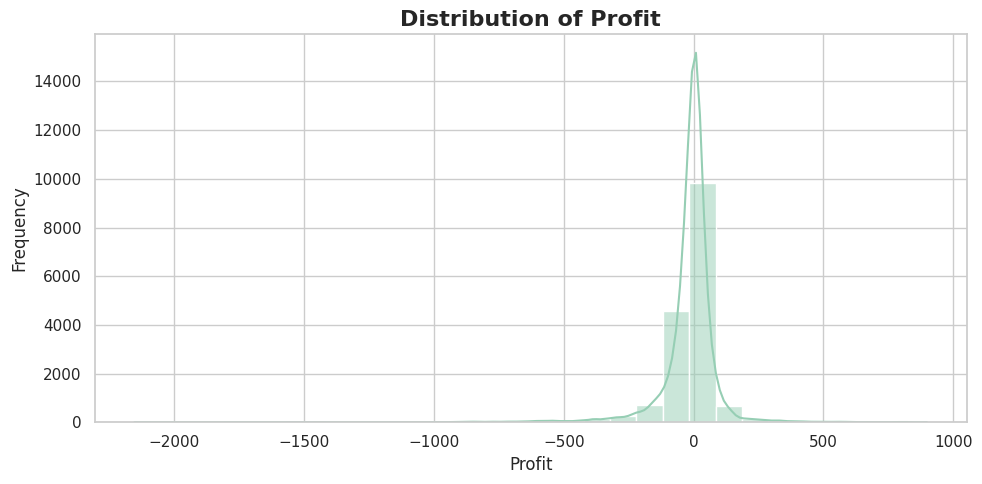

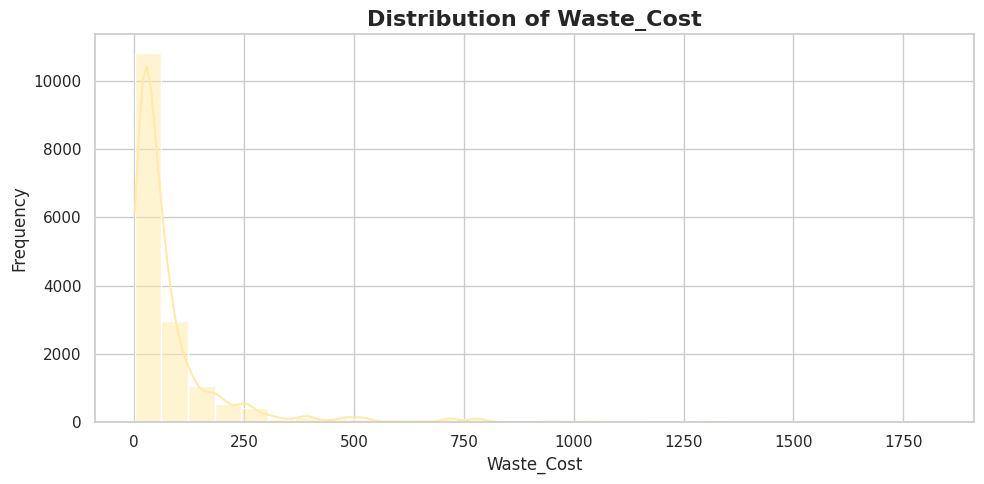

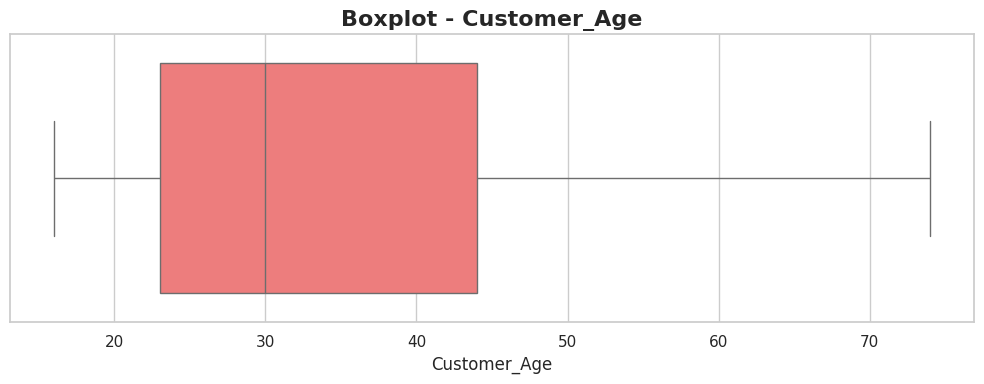

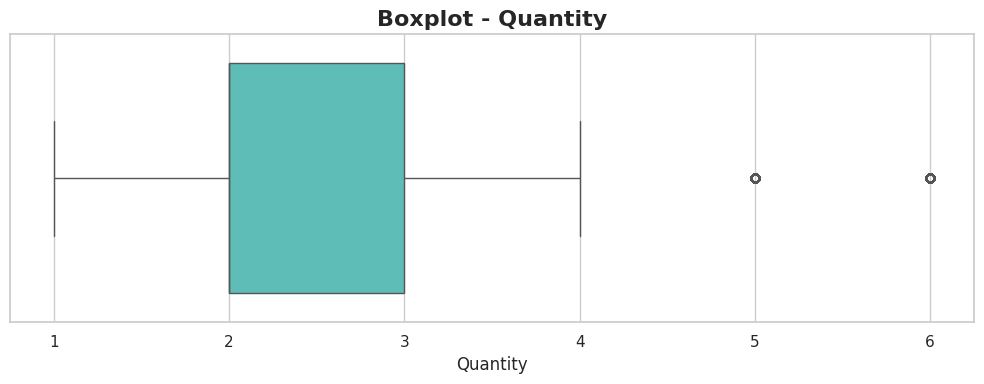

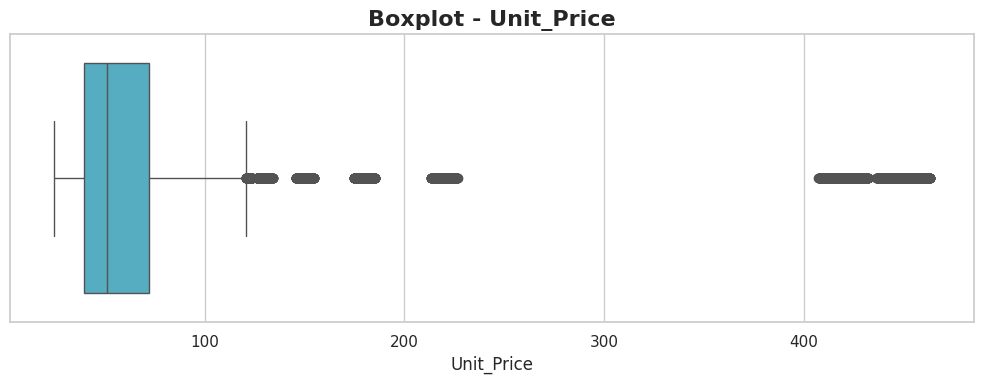

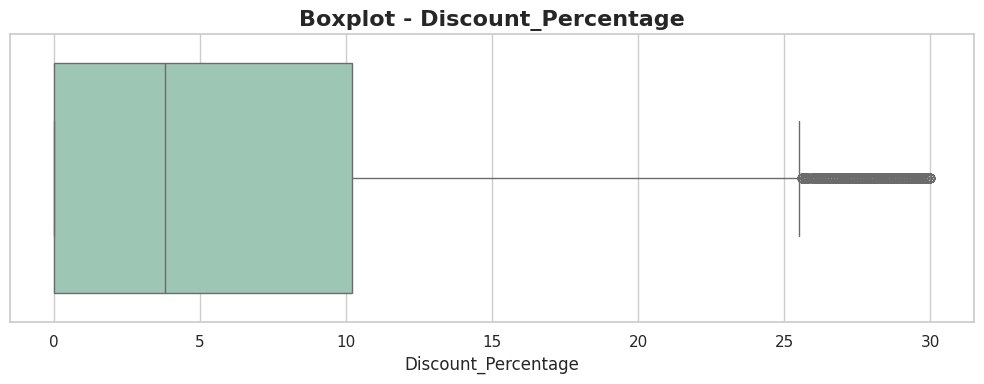

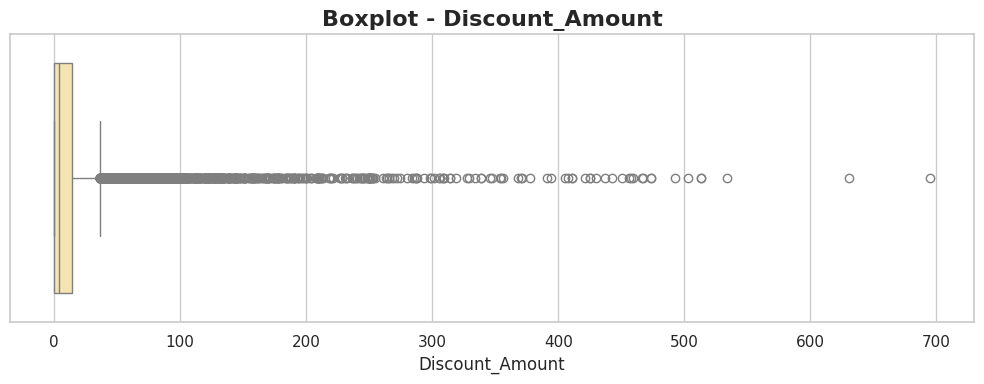

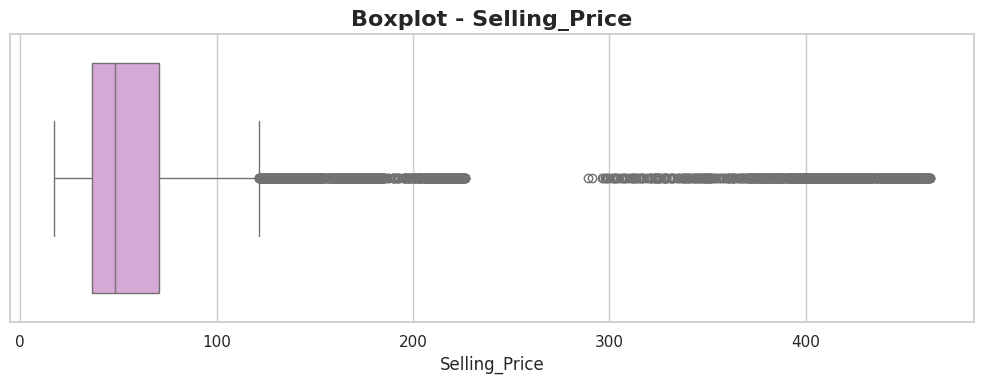

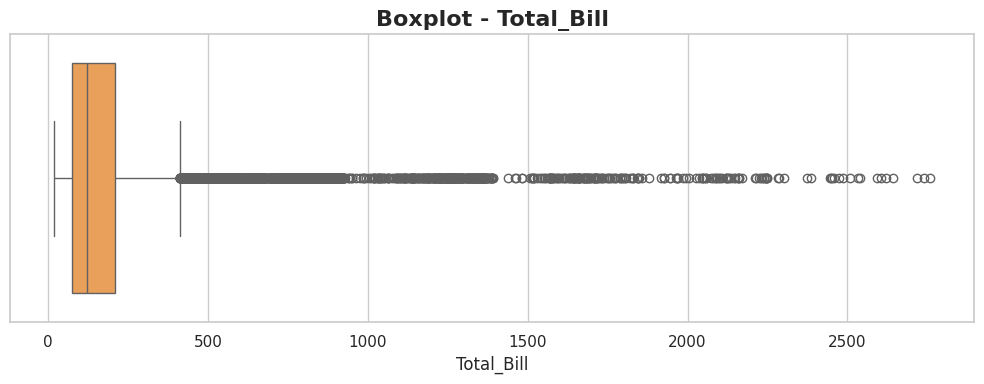

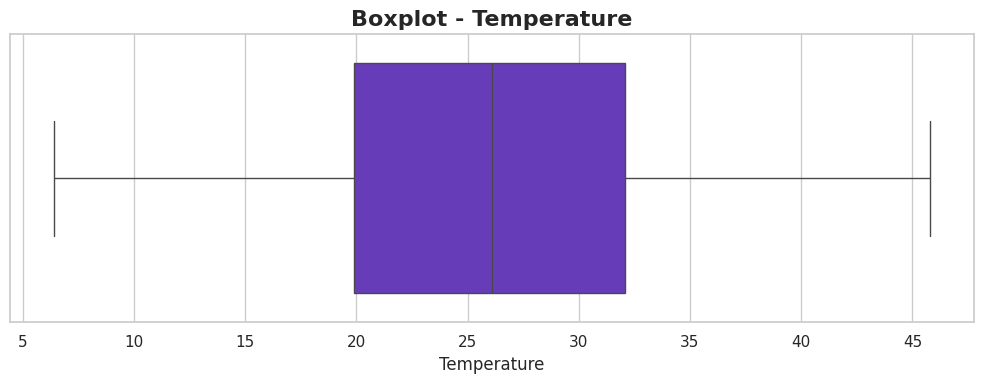

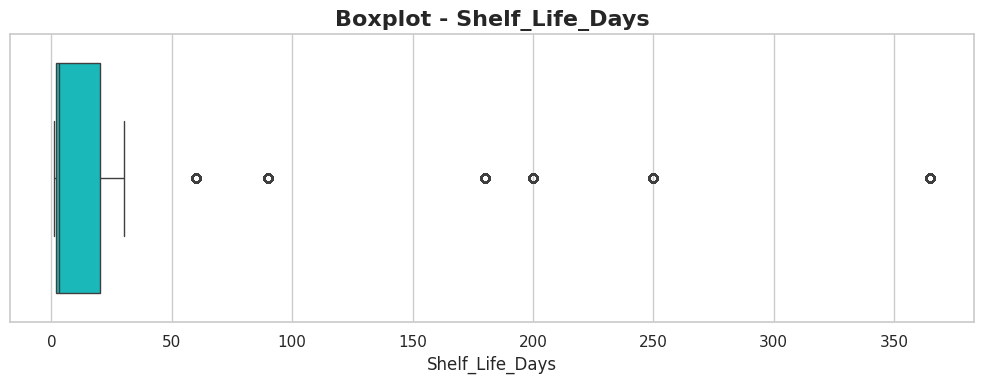

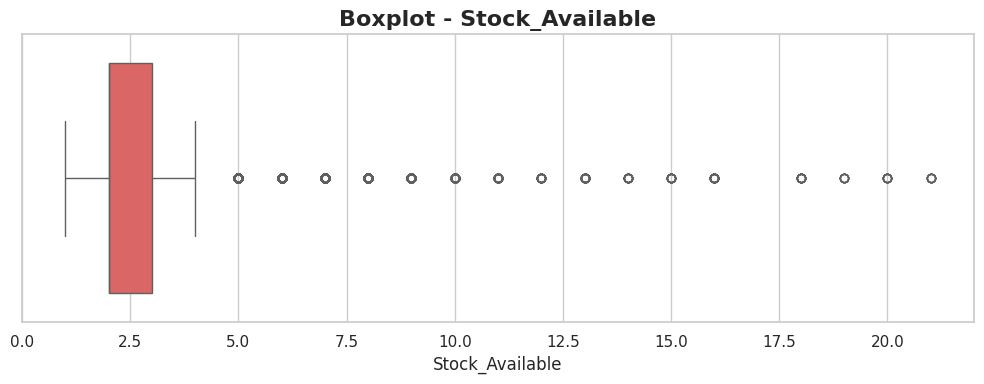

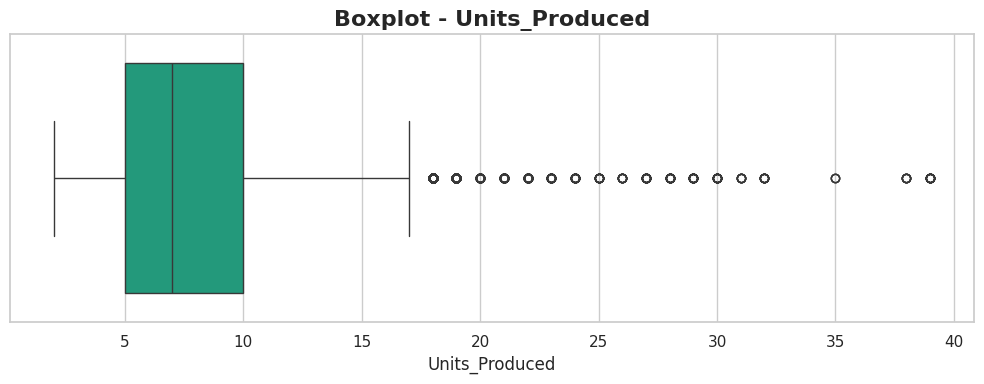

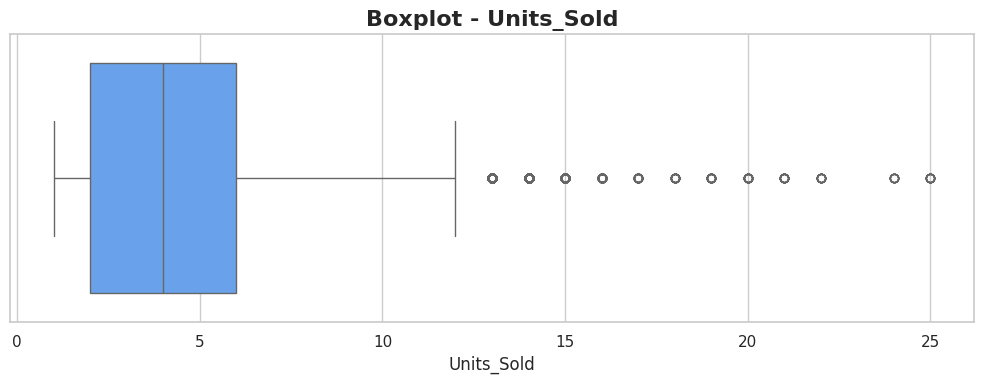

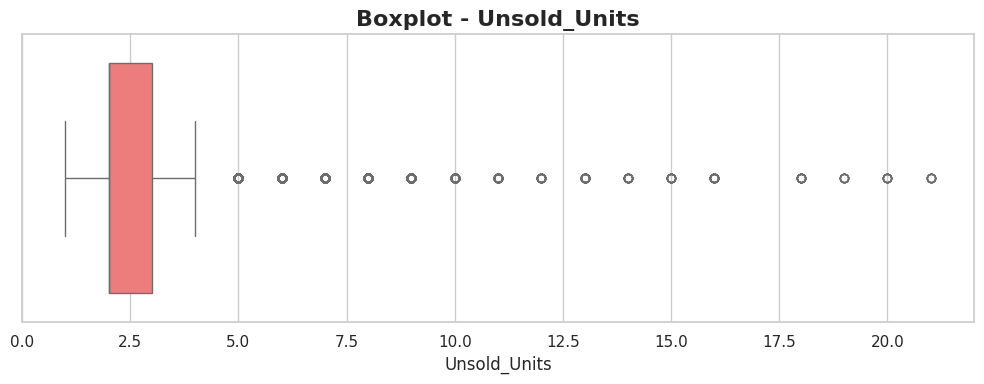

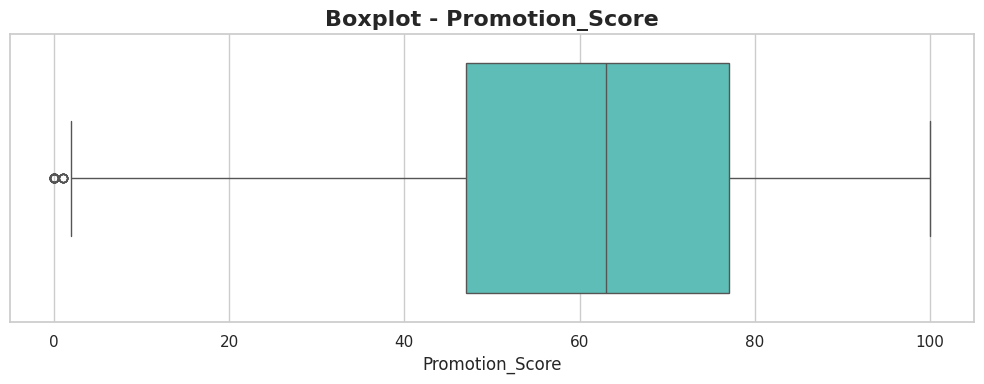

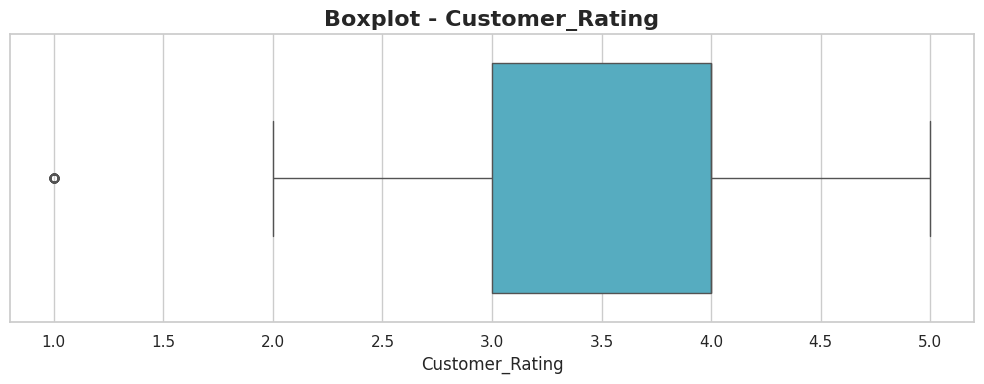

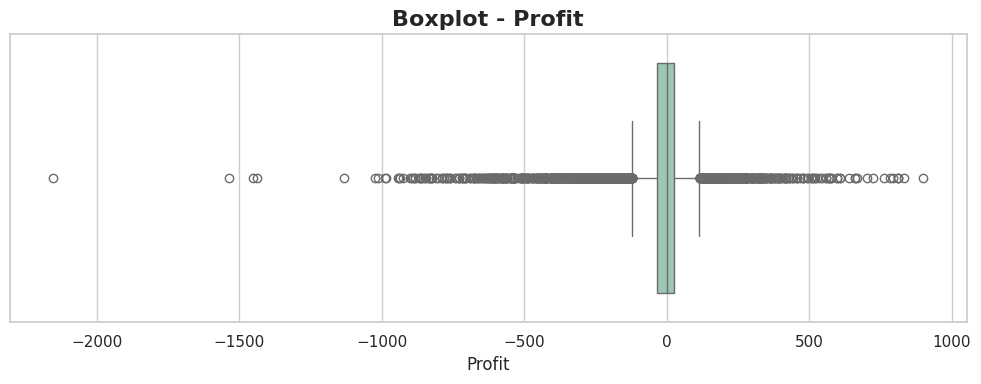

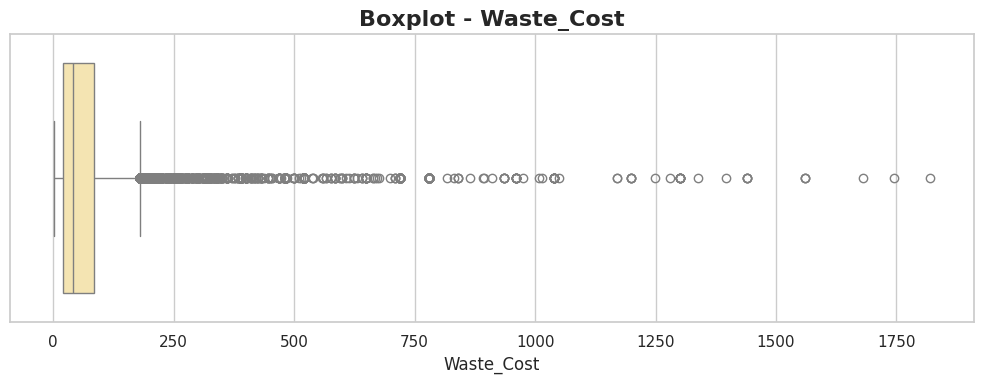

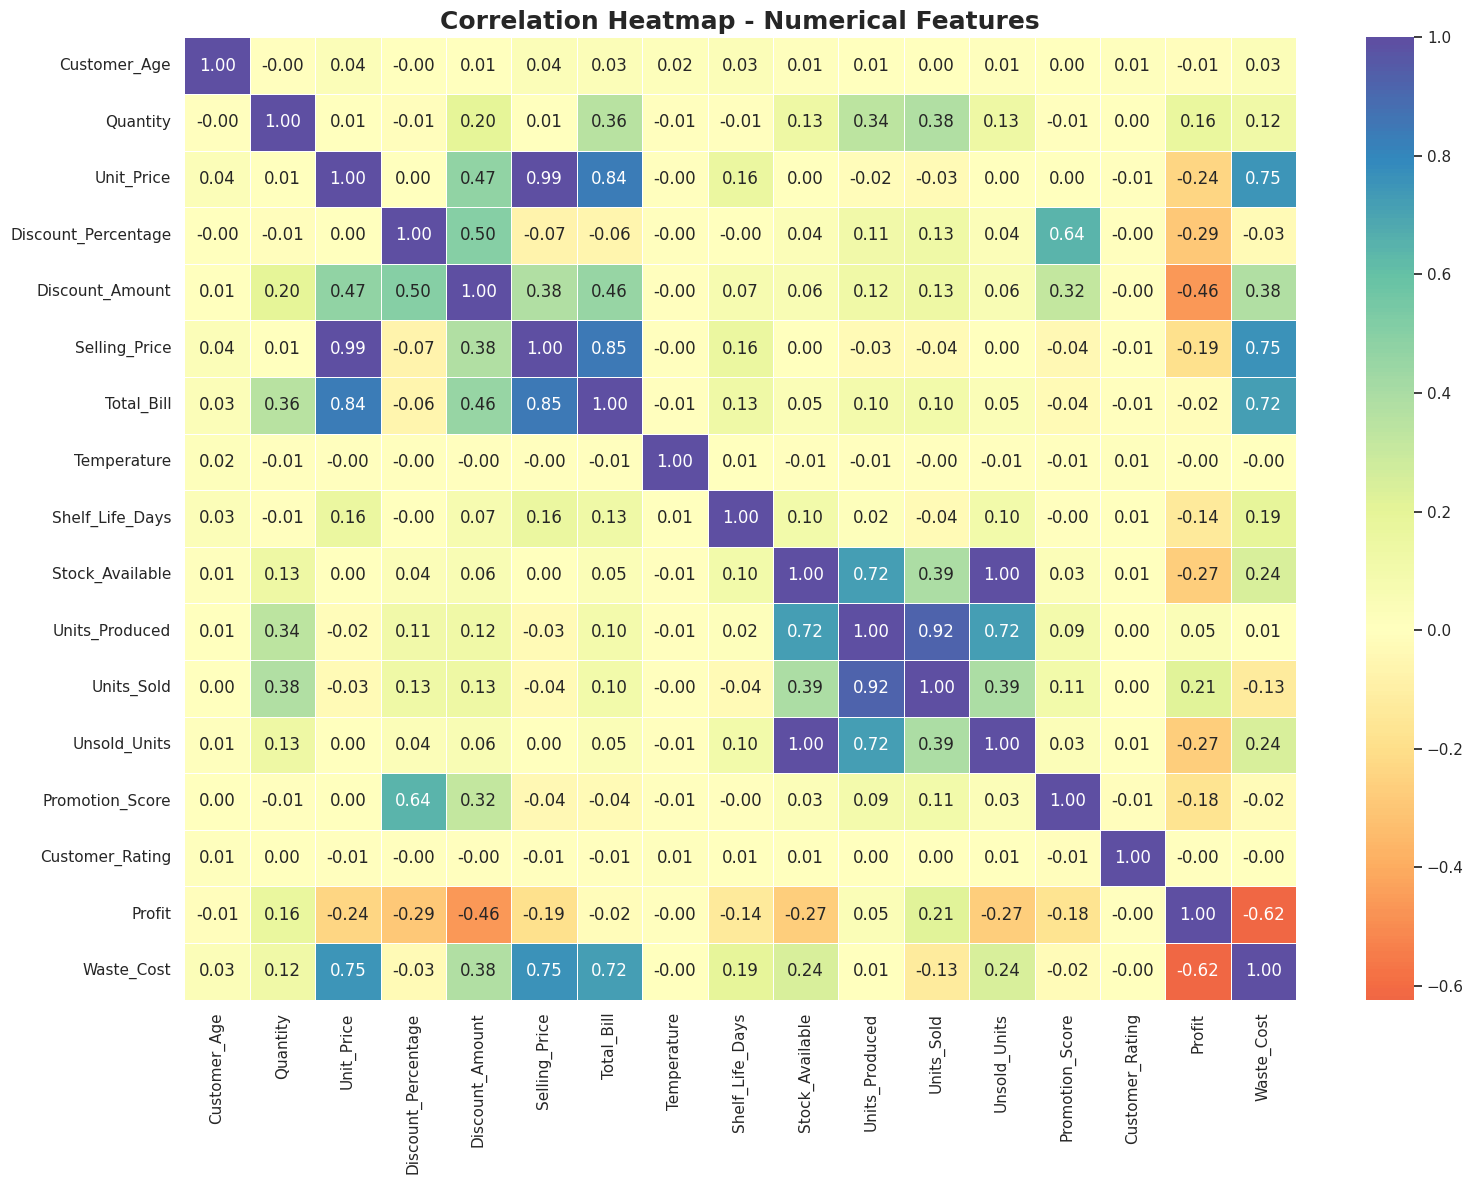

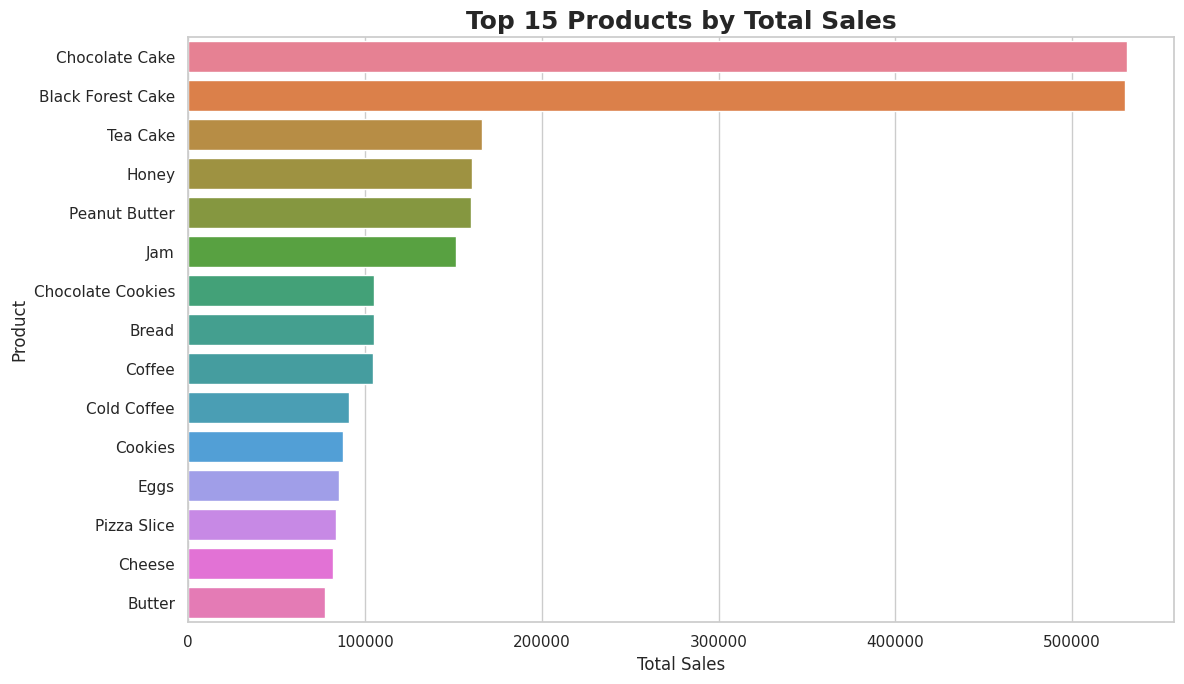

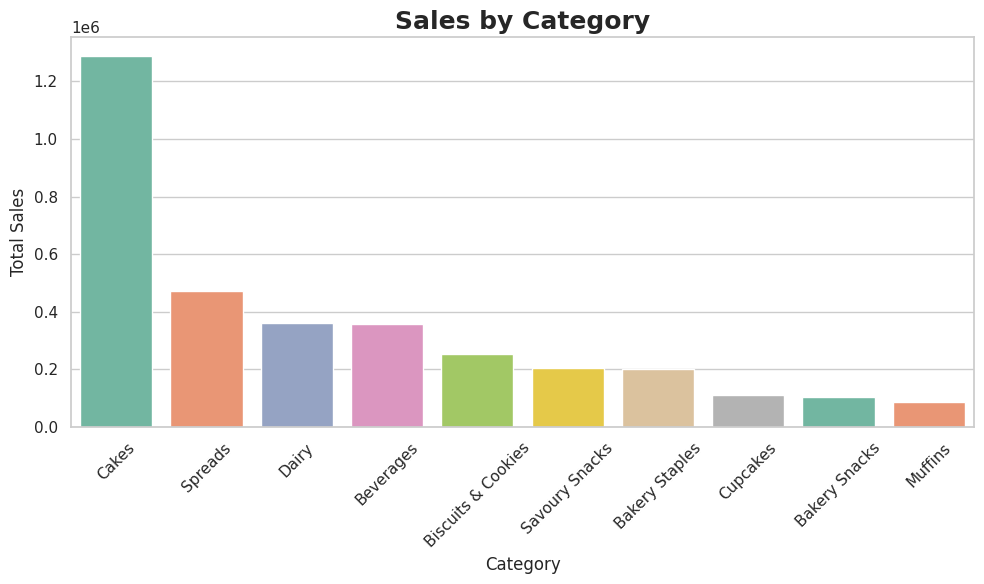

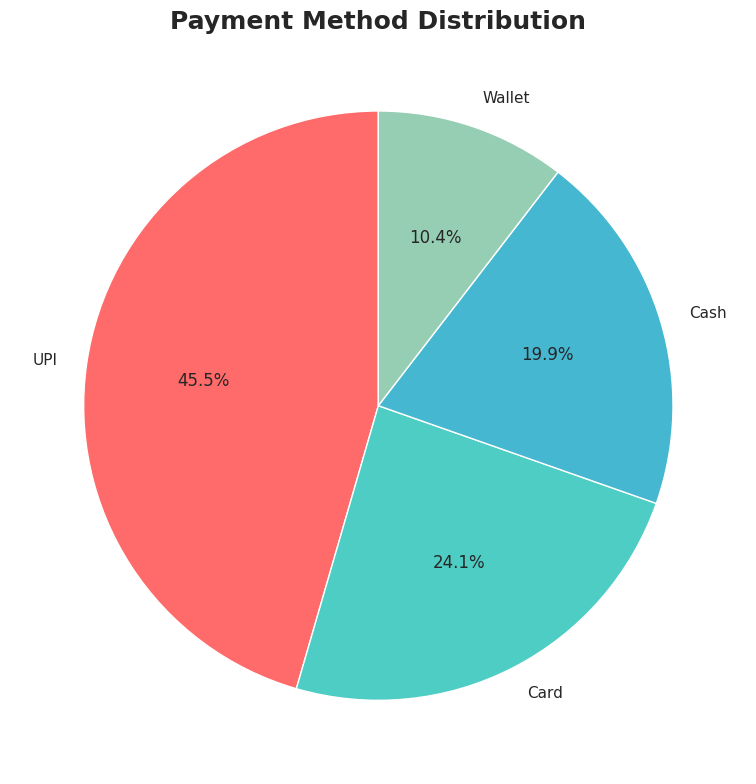

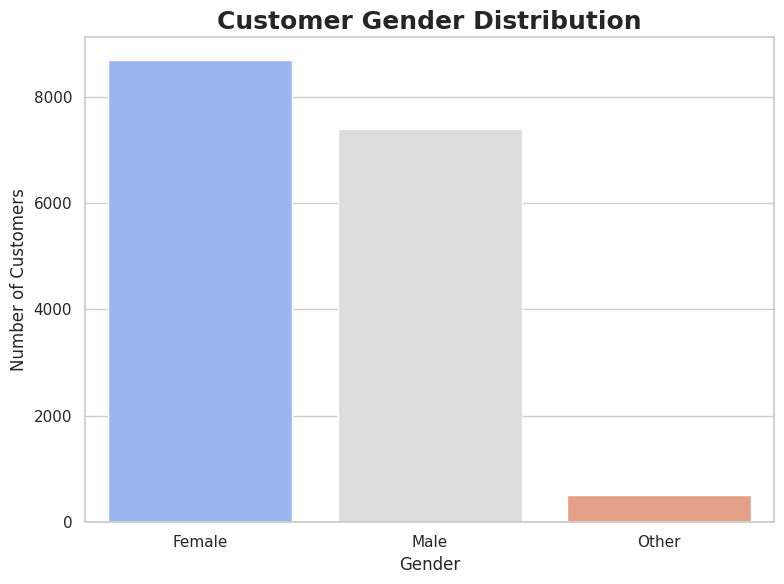

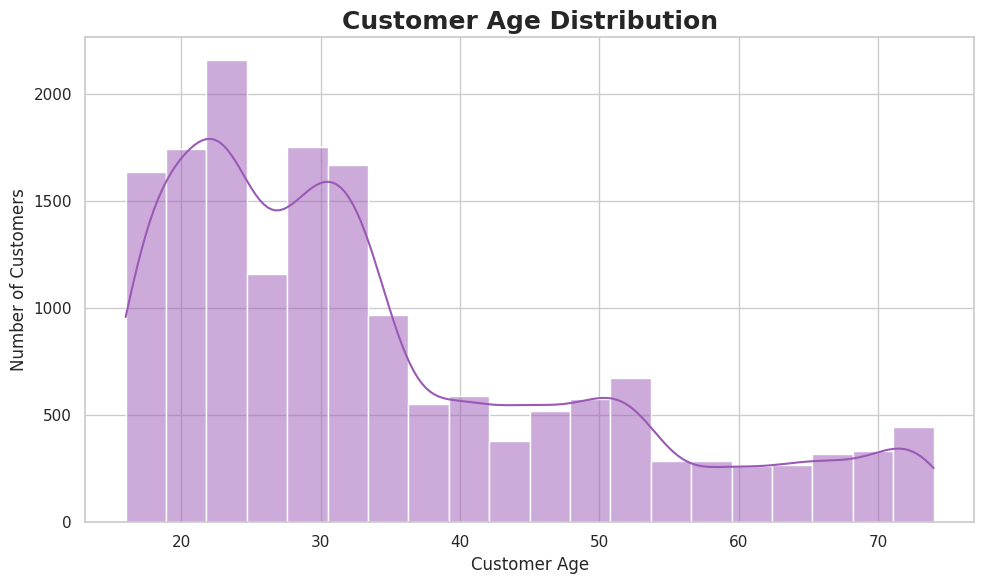

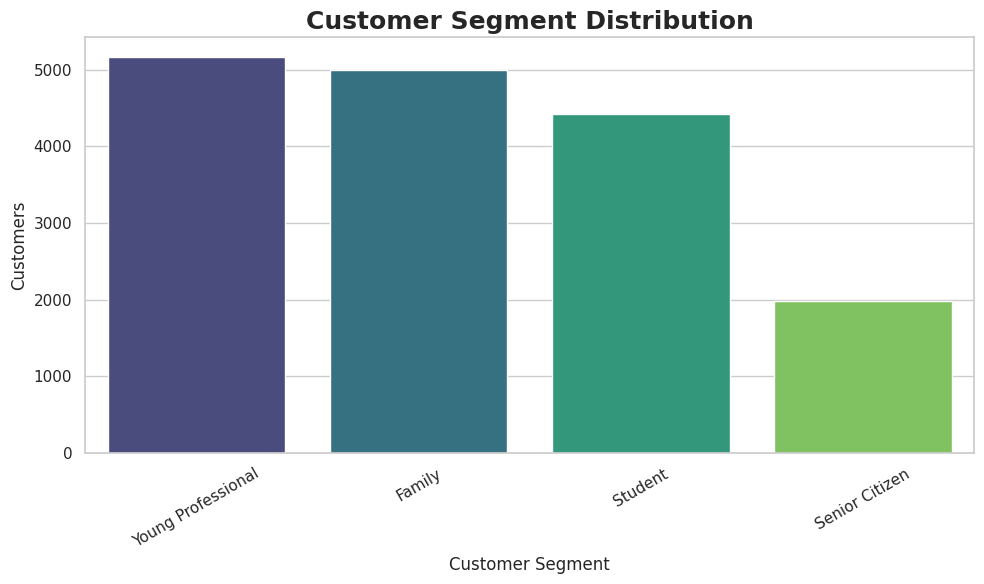

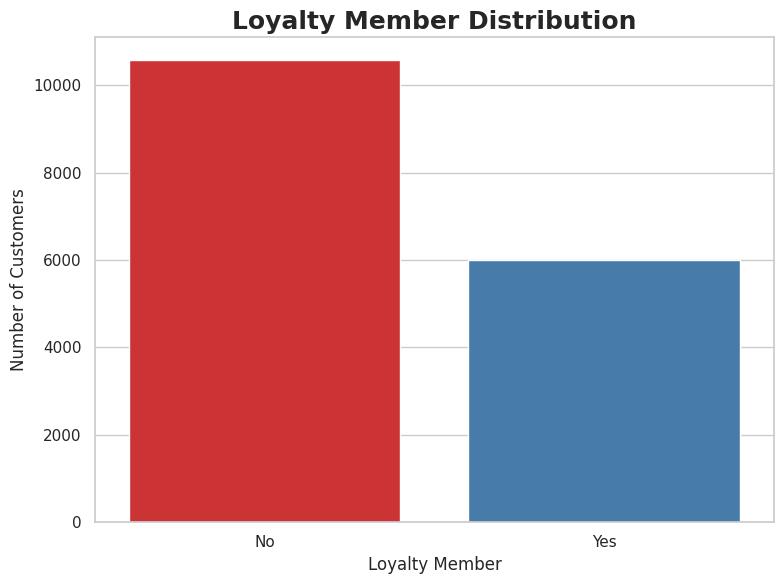

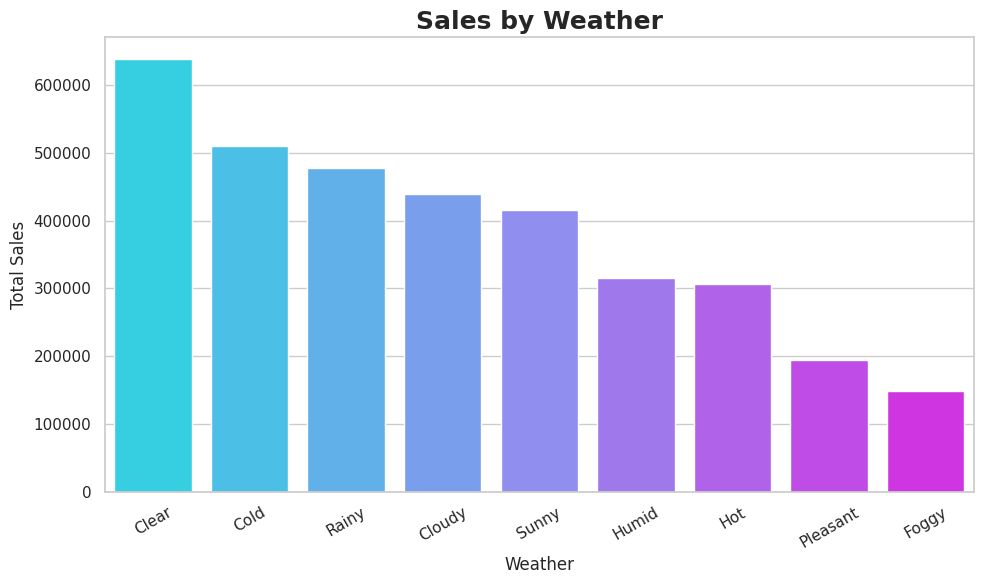

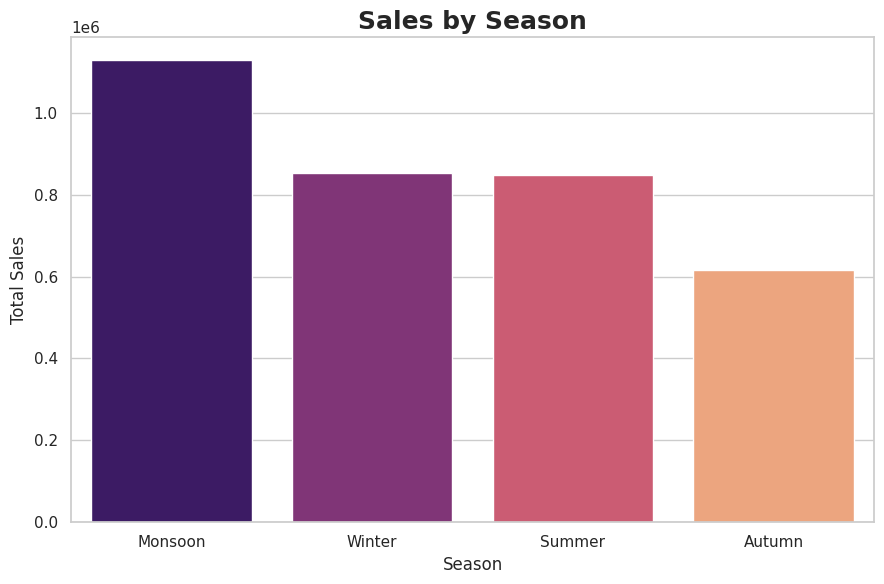

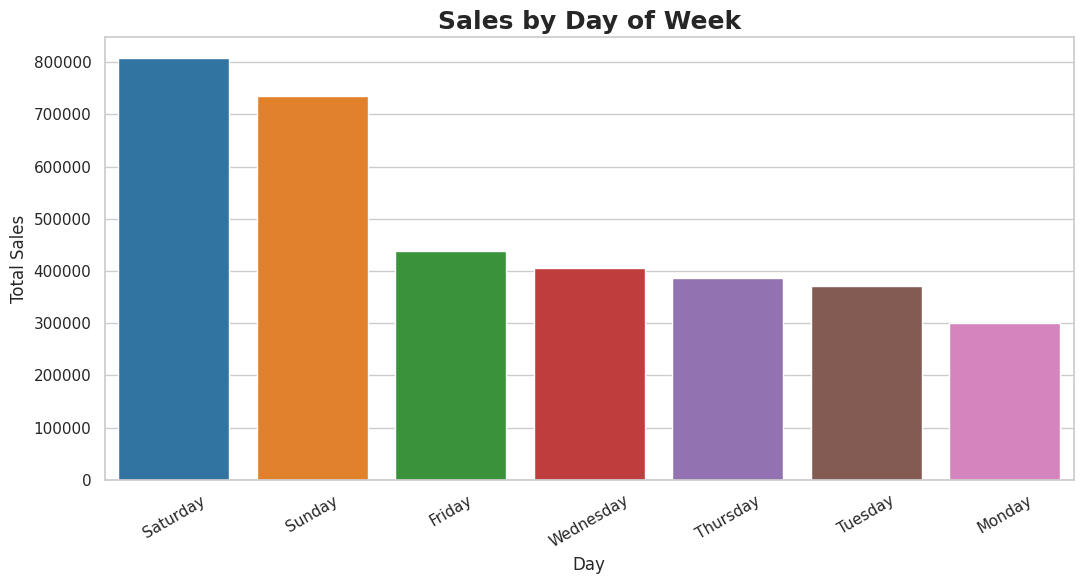

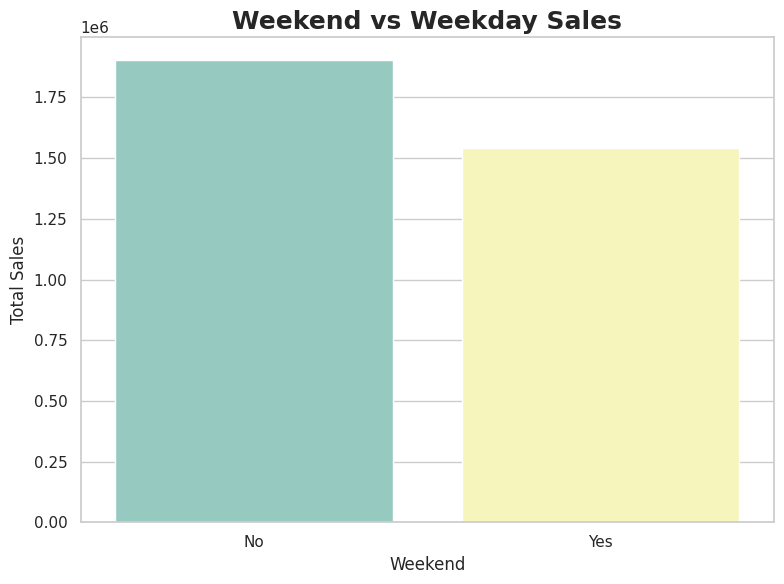

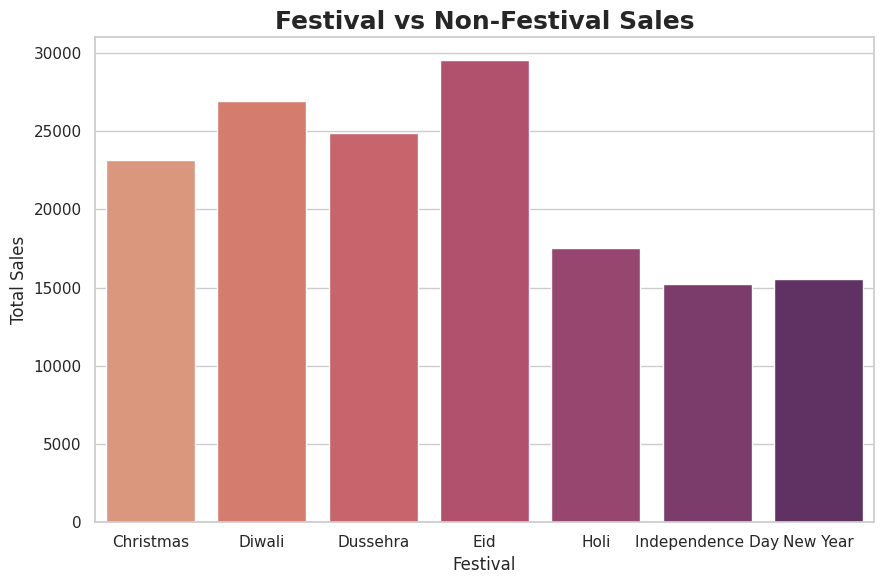

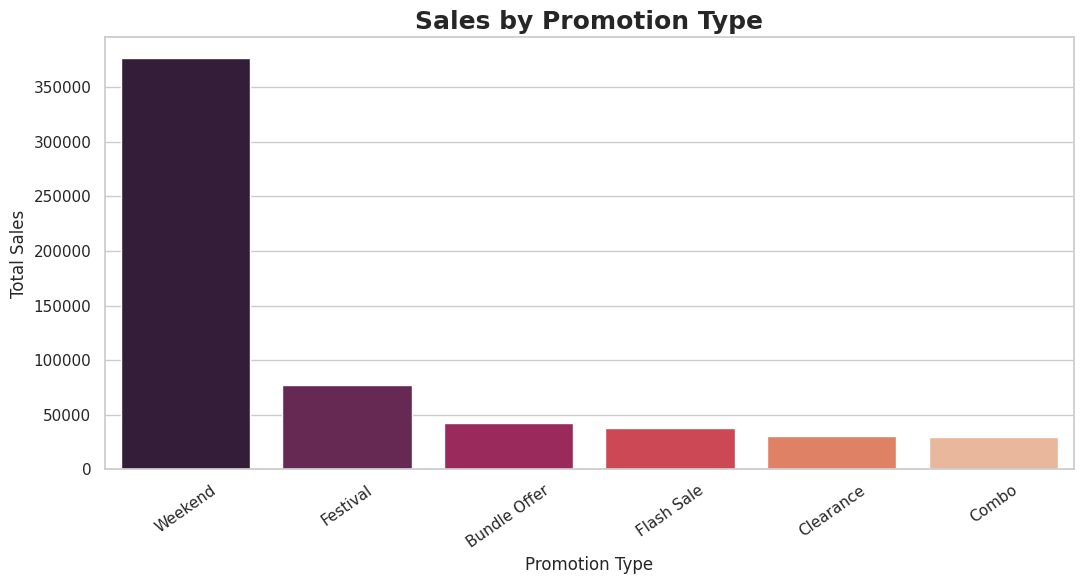

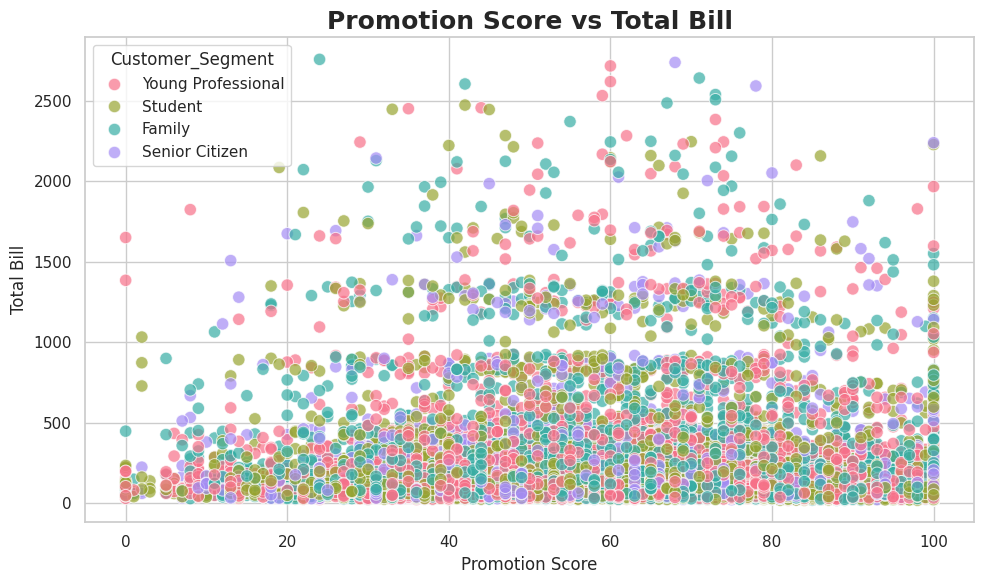

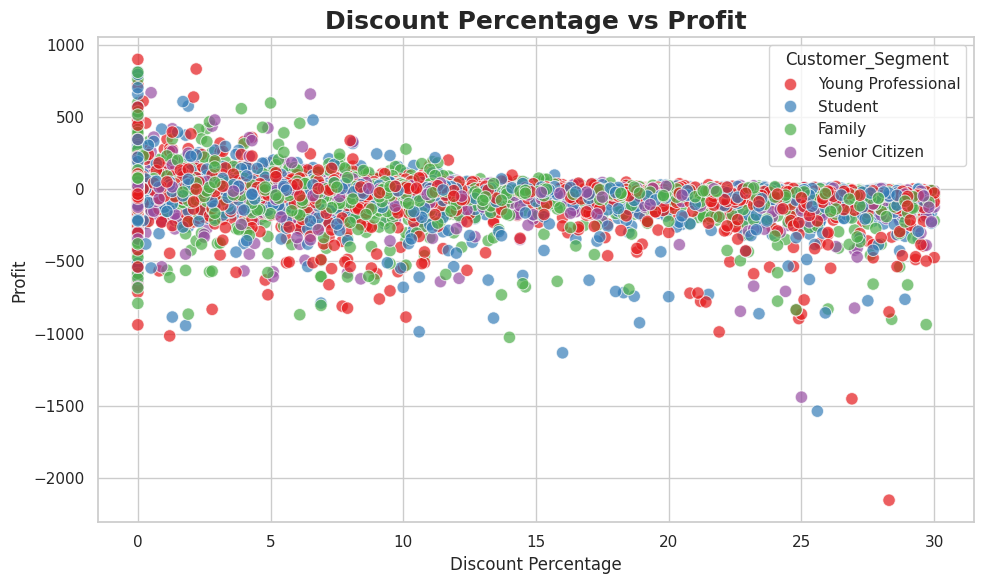

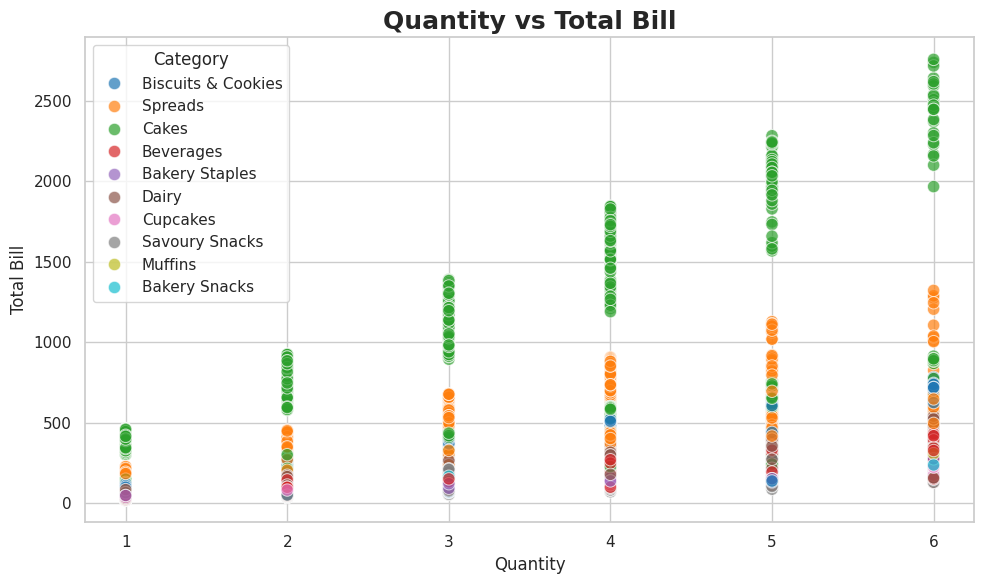

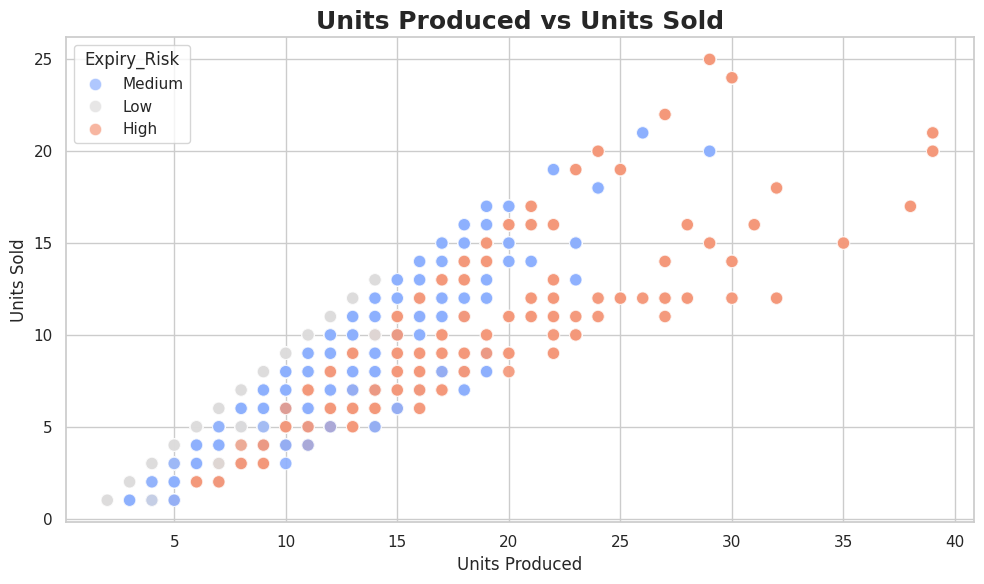

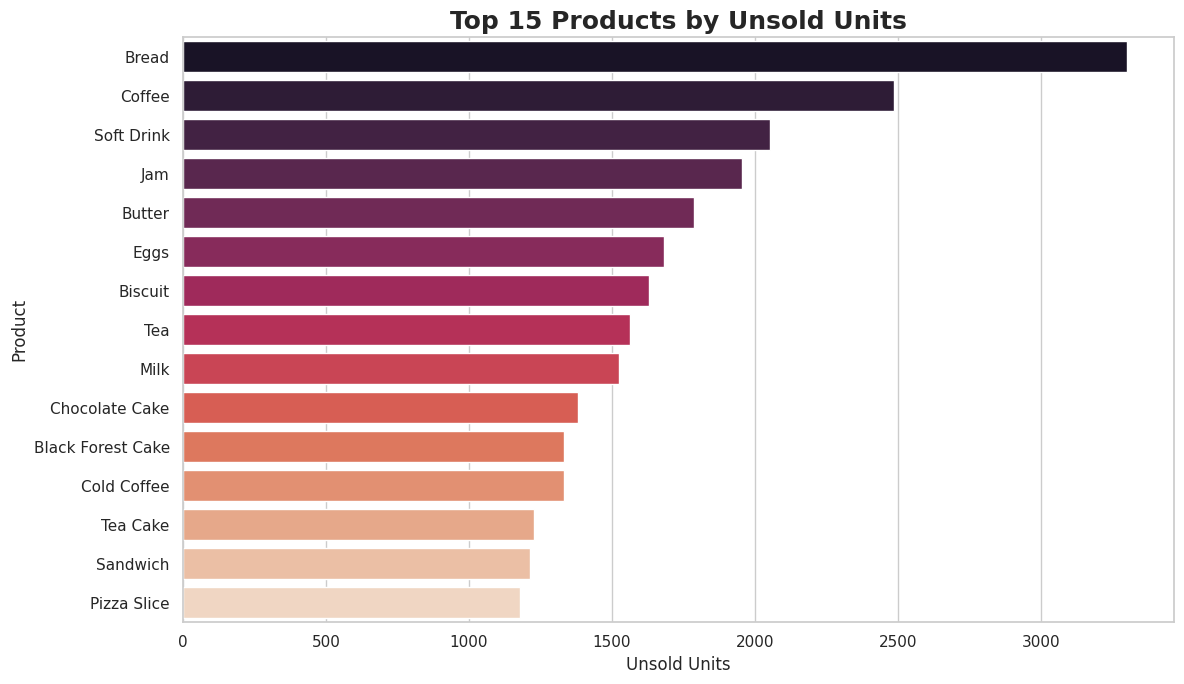

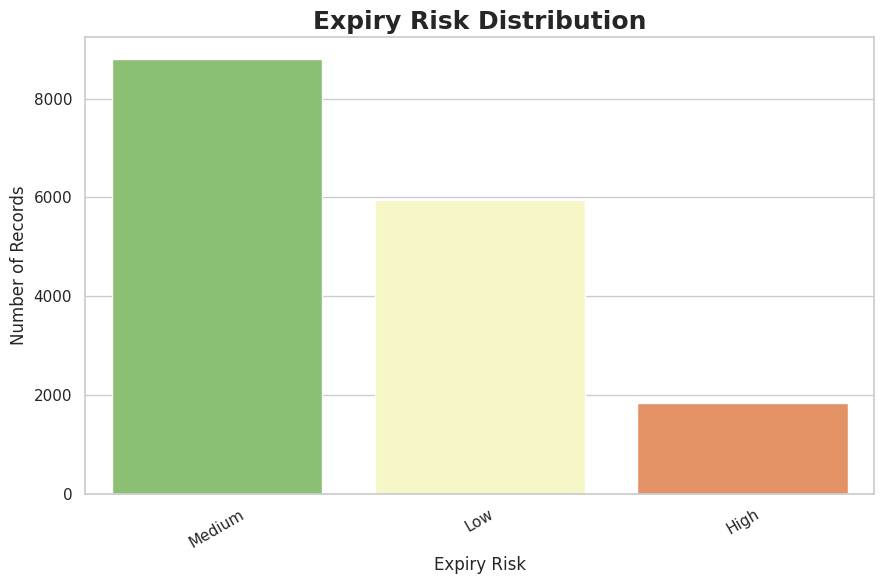

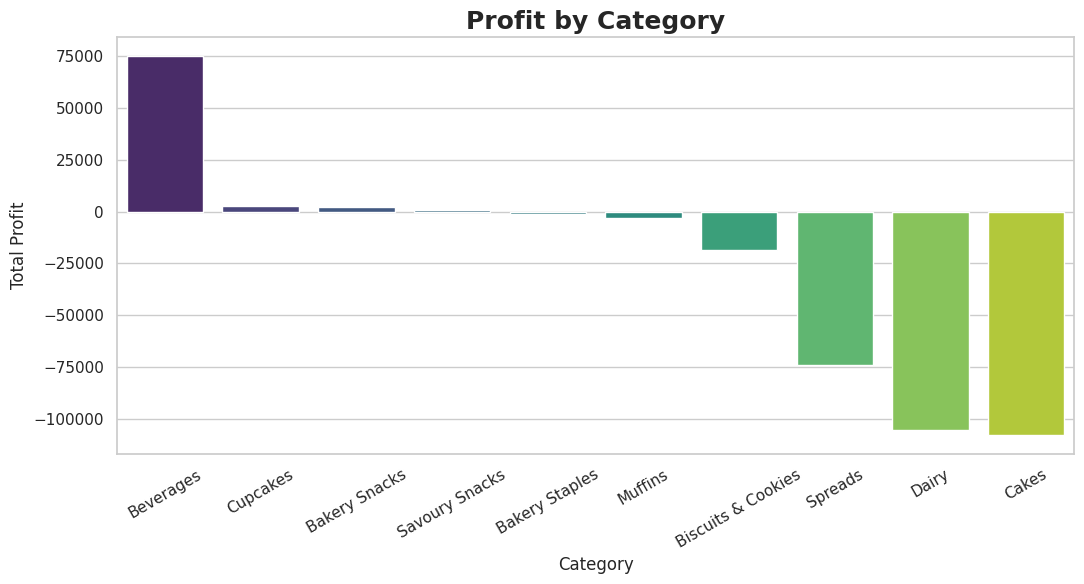

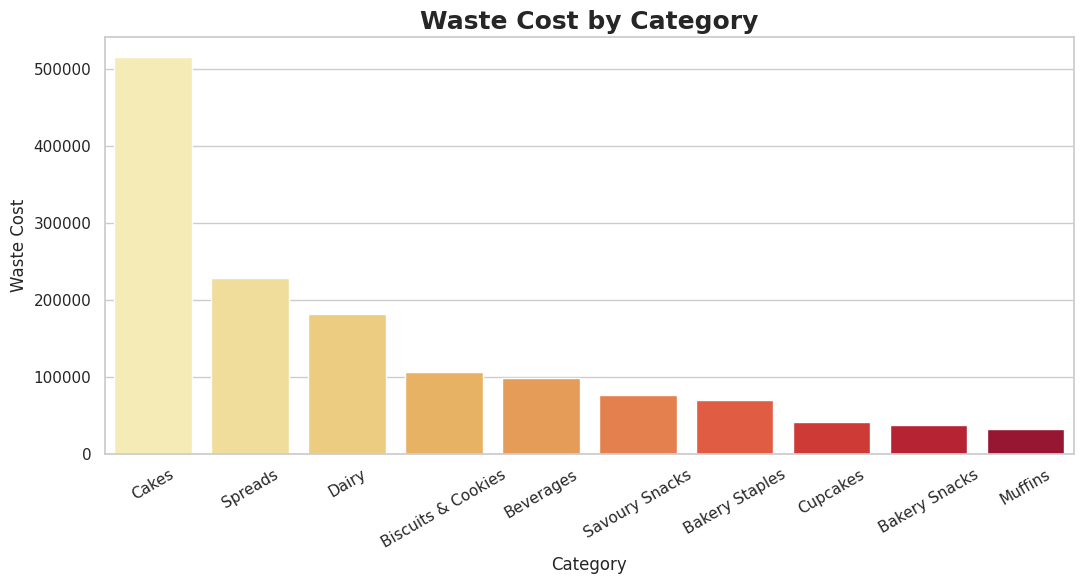

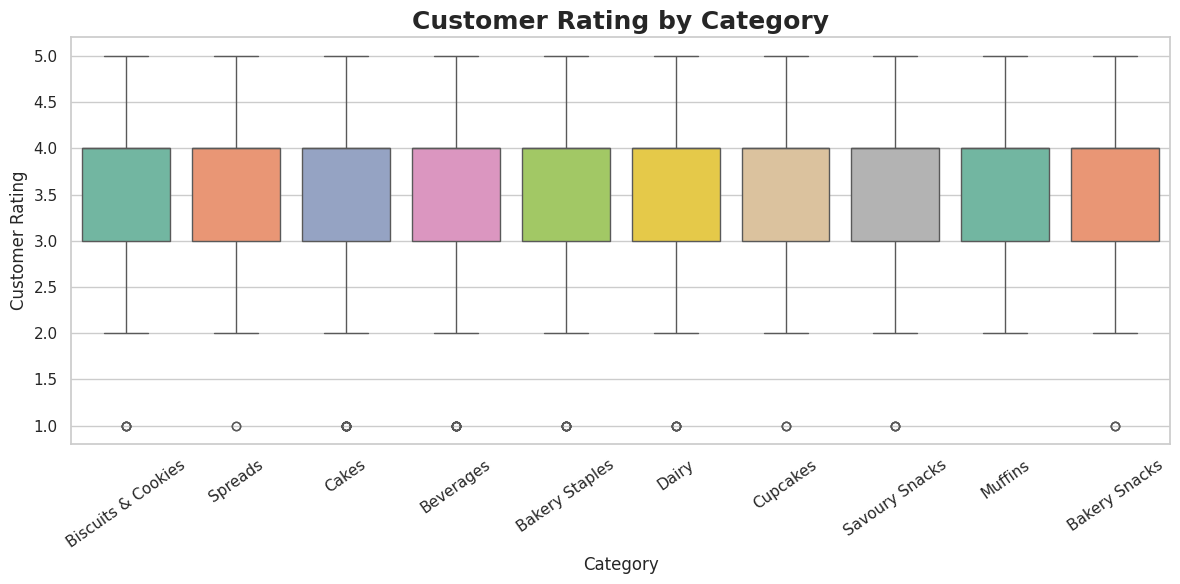

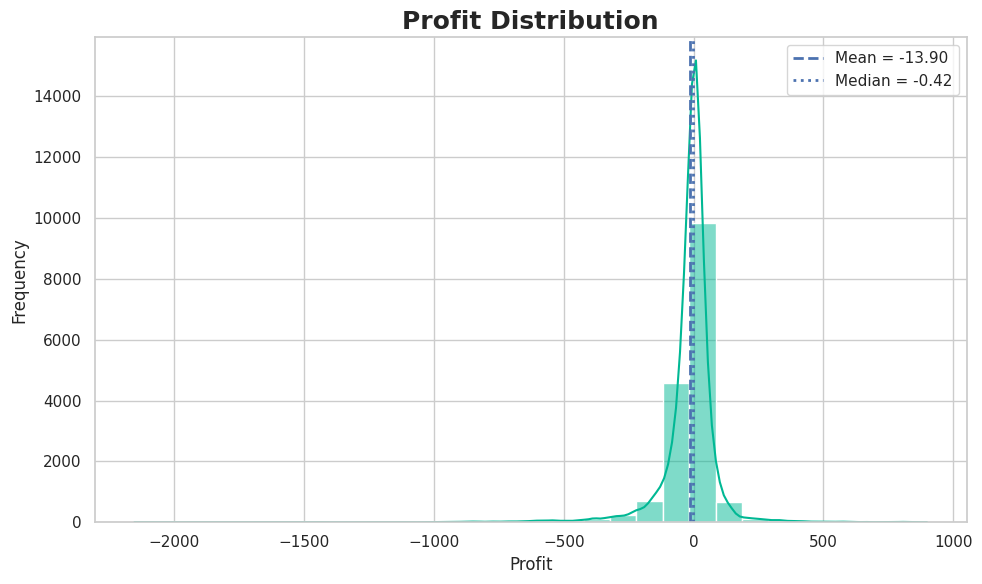

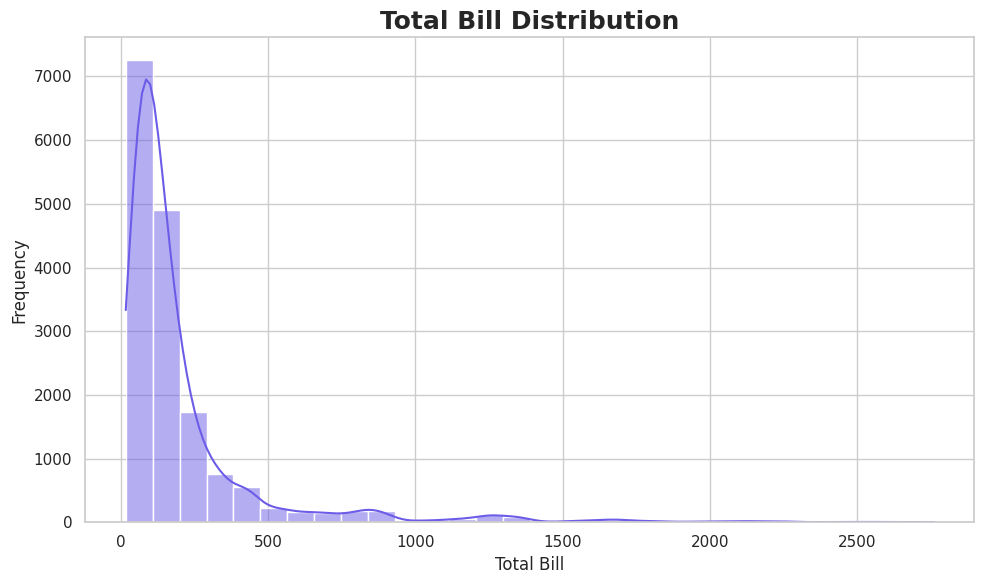

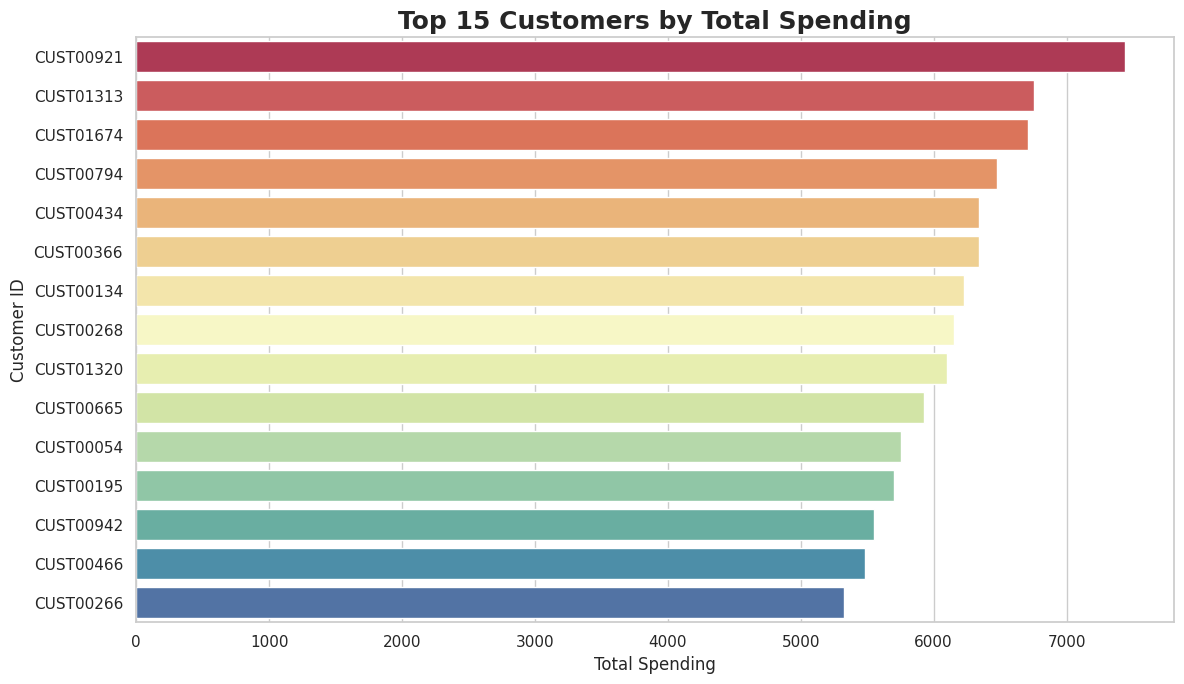

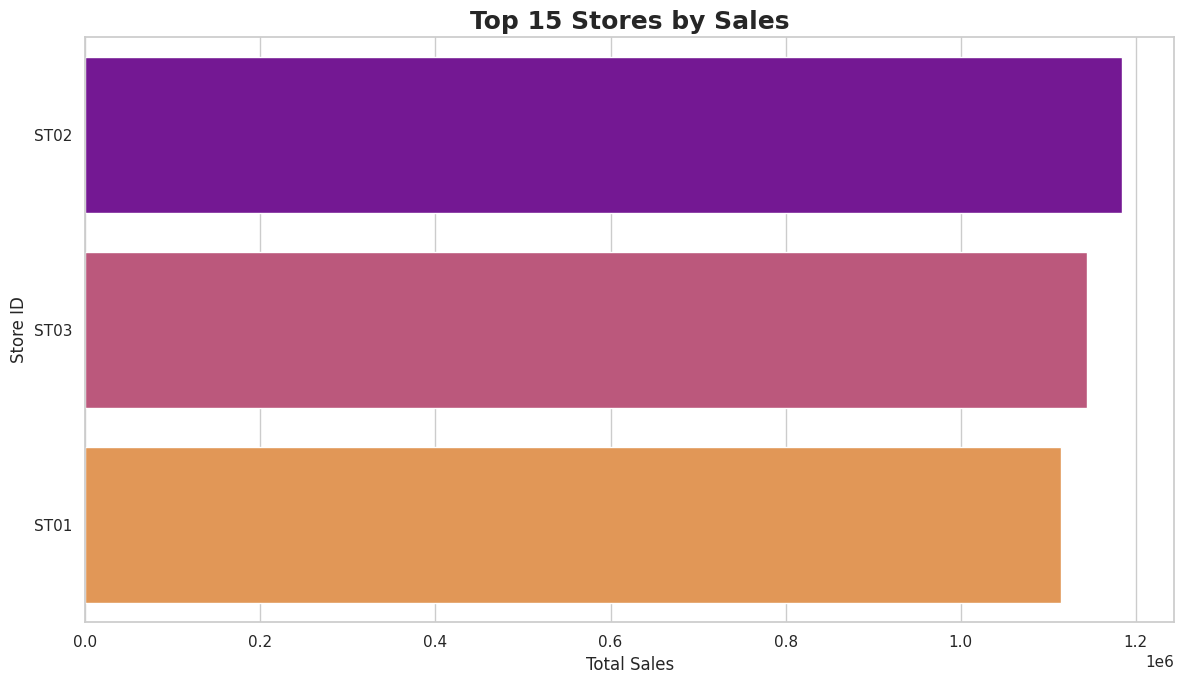

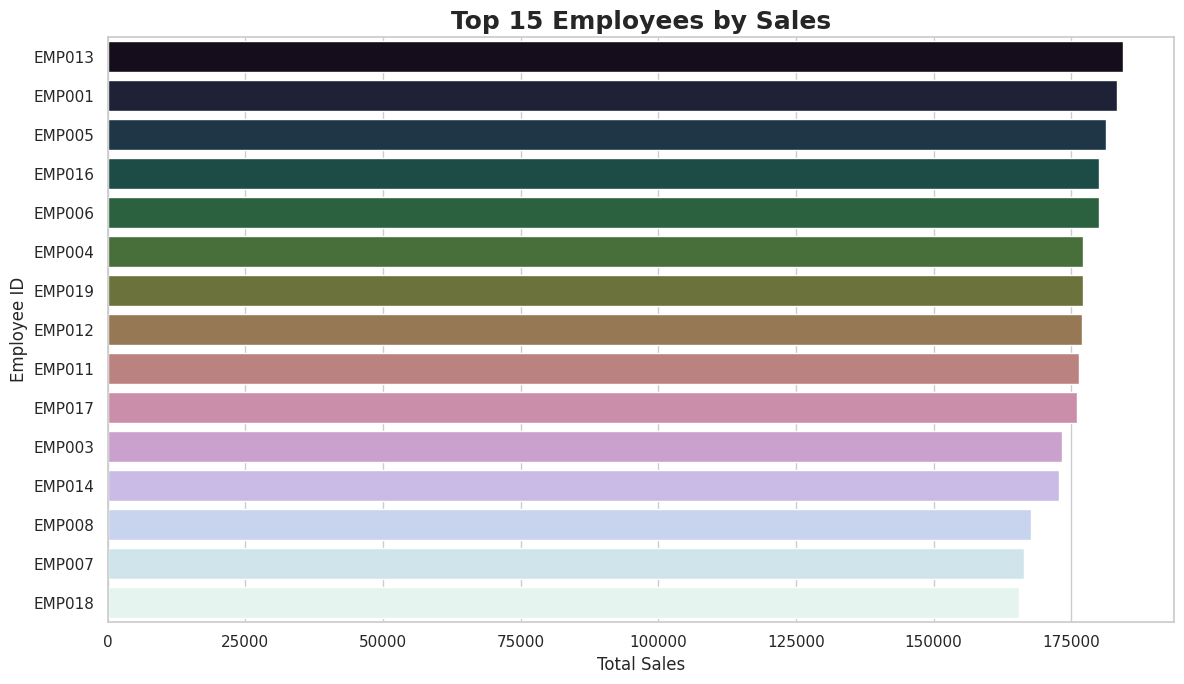

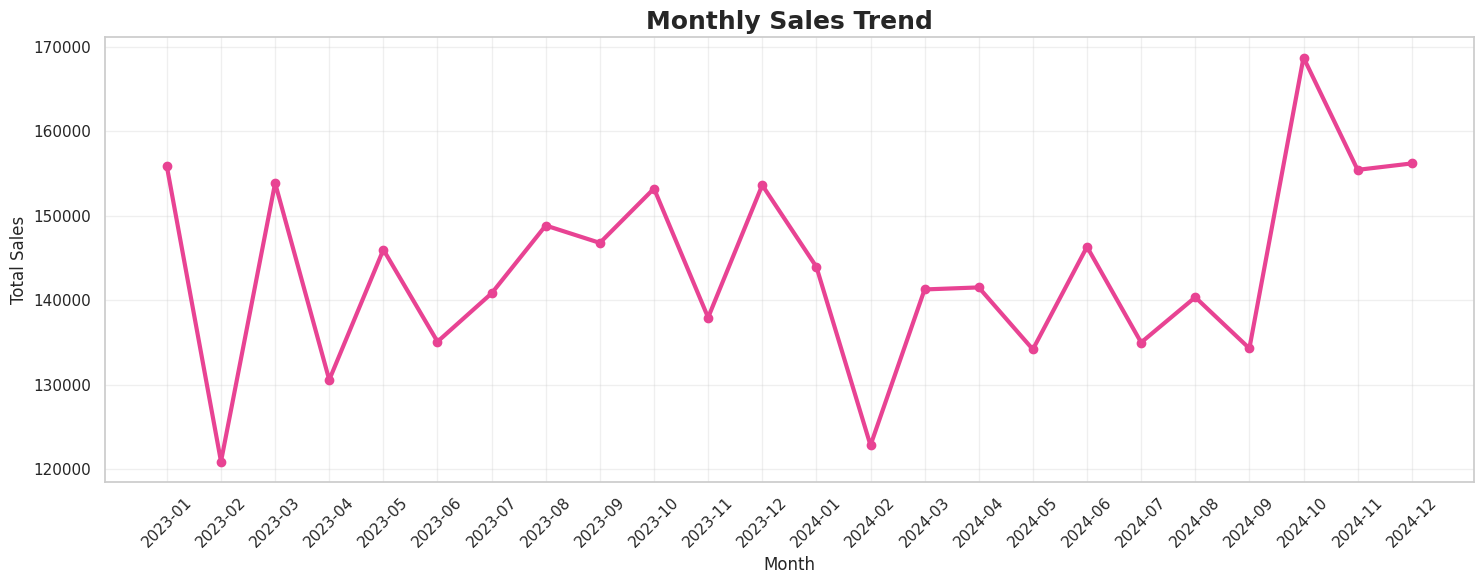

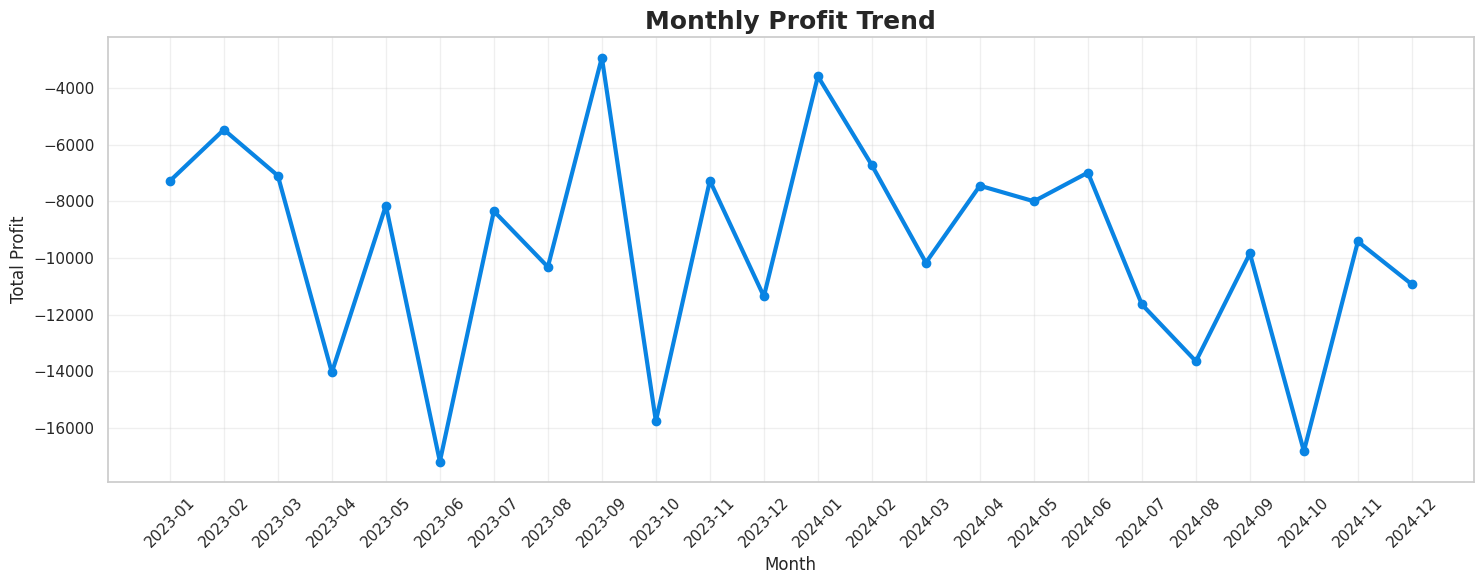

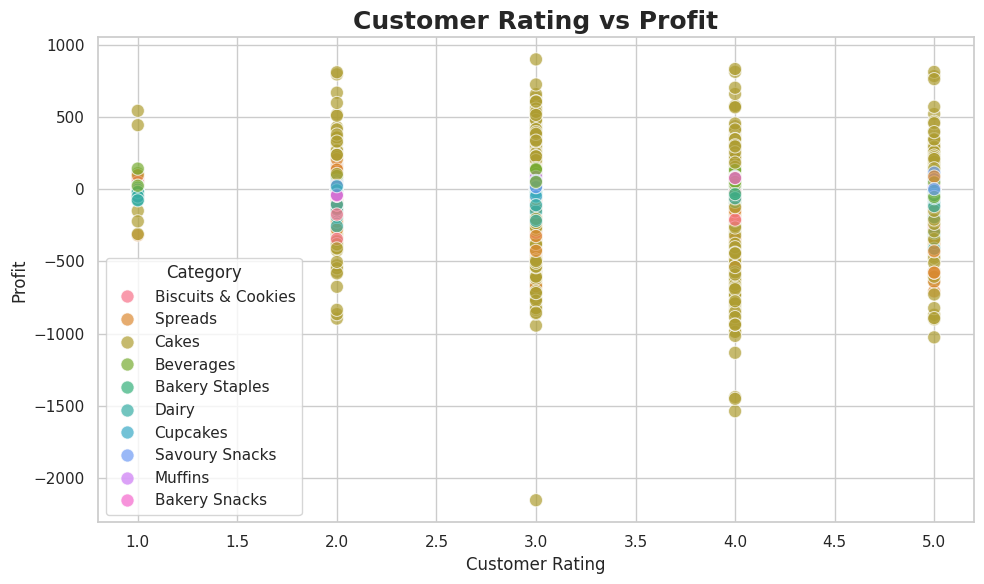

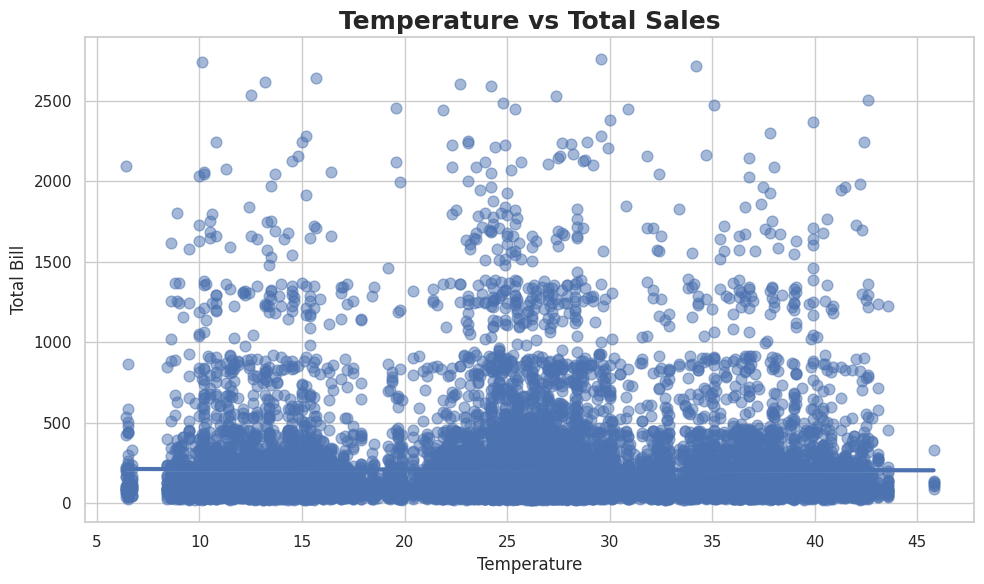

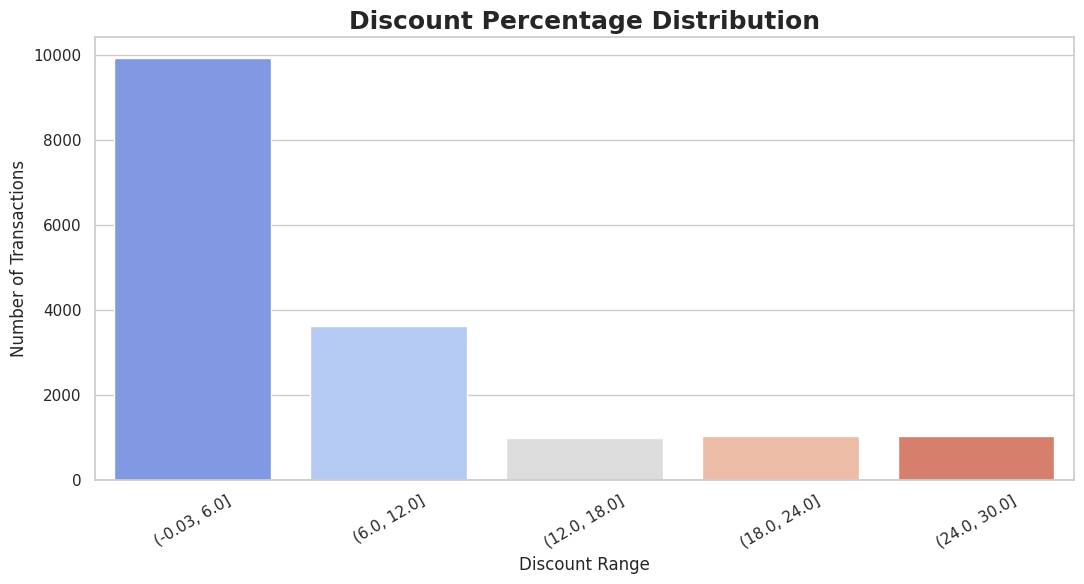

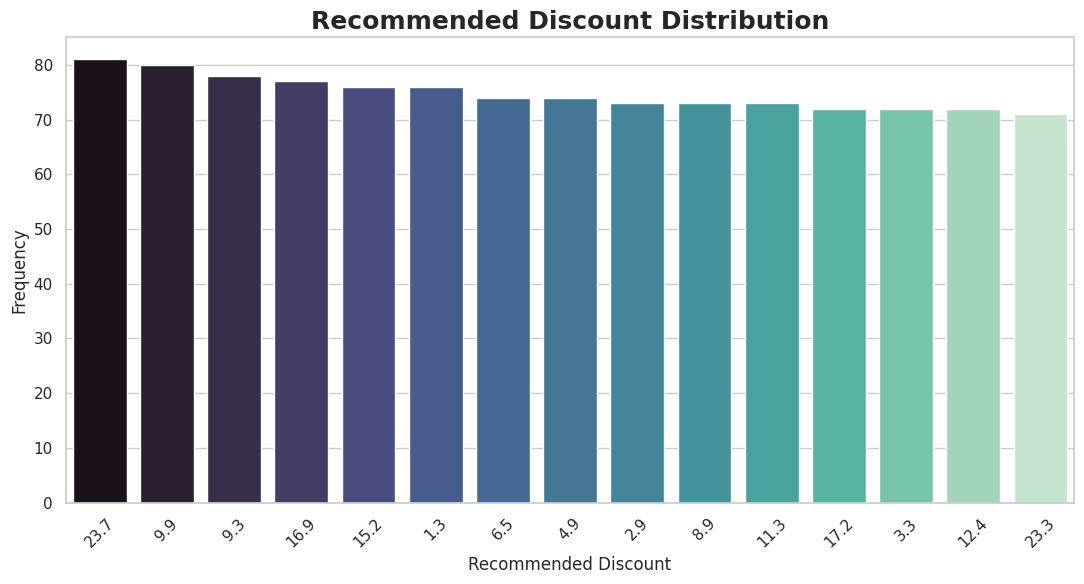


FINAL DATASET SUMMARY
Rows              : 16,569
Columns           : 41
Missing Values    : 29,169
Duplicate Rows    : 0
Total Revenue     : 3,444,112.95
Total Profit      : -230,339.25
Total Waste Cost  : 1,388,812.80
Total Units Sold  : 81,184
Total Production  : 126,710

Visualization completed successfully!


In [12]:
# Convert date columns
date_columns = [
    "Date",
    "Manufacturing_Date",
    "Expiry_Date"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert numeric columns
numeric_columns = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Discount_Amount",
    "Selling_Price",
    "Total_Bill",
    "Temperature",
    "Shelf_Life_Days",
    "Stock_Available",
    "Units_Produced",
    "Units_Sold",
    "Unsold_Units",
    "Promotion_Score",
    "Customer_Rating",
    "Profit",
    "Waste_Cost"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# 4. COLOR PALETTE
# ============================================================

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#96CEB4",
    "#FFEAA7",
    "#DDA0DD",
    "#FF9F43",
    "#5F27CD",
    "#00D2D3",
    "#EE5253",
    "#10AC84",
    "#54A0FF"
]

sns.set_theme(style="whitegrid")


# ============================================================
# 5. TARGET / NUMERIC DISTRIBUTIONS
# ============================================================

numeric_plot_cols = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Discount_Amount",
    "Selling_Price",
    "Total_Bill",
    "Temperature",
    "Shelf_Life_Days",
    "Stock_Available",
    "Units_Produced",
    "Units_Sold",
    "Unsold_Units",
    "Promotion_Score",
    "Customer_Rating",
    "Profit",
    "Waste_Cost"
]

numeric_plot_cols = [
    col for col in numeric_plot_cols if col in df.columns
]

# Histogram for every numerical column
for i, col in enumerate(numeric_plot_cols):

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color=colors[i % len(colors)]
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. BOXPLOTS - OUTLIER ANALYSIS
# ============================================================

for i, col in enumerate(numeric_plot_cols):

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[col],
        color=colors[i % len(colors)]
    )

    plt.title(
        f"Boxplot - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. CORRELATION HEATMAP
# ============================================================

corr = df[numeric_plot_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=0.5,
    center=0
)

plt.title(
    "Correlation Heatmap - Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. TOP PRODUCTS BY SALES
# ============================================================

if "Product" in df.columns and "Total_Bill" in df.columns:

    product_sales = (
        df.groupby("Product")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=product_sales.values,
        y=product_sales.index,
        hue=product_sales.index,
        palette="husl",
        legend=False
    )

    plt.title(
        "Top 15 Products by Total Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Sales")
    plt.ylabel("Product")

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. SALES BY CATEGORY
# ============================================================

if "Category" in df.columns and "Total_Bill" in df.columns:

    category_sales = (
        df.groupby("Category")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=category_sales.index,
        y=category_sales.values,
        hue=category_sales.index,
        palette="Set2",
        legend=False
    )

    plt.title(
        "Sales by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. PAYMENT METHOD DISTRIBUTION
# ============================================================

if "Payment_Method" in df.columns:

    payment_counts = df["Payment_Method"].value_counts()

    plt.figure(figsize=(8, 8))

    plt.pie(
        payment_counts.values,
        labels=payment_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors[:len(payment_counts)],
        wedgeprops={"edgecolor": "white"}
    )

    plt.title(
        "Payment Method Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. CUSTOMER GENDER DISTRIBUTION
# ============================================================

if "Customer_Gender" in df.columns:

    gender_counts = df["Customer_Gender"].value_counts()

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=gender_counts.index,
        y=gender_counts.values,
        hue=gender_counts.index,
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Customer Gender Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. CUSTOMER AGE DISTRIBUTION
# ============================================================

if "Customer_Age" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df["Customer_Age"].dropna(),
        bins=20,
        kde=True,
        color="#9B59B6"
    )

    plt.title(
        "Customer Age Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Age")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. CUSTOMER SEGMENT
# ============================================================

if "Customer_Segment" in df.columns:

    segment_counts = df["Customer_Segment"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=segment_counts.index,
        y=segment_counts.values,
        hue=segment_counts.index,
        palette="viridis",
        legend=False
    )

    plt.title(
        "Customer Segment Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. LOYALTY MEMBER ANALYSIS
# ============================================================

if "Loyalty_Member" in df.columns:

    loyalty_counts = df["Loyalty_Member"].value_counts()

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=loyalty_counts.index,
        y=loyalty_counts.values,
        hue=loyalty_counts.index,
        palette="Set1",
        legend=False
    )

    plt.title(
        "Loyalty Member Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Loyalty Member")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 15. SALES BY WEATHER
# ============================================================

if "Weather" in df.columns and "Total_Bill" in df.columns:

    weather_sales = (
        df.groupby("Weather")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=weather_sales.index,
        y=weather_sales.values,
        hue=weather_sales.index,
        palette="cool",
        legend=False
    )

    plt.title(
        "Sales by Weather",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Weather")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. SALES BY SEASON
# ============================================================

if "Season" in df.columns and "Total_Bill" in df.columns:

    season_sales = (
        df.groupby("Season")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=season_sales.index,
        y=season_sales.values,
        hue=season_sales.index,
        palette="magma",
        legend=False
    )

    plt.title(
        "Sales by Season",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Season")
    plt.ylabel("Total Sales")

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. SALES BY DAY OF WEEK
# ============================================================

if "Day_of_Week" in df.columns and "Total_Bill" in df.columns:

    day_sales = (
        df.groupby("Day_of_Week")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=day_sales.index,
        y=day_sales.values,
        hue=day_sales.index,
        palette="tab10",
        legend=False
    )

    plt.title(
        "Sales by Day of Week",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Day")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. WEEKEND VS WEEKDAY SALES
# ============================================================

if "Weekend" in df.columns and "Total_Bill" in df.columns:

    weekend_sales = (
        df.groupby("Weekend")["Total_Bill"]
        .sum()
    )

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=weekend_sales.index,
        y=weekend_sales.values,
        hue=weekend_sales.index,
        palette="Set3",
        legend=False
    )

    plt.title(
        "Weekend vs Weekday Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Weekend")
    plt.ylabel("Total Sales")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. FESTIVAL SALES
# ============================================================

if "Festival" in df.columns and "Total_Bill" in df.columns:

    festival_sales = (
        df.groupby("Festival")["Total_Bill"]
        .sum()
    )

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=festival_sales.index,
        y=festival_sales.values,
        hue=festival_sales.index,
        palette="flare",
        legend=False
    )

    plt.title(
        "Festival vs Non-Festival Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Festival")
    plt.ylabel("Total Sales")

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. PROMOTION TYPE ANALYSIS
# ============================================================

if "Promotion_Type" in df.columns and "Total_Bill" in df.columns:

    promotion_sales = (
        df.groupby("Promotion_Type")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=promotion_sales.index,
        y=promotion_sales.values,
        hue=promotion_sales.index,
        palette="rocket",
        legend=False
    )

    plt.title(
        "Sales by Promotion Type",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Promotion Type")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=35)

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. PROMOTION SCORE VS SALES
# ============================================================

if "Promotion_Score" in df.columns and "Total_Bill" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Promotion_Score",
        y="Total_Bill",
        hue="Customer_Segment" if "Customer_Segment" in df.columns else None,
        palette="husl",
        s=80,
        alpha=0.7
    )

    plt.title(
        "Promotion Score vs Total Bill",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Promotion Score")
    plt.ylabel("Total Bill")

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. DISCOUNT VS PROFIT
# ============================================================

if "Discount_Percentage" in df.columns and "Profit" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Discount_Percentage",
        y="Profit",
        hue="Customer_Segment" if "Customer_Segment" in df.columns else None,
        palette="Set1",
        s=80,
        alpha=0.7
    )

    plt.title(
        "Discount Percentage vs Profit",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Discount Percentage")
    plt.ylabel("Profit")

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. QUANTITY VS TOTAL BILL
# ============================================================

if "Quantity" in df.columns and "Total_Bill" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Quantity",
        y="Total_Bill",
        hue="Category" if "Category" in df.columns else None,
        palette="tab10",
        s=80,
        alpha=0.7
    )

    plt.title(
        "Quantity vs Total Bill",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Quantity")
    plt.ylabel("Total Bill")

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. UNITS PRODUCED VS UNITS SOLD
# ============================================================

if "Units_Produced" in df.columns and "Units_Sold" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Units_Produced",
        y="Units_Sold",
        hue="Expiry_Risk" if "Expiry_Risk" in df.columns else None,
        palette="coolwarm",
        s=80,
        alpha=0.7
    )

    plt.title(
        "Units Produced vs Units Sold",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Units Produced")
    plt.ylabel("Units Sold")

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. UNSOLD UNITS BY PRODUCT
# ============================================================

if "Product" in df.columns and "Unsold_Units" in df.columns:

    unsold = (
        df.groupby("Product")["Unsold_Units"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=unsold.values,
        y=unsold.index,
        hue=unsold.index,
        palette="rocket",
        legend=False
    )

    plt.title(
        "Top 15 Products by Unsold Units",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Unsold Units")
    plt.ylabel("Product")

    plt.tight_layout()
    plt.show()


# ============================================================
# 26. EXPIRY RISK DISTRIBUTION
# ============================================================

if "Expiry_Risk" in df.columns:

    expiry_counts = df["Expiry_Risk"].value_counts()

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=expiry_counts.index,
        y=expiry_counts.values,
        hue=expiry_counts.index,
        palette="RdYlGn_r",
        legend=False
    )

    plt.title(
        "Expiry Risk Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Expiry Risk")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. PROFIT BY CATEGORY
# ============================================================

if "Category" in df.columns and "Profit" in df.columns:

    category_profit = (
        df.groupby("Category")["Profit"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=category_profit.index,
        y=category_profit.values,
        hue=category_profit.index,
        palette="viridis",
        legend=False
    )

    plt.title(
        "Profit by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Total Profit")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 28. WASTE COST BY CATEGORY
# ============================================================

if "Category" in df.columns and "Waste_Cost" in df.columns:

    waste_category = (
        df.groupby("Category")["Waste_Cost"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=waste_category.index,
        y=waste_category.values,
        hue=waste_category.index,
        palette="YlOrRd",
        legend=False
    )

    plt.title(
        "Waste Cost by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Waste Cost")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. CUSTOMER RATING BY CATEGORY
# ============================================================

if "Category" in df.columns and "Customer_Rating" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df,
        x="Category",
        y="Customer_Rating",
        hue="Category",
        palette="Set2",
        legend=False
    )

    plt.title(
        "Customer Rating by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Customer Rating")

    plt.xticks(rotation=35)

    plt.tight_layout()
    plt.show()


# ============================================================
# 30. PROFIT DISTRIBUTION
# ============================================================

if "Profit" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df["Profit"].dropna(),
        bins=30,
        kde=True,
        color="#00B894"
    )

    plt.axvline(
        df["Profit"].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {df['Profit'].mean():.2f}"
    )

    plt.axvline(
        df["Profit"].median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {df['Profit'].median():.2f}"
    )

    plt.title(
        "Profit Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Profit")
    plt.ylabel("Frequency")

    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. TOTAL BILL DISTRIBUTION
# ============================================================

if "Total_Bill" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df["Total_Bill"].dropna(),
        bins=30,
        kde=True,
        color="#6C5CE7"
    )

    plt.title(
        "Total Bill Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Bill")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. TOP CUSTOMERS BY SPENDING
# ============================================================

if "Customer_ID" in df.columns and "Total_Bill" in df.columns:

    customer_sales = (
        df.groupby("Customer_ID")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=customer_sales.values,
        y=customer_sales.index,
        hue=customer_sales.index,
        palette="Spectral",
        legend=False
    )

    plt.title(
        "Top 15 Customers by Total Spending",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Spending")
    plt.ylabel("Customer ID")

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. STORE PERFORMANCE
# ============================================================

if "Store_ID" in df.columns and "Total_Bill" in df.columns:

    store_sales = (
        df.groupby("Store_ID")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=store_sales.values,
        y=store_sales.index,
        hue=store_sales.index,
        palette="plasma",
        legend=False
    )

    plt.title(
        "Top 15 Stores by Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Sales")
    plt.ylabel("Store ID")

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. EMPLOYEE PERFORMANCE
# ============================================================

if "Employee_ID" in df.columns and "Total_Bill" in df.columns:

    employee_sales = (
        df.groupby("Employee_ID")["Total_Bill"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=employee_sales.values,
        y=employee_sales.index,
        hue=employee_sales.index,
        palette="cubehelix",
        legend=False
    )

    plt.title(
        "Top 15 Employees by Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Sales")
    plt.ylabel("Employee ID")

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. MONTHLY SALES TREND
# ============================================================

if "Date" in df.columns and "Total_Bill" in df.columns:

    temp = df.dropna(subset=["Date"]).copy()

    temp["Month"] = temp["Date"].dt.to_period("M").astype(str)

    monthly_sales = (
        temp.groupby("Month")["Total_Bill"]
        .sum()
    )

    plt.figure(figsize=(15, 6))

    plt.plot(
        monthly_sales.index,
        monthly_sales.values,
        marker="o",
        linewidth=3,
        color="#E84393"
    )

    plt.title(
        "Monthly Sales Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 36. MONTHLY PROFIT TREND
# ============================================================

if "Date" in df.columns and "Profit" in df.columns:

    temp = df.dropna(subset=["Date"]).copy()

    temp["Month"] = temp["Date"].dt.to_period("M").astype(str)

    monthly_profit = (
        temp.groupby("Month")["Profit"]
        .sum()
    )

    plt.figure(figsize=(15, 6))

    plt.plot(
        monthly_profit.index,
        monthly_profit.values,
        marker="o",
        linewidth=3,
        color="#0984E3"
    )

    plt.title(
        "Monthly Profit Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Total Profit")

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 37. CUSTOMER RATING VS PROFIT
# ============================================================

if "Customer_Rating" in df.columns and "Profit" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Customer_Rating",
        y="Profit",
        hue="Category" if "Category" in df.columns else None,
        palette="husl",
        s=90,
        alpha=0.7
    )

    plt.title(
        "Customer Rating vs Profit",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Rating")
    plt.ylabel("Profit")

    plt.tight_layout()
    plt.show()


# ============================================================
# 38. TEMPERATURE VS SALES
# ============================================================

if "Temperature" in df.columns and "Total_Bill" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.regplot(
        data=df,
        x="Temperature",
        y="Total_Bill",
        scatter_kws={"alpha": 0.5, "s": 60},
        line_kws={"linewidth": 3}
    )

    plt.title(
        "Temperature vs Total Sales",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Temperature")
    plt.ylabel("Total Bill")

    plt.tight_layout()
    plt.show()


# ============================================================
# 39. DISCOUNT ANALYSIS
# ============================================================

if "Discount_Percentage" in df.columns:

    discount_bins = pd.cut(
        df["Discount_Percentage"],
        bins=5
    )

    discount_count = discount_bins.value_counts().sort_index()

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=discount_count.index.astype(str),
        y=discount_count.values,
        hue=discount_count.index.astype(str),
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Discount Percentage Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Discount Range")
    plt.ylabel("Number of Transactions")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 40. RECOMMENDED DISCOUNT DISTRIBUTION
# ============================================================

if "Recommended_Discount" in df.columns:

    recommendation_counts = (
        df["Recommended_Discount"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=recommendation_counts.index.astype(str),
        y=recommendation_counts.values,
        hue=recommendation_counts.index.astype(str),
        palette="mako",
        legend=False
    )

    plt.title(
        "Recommended Discount Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Recommended Discount")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 41. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "="*70)
print("FINAL DATASET SUMMARY")
print("="*70)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]:,}")
print(f"Missing Values    : {df.isnull().sum().sum():,}")
print(f"Duplicate Rows    : {df.duplicated().sum():,}")

if "Total_Bill" in df.columns:
    print(f"Total Revenue     : {df['Total_Bill'].sum():,.2f}")

if "Profit" in df.columns:
    print(f"Total Profit      : {df['Profit'].sum():,.2f}")

if "Waste_Cost" in df.columns:
    print(f"Total Waste Cost  : {df['Waste_Cost'].sum():,.2f}")

if "Units_Sold" in df.columns:
    print(f"Total Units Sold  : {df['Units_Sold'].sum():,.0f}")

if "Units_Produced" in df.columns:
    print(f"Total Production  : {df['Units_Produced'].sum():,.0f}")

print("\nVisualization completed successfully!")

## Feature engineering

DATASET INFORMATION
Shape: (16569, 41)

Columns:
['Transaction_ID', 'Date', 'Time', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Discount_Amount', 'Selling_Price', 'Total_Bill', 'Payment_Method', 'Weather', 'Temperature', 'Season', 'Day_of_Week', 'Weekend', 'Festival', 'Store_ID', 'Employee_ID', 'Shelf_Life_Days', 'Manufacturing_Date', 'Expiry_Date', 'Stock_Available', 'Units_Produced', 'Units_Sold', 'Unsold_Units', 'Expiry_Risk', 'Promotion_Applied', 'Promotion_Type', 'Promotion_Score', 'Customer_Rating', 'Customer_Segment', 'Loyalty_Member', 'Profit', 'Waste_Cost', 'Recommended_Product', 'Recommended_Discount']

Missing Values:
Festival                15960
Promotion_Type          13209
Time                        0
Date                        0
Customer_Age                0
Customer_Gender             0
Product                     0
Customer_ID                 0
Transaction_ID              0
Quantity      

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Extra Trees,1.0000,1.0000,1.0000,1.0000,1.0000
1,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,LightGBM,0.9997,0.9997,0.9997,0.9997,1.0000
3,Random Forest,0.9997,0.9997,0.9997,0.9997,1.0000
4,CatBoost,0.9994,0.9994,0.9994,0.9994,1.0000
5,Decision Tree,0.9991,0.9991,0.9991,0.9991,0.9990
6,Gradient Boosting,0.9988,0.9988,0.9988,0.9988,1.0000
7,Logistic Regression,0.9958,0.9958,0.9958,0.9958,0.9998
8,KNN,0.8527,0.8634,0.8527,0.8491,0.9476


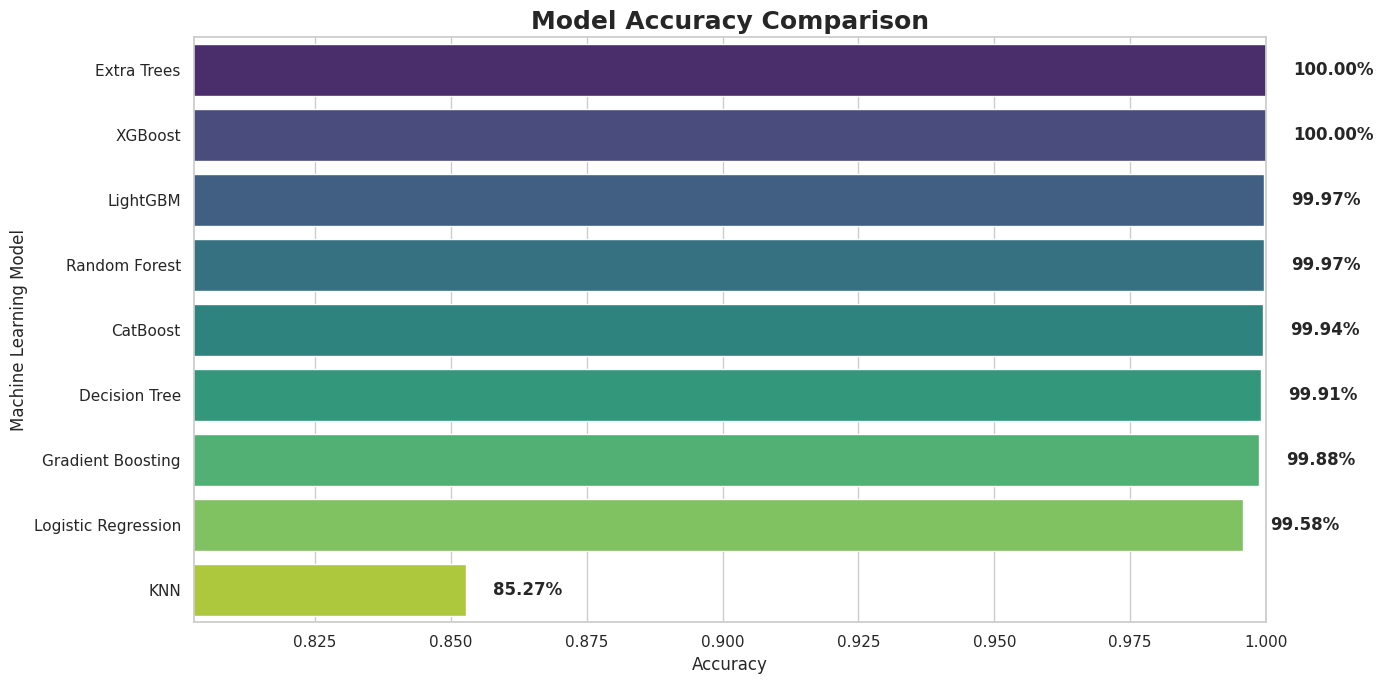

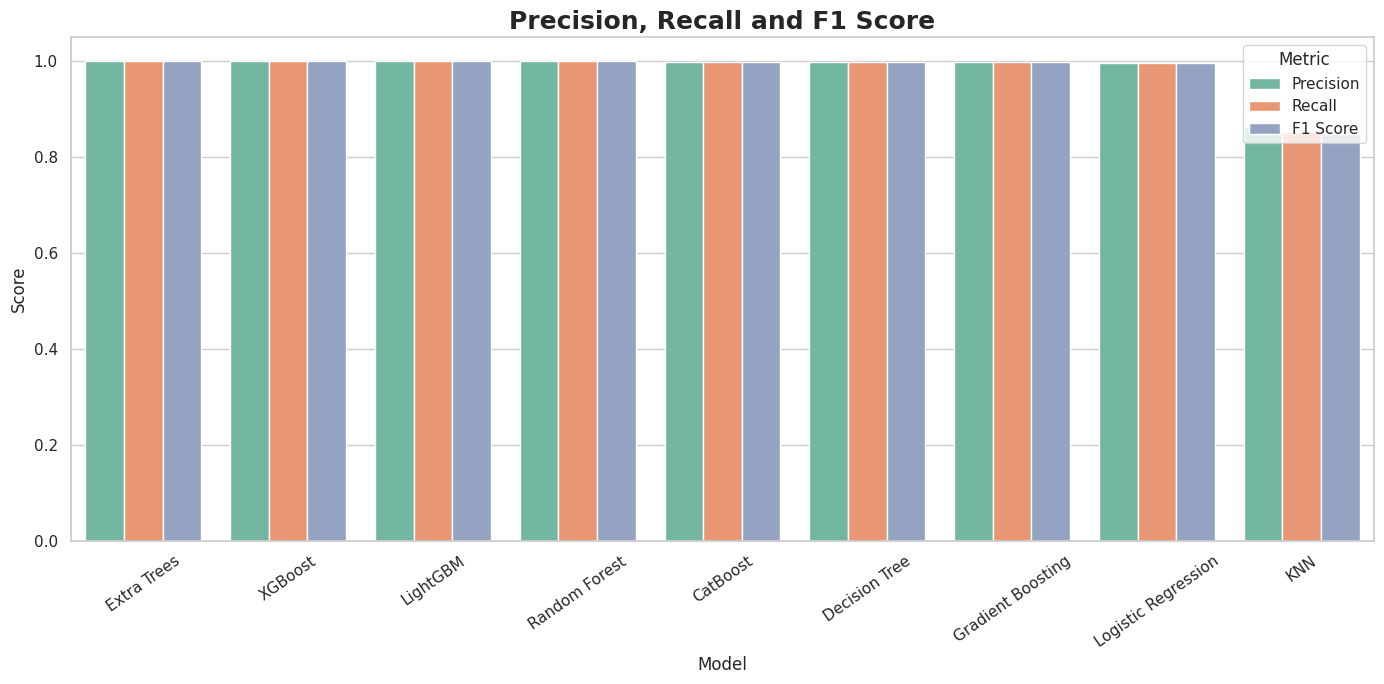

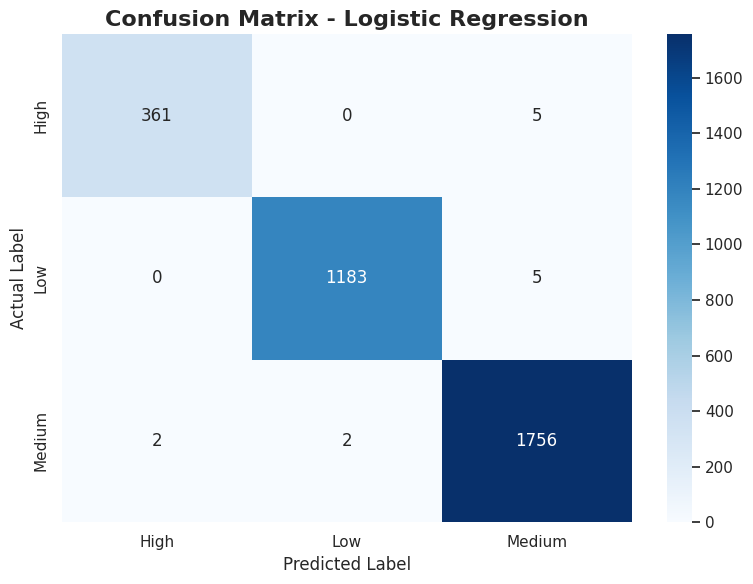

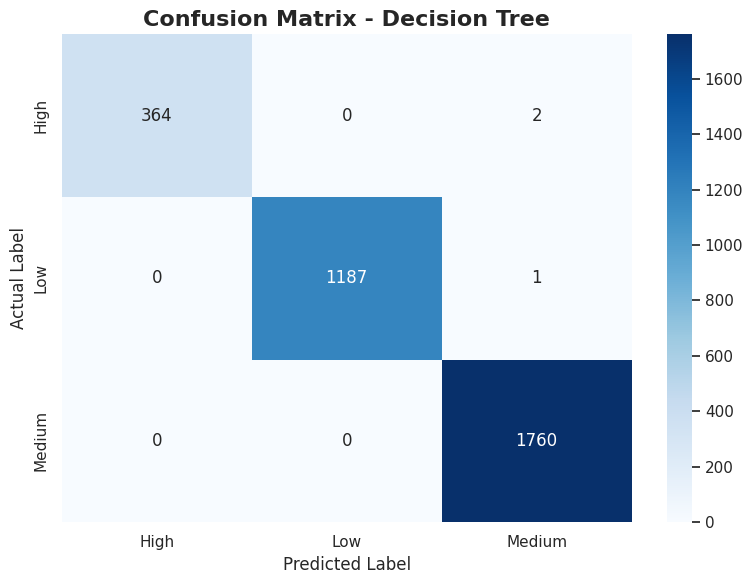

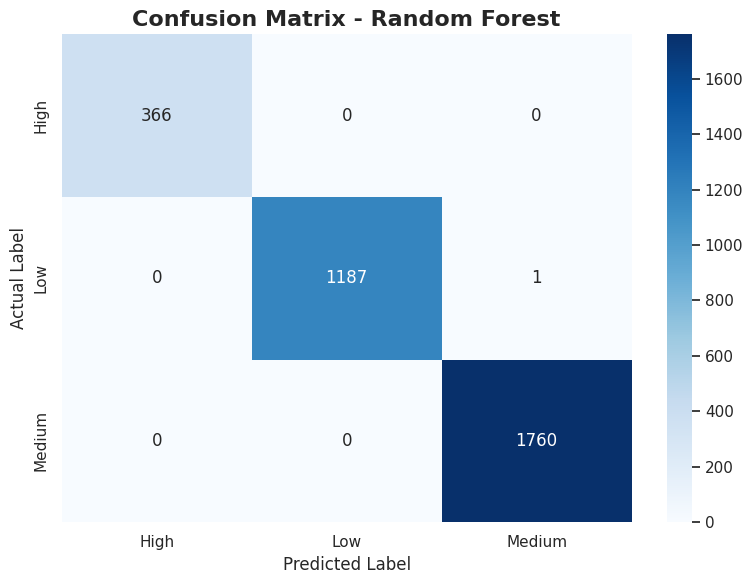

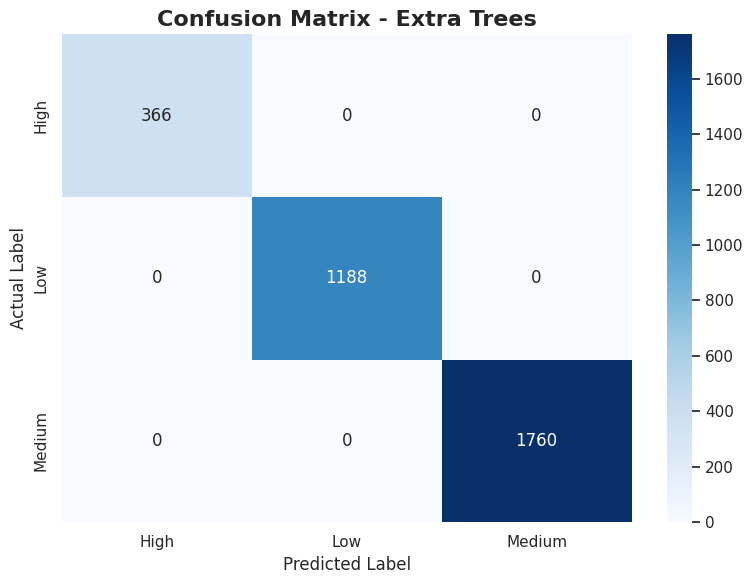

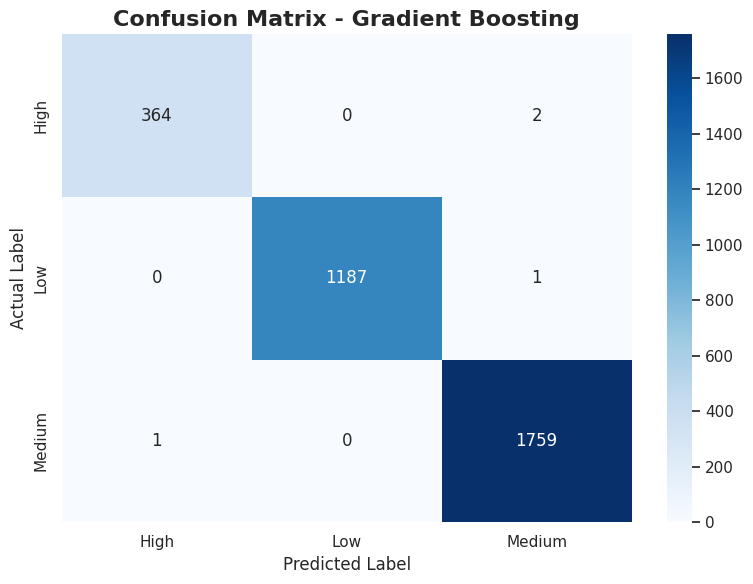

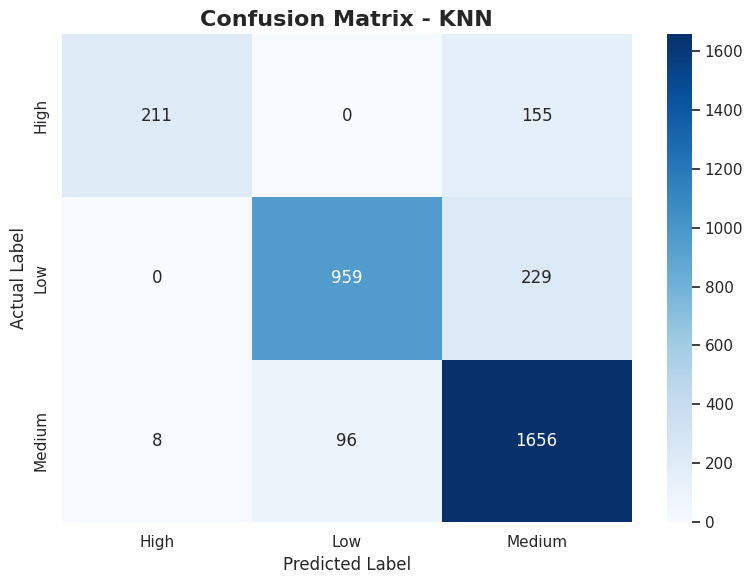

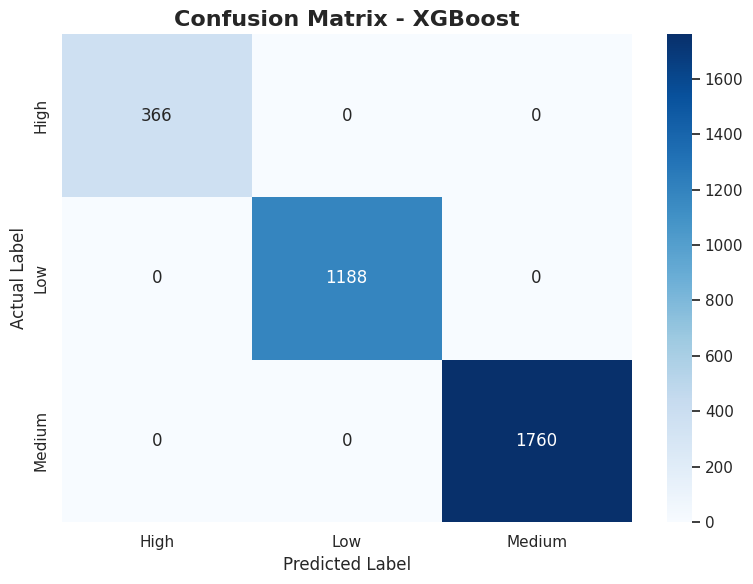

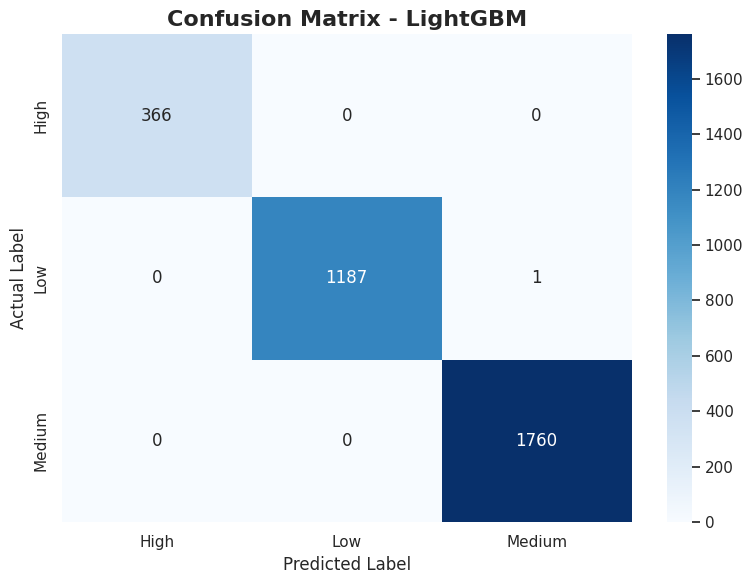

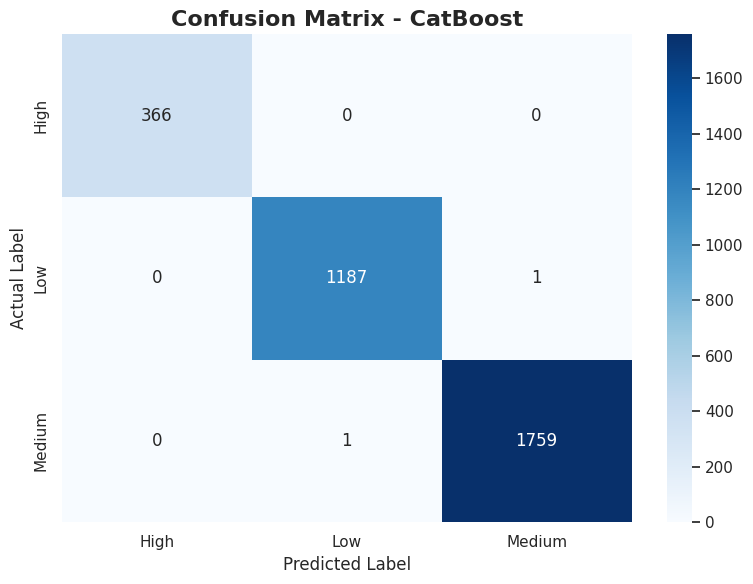



CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

        High       0.99      0.99      0.99       366
         Low       1.00      1.00      1.00      1188
      Medium       0.99      1.00      1.00      1760

    accuracy                           1.00      3314
   macro avg       1.00      0.99      0.99      3314
weighted avg       1.00      1.00      1.00      3314



CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

        High       1.00      0.99      1.00       366
         Low       1.00      1.00      1.00      1188
      Medium       1.00      1.00      1.00      1760

    accuracy                           1.00      3314
   macro avg       1.00      1.00      1.00      3314
weighted avg       1.00      1.00      1.00      3314



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       366
   

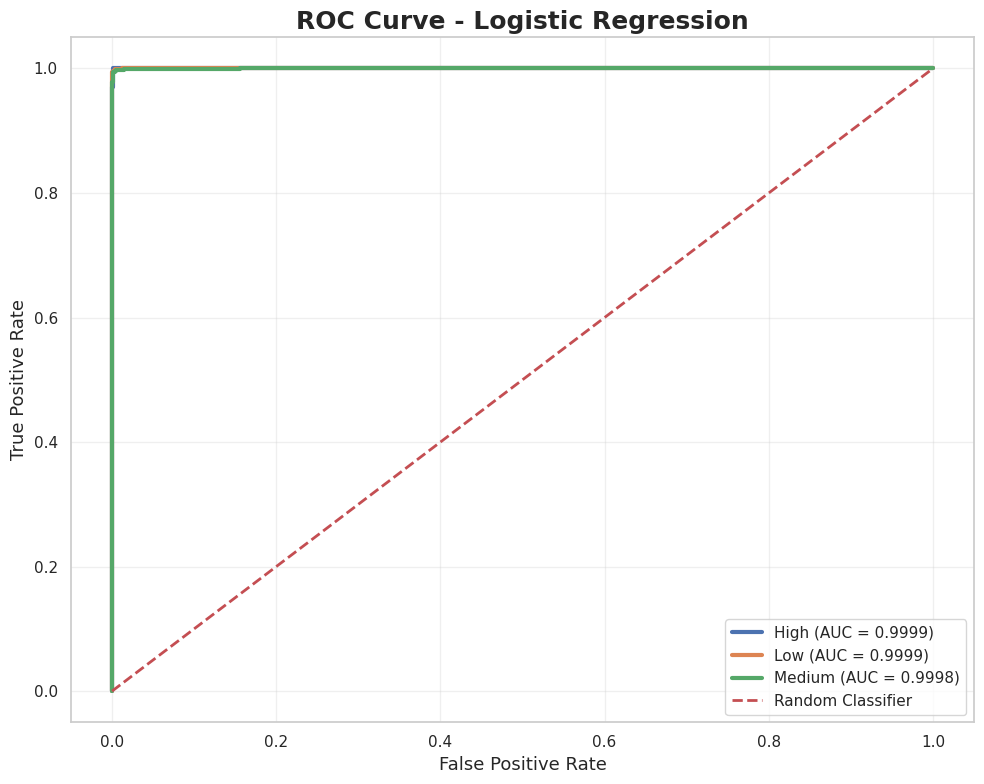

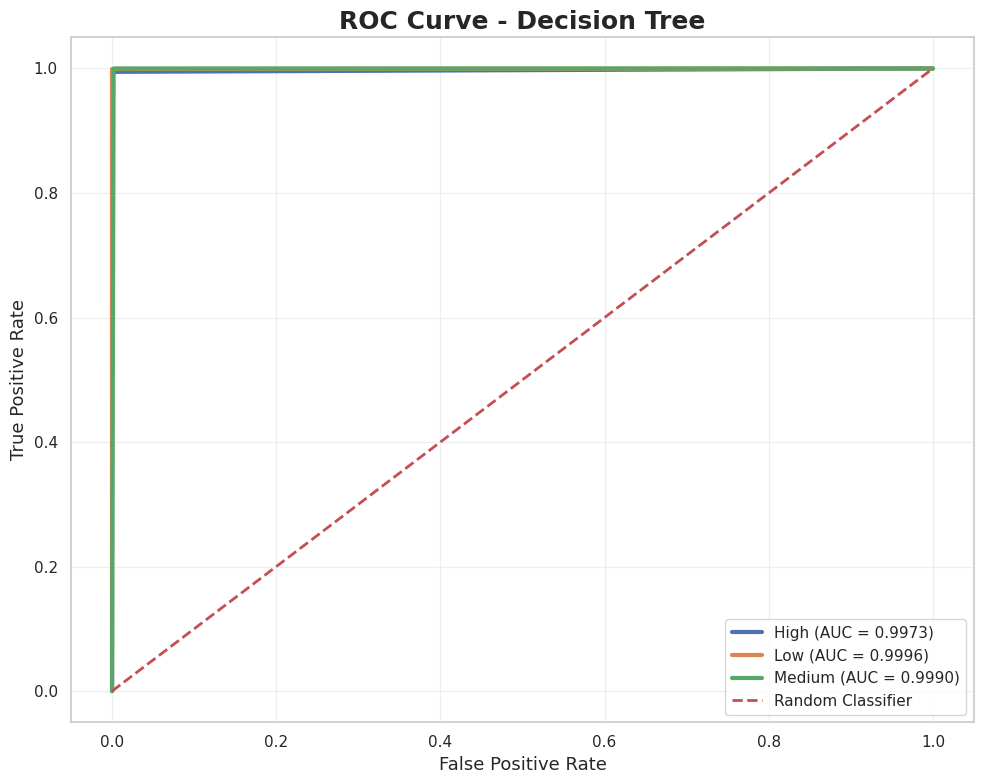

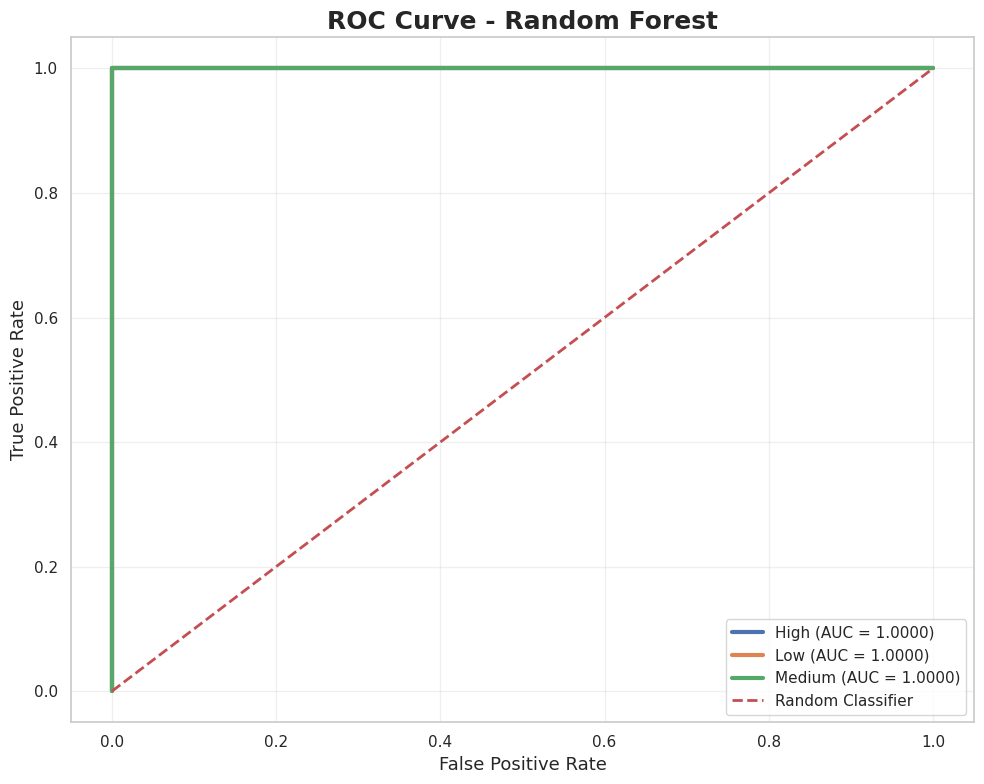

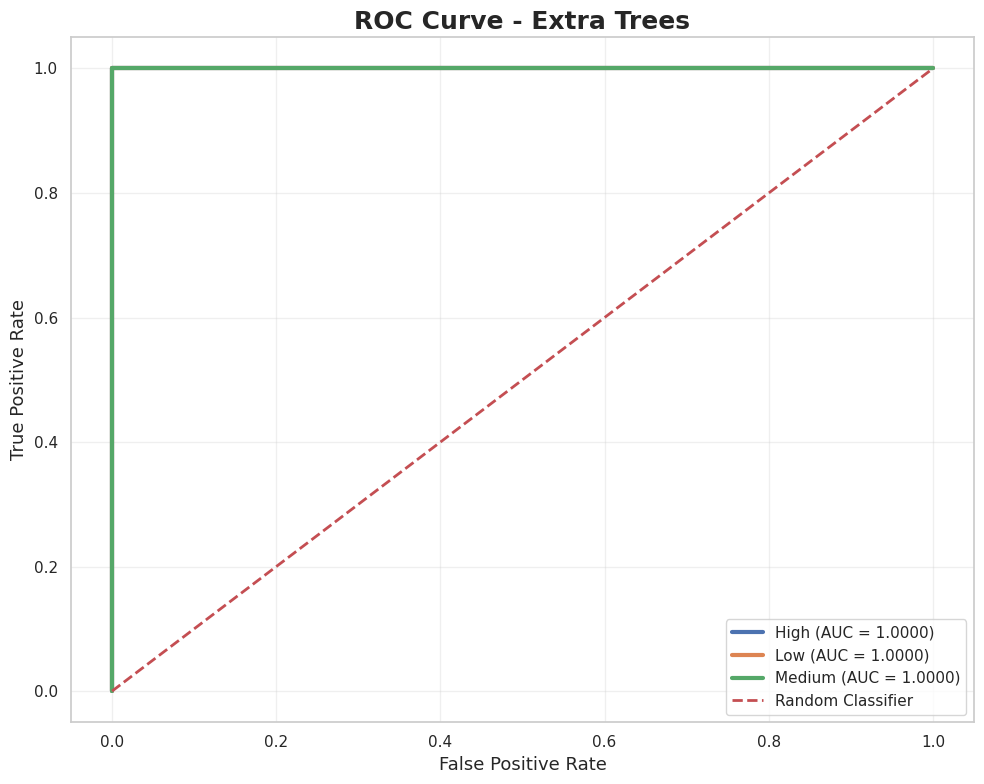

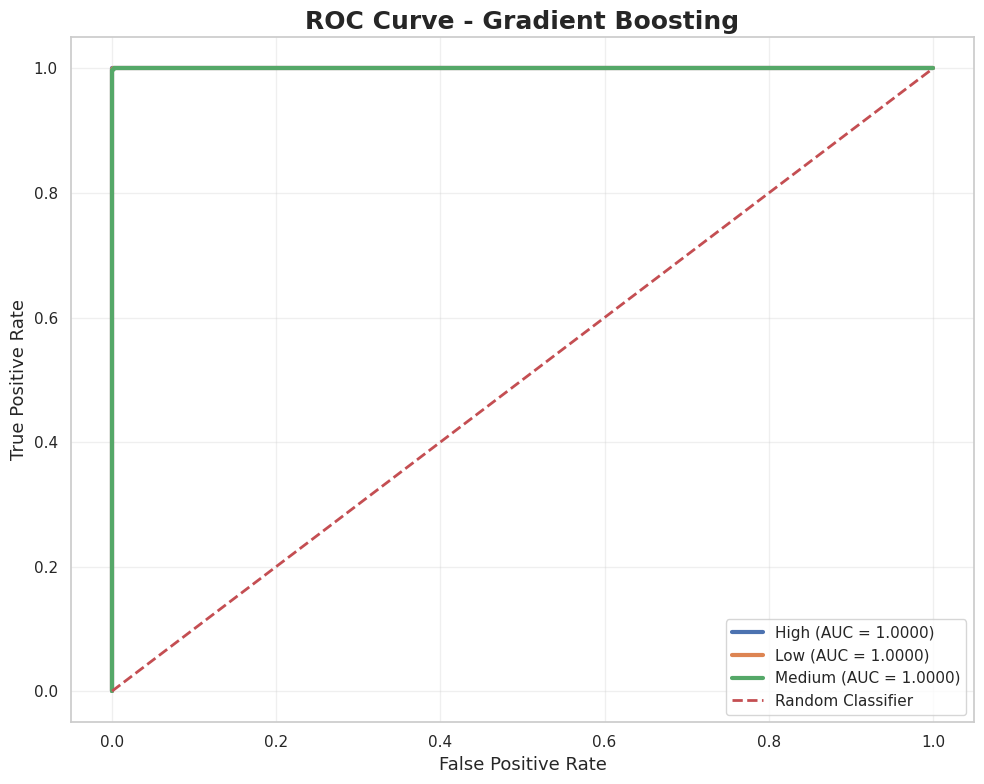

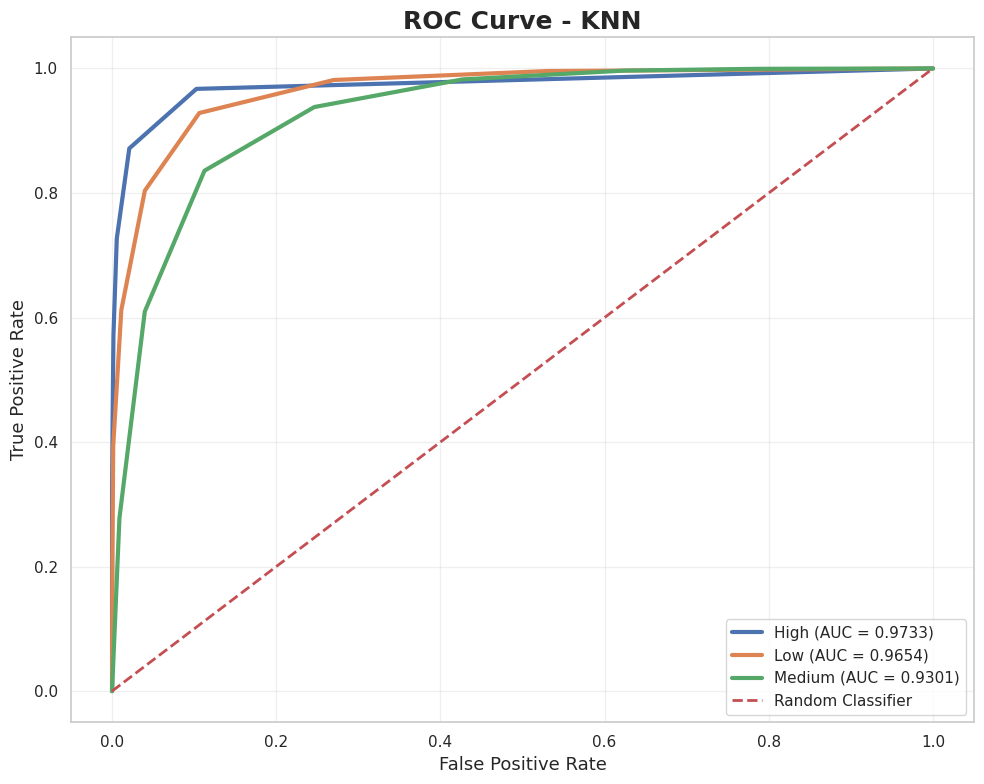

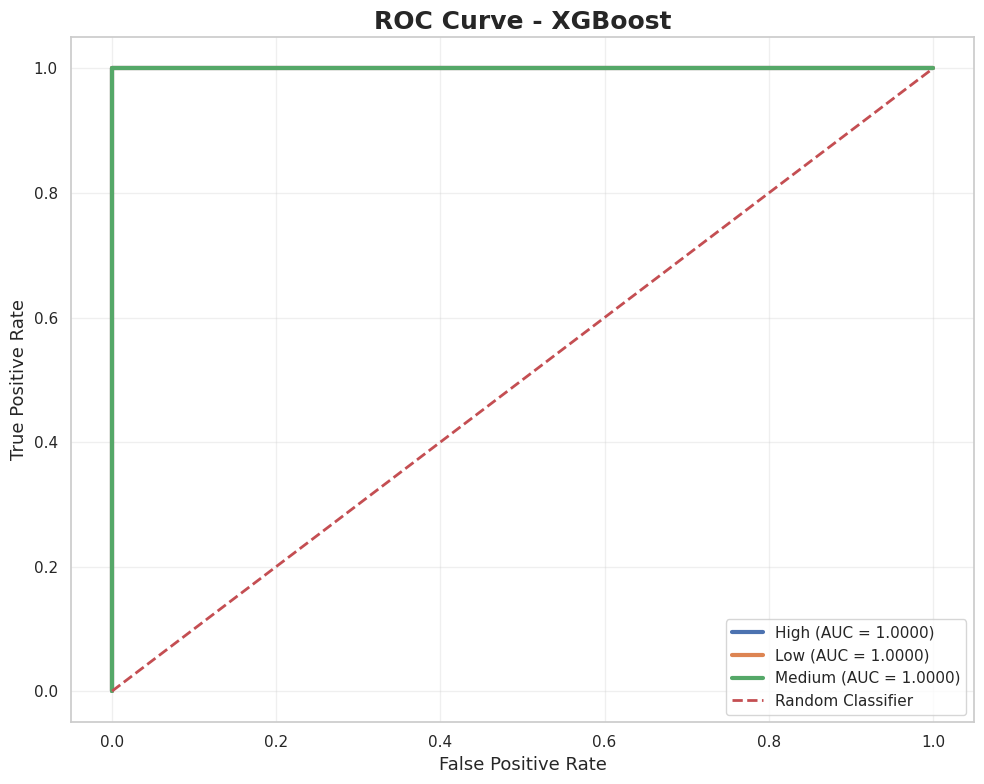

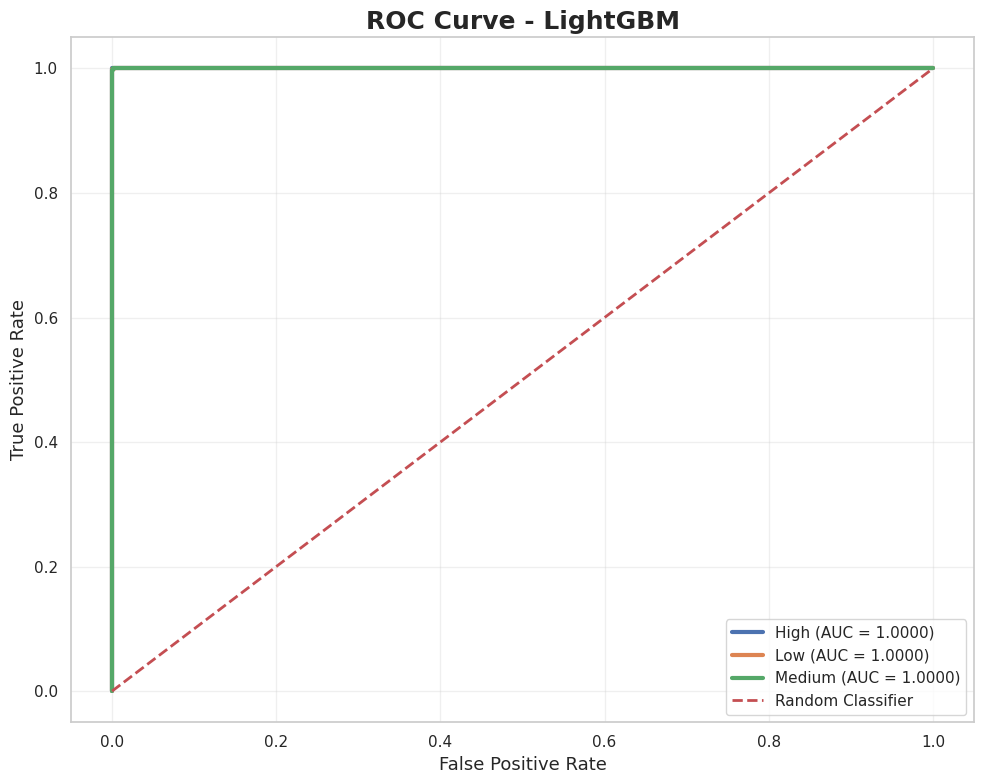

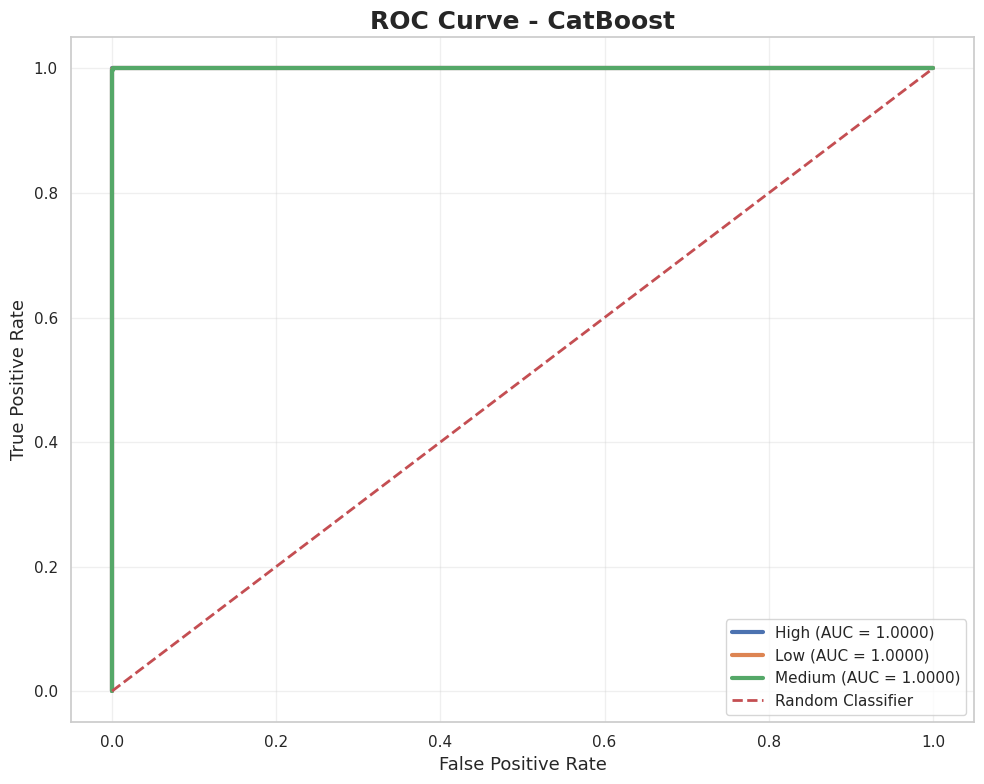


RANDOM FOREST - FEATURE IMPORTANCE
Number of feature names: 42
Number of importance values: 42


,Feature,Importance
0,Feature_17,0.377529
1,Feature_12,0.206006
2,Feature_9,0.188282
3,Feature_8,0.073279
4,Feature_10,0.037447
5,Feature_30,0.023757
6,Feature_16,0.014932
7,Feature_29,0.011879
8,Feature_2,0.010361
9,Feature_11,0.010331


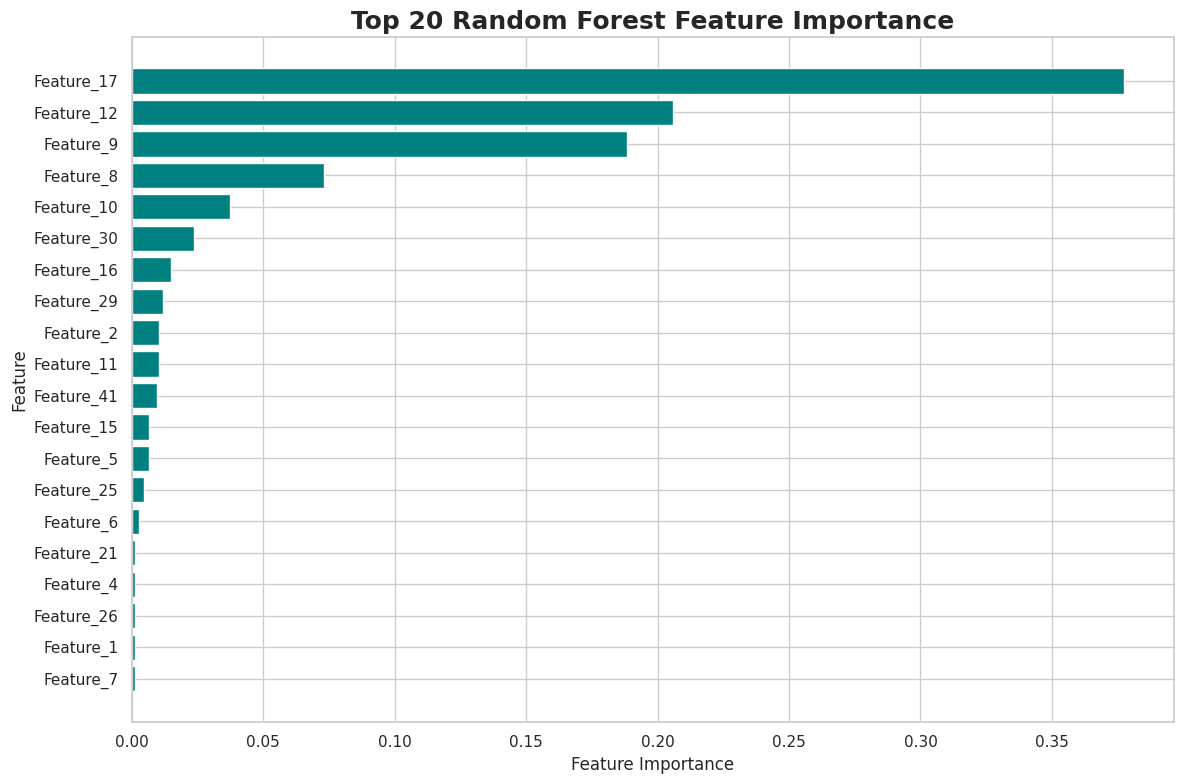


FEATURE IMPORTANCE - ALL TREE MODELS

Top Features - Decision Tree


,Feature,Importance
0,Feature_17,0.994192
1,Feature_12,0.003381
2,Feature_8,0.001440
3,Feature_13,0.000301
4,Feature_15,0.000261
5,Feature_19,0.000250
6,Feature_20,0.000174
7,Feature_2,0.000000
8,Feature_1,0.000000
9,Feature_0,0.000000


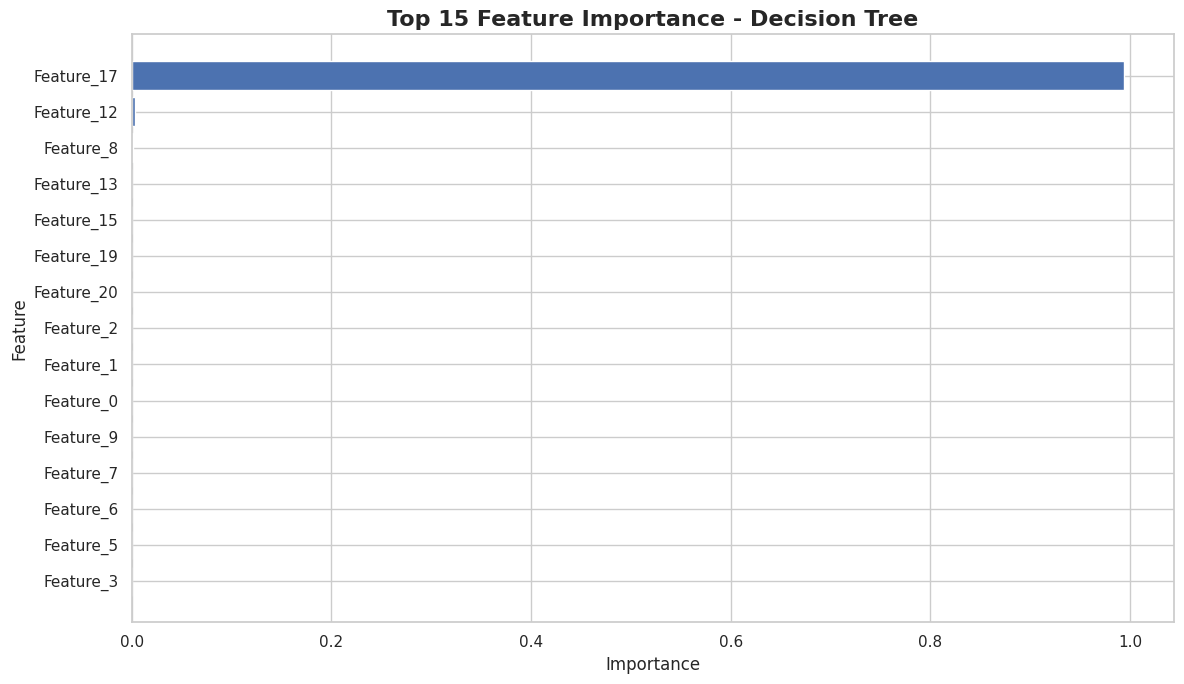


Top Features - Random Forest


,Feature,Importance
0,Feature_17,0.377529
1,Feature_12,0.206006
2,Feature_9,0.188282
3,Feature_8,0.073279
4,Feature_10,0.037447
5,Feature_30,0.023757
6,Feature_16,0.014932
7,Feature_29,0.011879
8,Feature_2,0.010361
9,Feature_11,0.010331


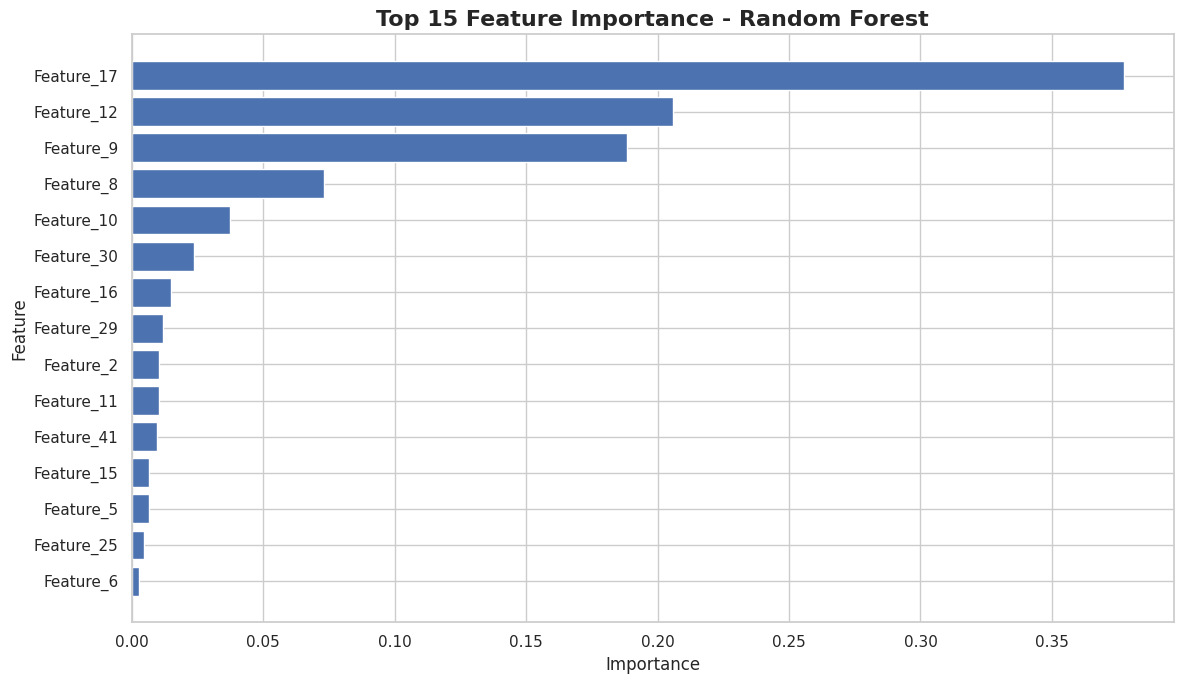


Top Features - Extra Trees


,Feature,Importance
0,Feature_17,0.320240
1,Feature_9,0.210867
2,Feature_12,0.176693
3,Feature_8,0.088898
4,Feature_10,0.045241
5,Feature_30,0.022087
6,Feature_16,0.018040
7,Feature_11,0.014445
8,Feature_29,0.012569
9,Feature_2,0.012000


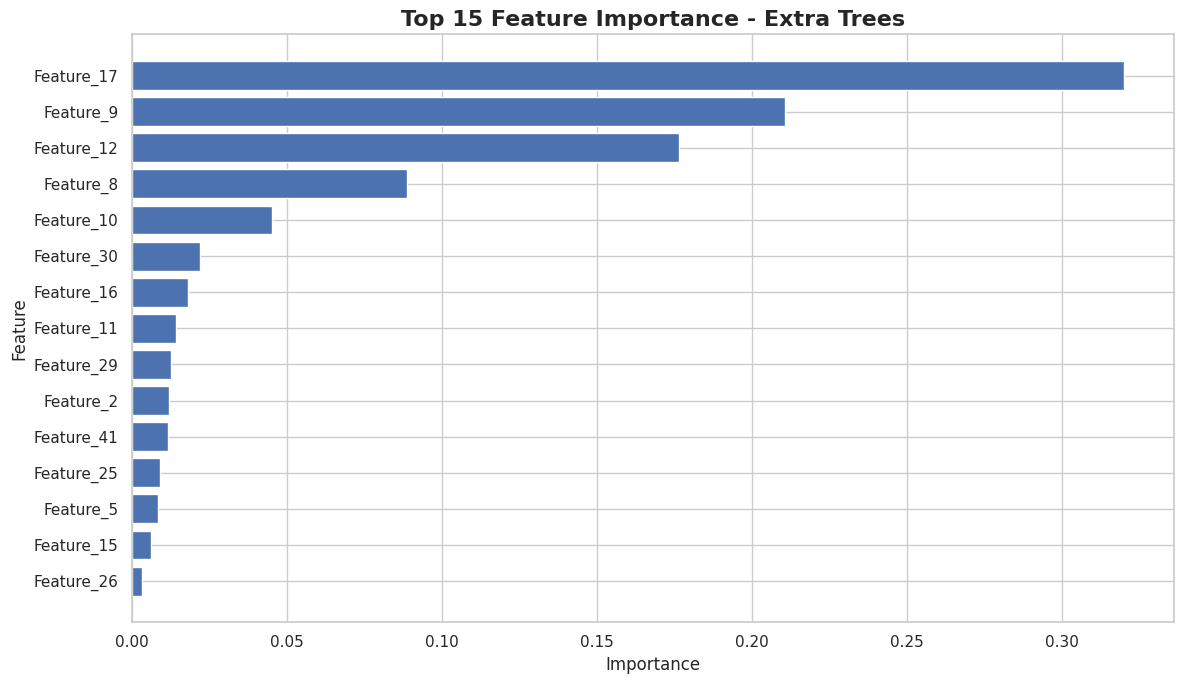


Top Features - Gradient Boosting


,Feature,Importance
0,Feature_17,0.994559
1,Feature_12,0.001676
2,Feature_9,0.001505
3,Feature_8,0.001422
4,Feature_13,0.000286
5,Feature_16,0.000168
6,Feature_15,0.000108
7,Feature_21,0.000069
8,Feature_19,0.000050
9,Feature_23,0.000046


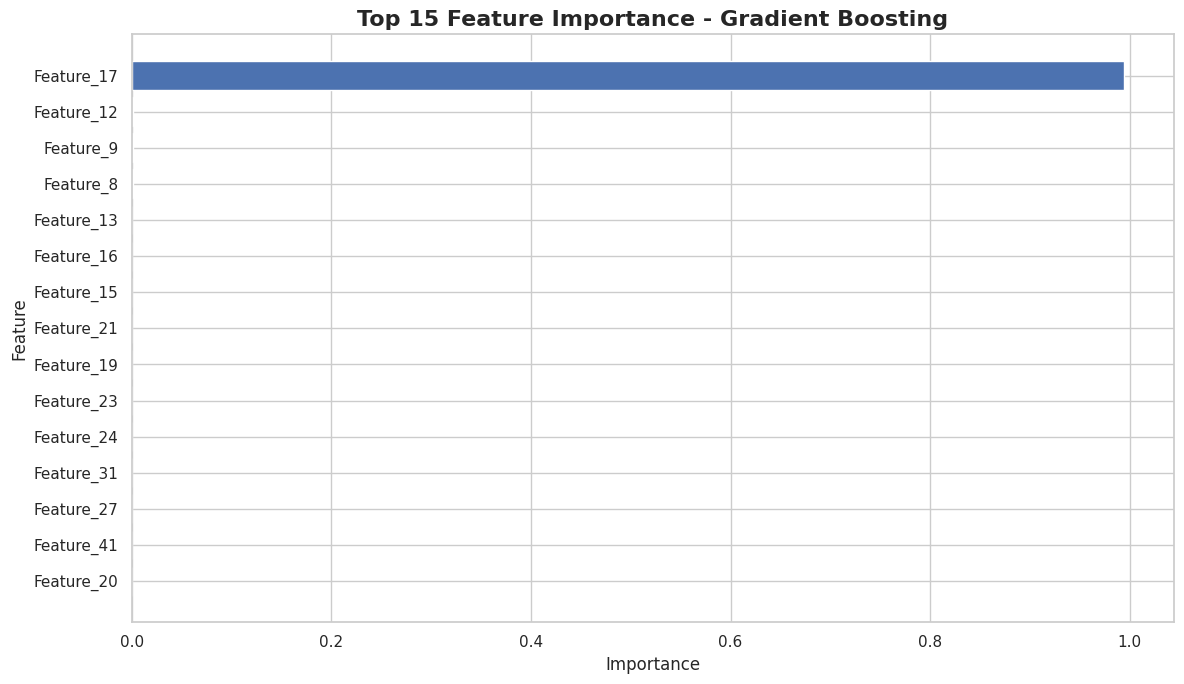


Top Features - XGBoost


,Feature,Importance
0,Feature_17,0.360454
1,Feature_9,0.142593
2,Feature_12,0.116076
3,Feature_30,0.107582
4,Feature_8,0.088707
5,Feature_25,0.057366
6,Feature_11,0.020973
7,Feature_5,0.020870
8,Feature_2,0.020788
9,Feature_10,0.013166


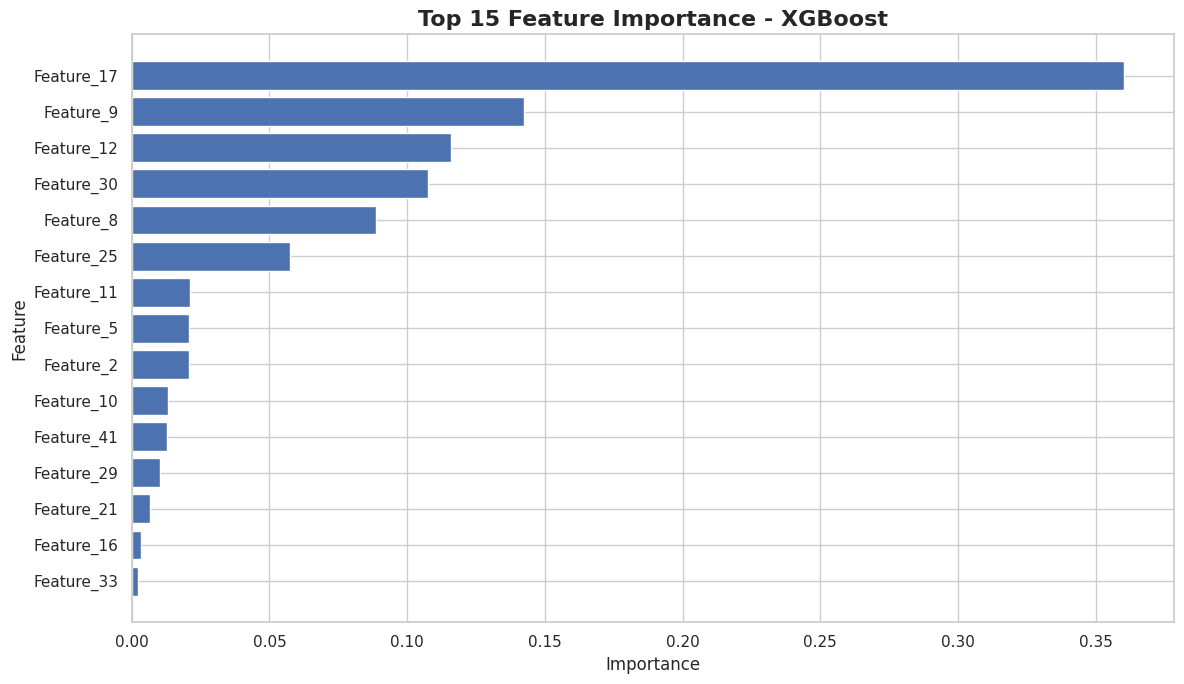


Top Features - LightGBM


,Feature,Importance
0,Feature_17,3632
1,Feature_9,1347
2,Feature_8,1249
3,Feature_2,1097
4,Feature_0,1005
5,Feature_7,723
6,Feature_10,699
7,Feature_11,697
8,Feature_4,668
9,Feature_20,556


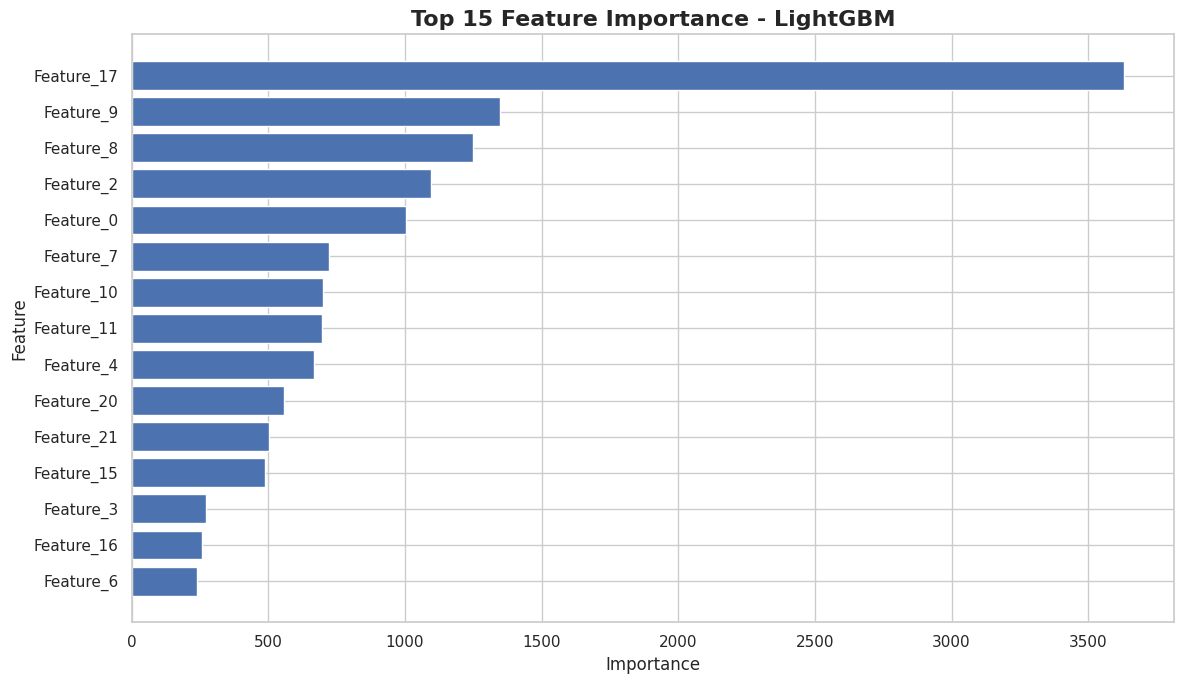


Top Features - CatBoost


,Feature,Importance
0,Feature_17,95.119580
1,Feature_9,1.319327
2,Feature_8,1.124548
3,Feature_12,0.575188
4,Feature_16,0.192277
5,Feature_19,0.115315
6,Feature_3,0.105553
7,Feature_15,0.095456
8,Feature_7,0.084585
9,Feature_21,0.081717


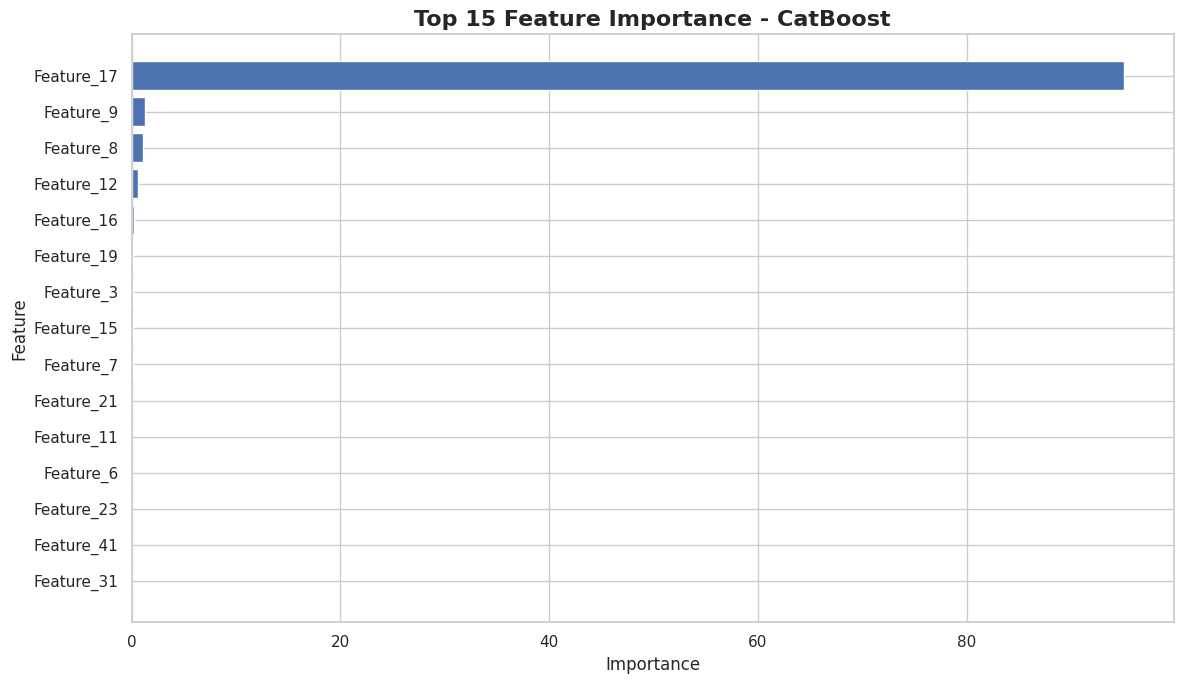


MODEL PERFORMANCE SUMMARY
Highest Accuracy Model : Extra Trees
Accuracy               : 1.0000
F1 Score               : 1.0000
ROC AUC                : 1.0000

ACTUAL VS PREDICTED


,Actual,Predicted
0,Medium,Medium
1,Medium,Medium
2,High,High
3,Low,Low
4,Medium,Medium
5,Medium,Medium
6,Low,Low
7,High,High
8,Low,Low
9,Medium,Medium


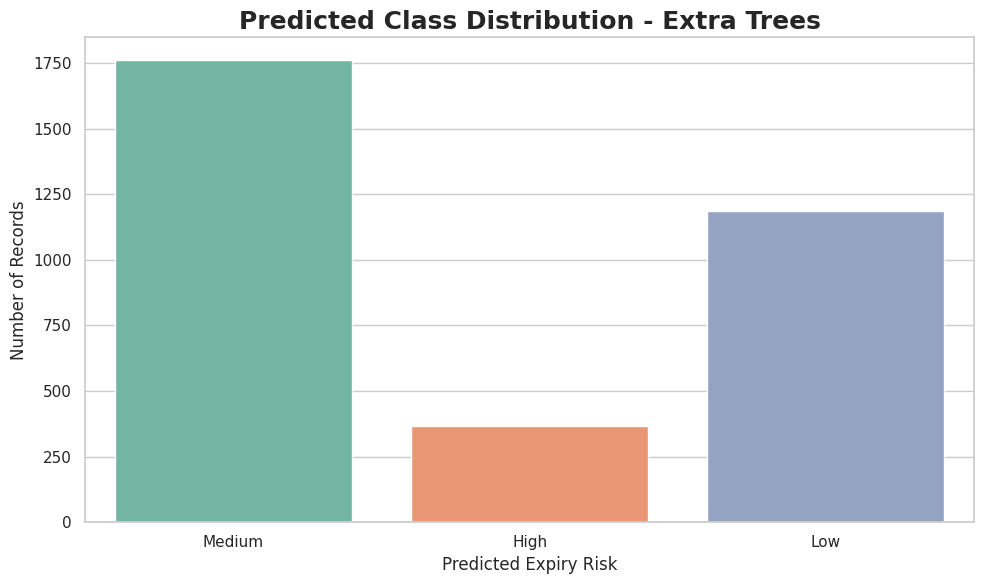


FINAL MODEL SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Extra Trees,1.000000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,LightGBM,0.999698,0.999698,0.999698,0.999698,0.999999
3,Random Forest,0.999698,0.999698,0.999698,0.999698,1.000000
4,CatBoost,0.999396,0.999396,0.999396,0.999396,0.999999
5,Decision Tree,0.999095,0.999096,0.999095,0.999094,0.999035
6,Gradient Boosting,0.998793,0.998793,0.998793,0.998793,0.999998
7,Logistic Regression,0.995775,0.995779,0.995775,0.995773,0.999849
8,KNN,0.852746,0.863378,0.852746,0.849084,0.947560



PIPELINE VALIDATION
Original dataset rows     : 16569
Rows after target cleaning: 16569
Training rows             : 13255
Testing rows              : 3314
Processed features        : 42
Feature names             : 42
Number of models          : 9
Target classes            : 3

Machine Learning pipeline completed successfully.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

# Optional ML algorithms
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgb_available = True
except:
    lgb_available = False

try:
    from catboost import CatBoostClassifier
    cat_available = True
except:
    cat_available = False


# ================================================================
# 1. CHECK DATASET
# ================================================================

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


# ================================================================
# 2. SELECT TARGET
# ================================================================

TARGET = "Expiry_Risk"

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} column not found in dataframe.")

print("\nTarget Column:", TARGET)

print("\nTarget Distribution:")
print(df[TARGET].value_counts(dropna=False))


# ================================================================
# 3. REMOVE TARGET MISSING VALUES
# ================================================================

data = df.copy()

data = data.dropna(subset=[TARGET])

print("\nDataset after removing target missing values:")
print(data.shape)


# ================================================================
# 4. REMOVE ID COLUMNS
# ================================================================

id_columns = [
    "Transaction_ID",
    "Customer_ID",
    "Store_ID",
    "Employee_ID"
]

id_columns = [
    col for col in id_columns
    if col in data.columns
]

data = data.drop(
    columns=id_columns,
    errors="ignore"
)


# ================================================================
# 5. DATE FEATURE ENGINEERING
# ================================================================

if "Date" in data.columns:

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="coerce"
    )

    data["Transaction_Year"] = data["Date"].dt.year
    data["Transaction_Month"] = data["Date"].dt.month
    data["Transaction_Day"] = data["Date"].dt.day
    data["Transaction_DayOfYear"] = data["Date"].dt.dayofyear

    data = data.drop(
        columns=["Date"]
    )


# ================================================================
# 6. TIME FEATURE ENGINEERING
# ================================================================

if "Time" in data.columns:

    time_data = pd.to_datetime(
        data["Time"],
        errors="coerce"
    )

    data["Transaction_Hour"] = time_data.dt.hour
    data["Transaction_Minute"] = time_data.dt.minute

    data = data.drop(
        columns=["Time"]
    )


# ================================================================
# 7. MANUFACTURING / EXPIRY DATE FEATURES
# ================================================================

for date_col in [
    "Manufacturing_Date",
    "Expiry_Date"
]:

    if date_col in data.columns:

        data[date_col] = pd.to_datetime(
            data[date_col],
            errors="coerce"
        )

        data[f"{date_col}_Year"] = (
            data[date_col].dt.year
        )

        data[f"{date_col}_Month"] = (
            data[date_col].dt.month
        )

        data[f"{date_col}_Day"] = (
            data[date_col].dt.day
        )

        data = data.drop(
            columns=[date_col]
        )


# ================================================================
# 8. X AND Y
# ================================================================

X = data.drop(
    columns=[TARGET]
)

y = data[TARGET].copy()

print("\nFeature Shape:", X.shape)
print("Target Shape :", y.shape)


# ================================================================
# 9. ENCODE TARGET
# ================================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print("\nTarget Classes:")

for i, cls in enumerate(
    target_encoder.classes_
):
    print(i, "=", cls)

print("\nEncoded Target Distribution:")

print(
    pd.Series(y)
    .value_counts()
    .sort_index()
)


# ================================================================
# 10. IDENTIFY FEATURES
# ================================================================

numeric_features = X.select_dtypes(
    include=[
        "number"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("\nNumber of Numerical Features:")
print(len(numeric_features))

print("\nNumerical Features:")
print(numeric_features)

print("\nNumber of Categorical Features:")
print(len(categorical_features))

print("\nCategorical Features:")
print(categorical_features)


# ================================================================
# 11. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ================================================================
# 12. NUMERICAL IMPUTATION
# ================================================================

if len(numeric_features) > 0:

    numeric_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_num = numeric_imputer.fit_transform(
        X_train[numeric_features]
    )

    X_test_num = numeric_imputer.transform(
        X_test[numeric_features]
    )

else:

    X_train_num = np.empty(
        (len(X_train), 0)
    )

    X_test_num = np.empty(
        (len(X_test), 0)
    )


# ================================================================
# 13. CATEGORICAL IMPUTATION
# ================================================================

if len(categorical_features) > 0:

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X_train_cat = categorical_imputer.fit_transform(
        X_train[categorical_features]
    )

    X_test_cat = categorical_imputer.transform(
        X_test[categorical_features]
    )

else:

    X_train_cat = np.empty(
        (len(X_train), 0)
    )

    X_test_cat = np.empty(
        (len(X_test), 0)
    )


# ================================================================
# 14. CATEGORICAL LABEL ENCODING
# ================================================================

X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=categorical_features,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=categorical_features,
    index=X_test.index
)

label_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    train_values = (
        X_train_cat_df[col]
        .astype(str)
    )

    le.fit(train_values)

    known_classes = set(
        le.classes_
    )

    X_train_cat_df[col] = (
        X_train_cat_df[col]
        .astype(str)
        .map(
            lambda x:
            le.transform([x])[0]
            if x in known_classes
            else -1
        )
    )

    X_test_cat_df[col] = (
        X_test_cat_df[col]
        .astype(str)
        .map(
            lambda x:
            le.transform([x])[0]
            if x in known_classes
            else -1
        )
    )

    label_encoders[col] = le


# ================================================================
# 15. COMBINE FEATURES
# ================================================================

X_train_processed = np.hstack(
    [
        X_train_num,
        X_train_cat_df.values
    ]
)

X_test_processed = np.hstack(
    [
        X_test_num,
        X_test_cat_df.values
    ]
)


# ================================================================
# IMPORTANT FIX
# CREATE FEATURE NAMES FROM ACTUAL PROCESSED MATRIX
# ================================================================

feature_names = (
    numeric_features +
    categorical_features
)

# Safety check
if len(feature_names) != X_train_processed.shape[1]:

    print("\n⚠️ Feature name mismatch detected.")

    print(
        "Feature names:",
        len(feature_names)
    )

    print(
        "Processed columns:",
        X_train_processed.shape[1]
    )

    # Guaranteed matching feature names
    feature_names = [
        f"Feature_{i}"
        for i in range(
            X_train_processed.shape[1]
        )
    ]

else:

    print(
        "\nFeature names correctly matched."
    )


print("\nProcessed Train Shape:")
print(X_train_processed.shape)

print("\nProcessed Test Shape:")
print(X_test_processed.shape)

print(
    "\nTotal Processed Features:",
    len(feature_names)
)


# ================================================================
# 16. FEATURE SCALING
# ================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_processed
)

X_test_scaled = scaler.transform(
    X_test_processed
)

print("\nFeature scaling completed.")


# ================================================================
# 17. NUMBER OF CLASSES
# ================================================================

n_classes = len(
    np.unique(y)
)

print(
    "\nNumber of Classes:",
    n_classes
)

print(
    "Classes:",
    target_encoder.classes_
)


# ================================================================
# 18. CREATE MODELS
# ================================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        )
}


# ================================================================
# 19. XGBOOST
# ================================================================

if xgb_available:

    if n_classes == 2:

        models["XGBoost"] = XGBClassifier(

            n_estimators=200,

            max_depth=6,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric="logloss",

            random_state=42
        )

    else:

        models["XGBoost"] = XGBClassifier(

            n_estimators=200,

            max_depth=6,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            objective="multi:softprob",

            num_class=n_classes,

            eval_metric="mlogloss",

            random_state=42
        )


# ================================================================
# 20. LIGHTGBM
# ================================================================

if lgb_available:

    if n_classes == 2:

        models["LightGBM"] = LGBMClassifier(

            n_estimators=200,

            learning_rate=0.05,

            max_depth=8,

            random_state=42,

            verbose=-1
        )

    else:

        models["LightGBM"] = LGBMClassifier(

            n_estimators=200,

            learning_rate=0.05,

            max_depth=8,

            objective="multiclass",

            num_class=n_classes,

            random_state=42,

            verbose=-1
        )


# ================================================================
# 21. CATBOOST
# ================================================================

if cat_available:

    models["CatBoost"] = CatBoostClassifier(

        iterations=200,

        depth=7,

        learning_rate=0.05,

        verbose=False,

        random_state=42
    )


# ================================================================
# 22. TRAIN ALL MODELS
# ================================================================

results = []

trained_models = {}

prediction_probabilities = {}

predictions = {}


print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)


for name, model in models.items():

    print(
        f"\nTraining: {name}"
    )

    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model


    # ------------------------------------------------
    # PREDICTION
    # ------------------------------------------------

    y_pred = model.predict(
        X_test_scaled
    )

    predictions[name] = y_pred


    # ------------------------------------------------
    # PROBABILITY
    # ------------------------------------------------

    if hasattr(
        model,
        "predict_proba"
    ):

        y_probability = (
            model.predict_proba(
                X_test_scaled
            )
        )

        prediction_probabilities[
            name
        ] = y_probability

    else:

        prediction_probabilities[
            name
        ] = None


    # ====================================================
    # METRICS
    # ====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # ====================================================
    # ROC AUC
    # ====================================================

    roc_auc = np.nan

    if prediction_probabilities[name] is not None:

        try:

            if n_classes == 2:

                roc_auc = roc_auc_score(

                    y_test,

                    prediction_probabilities[
                        name
                    ][:, 1]
                )

            else:

                roc_auc = roc_auc_score(

                    y_test,

                    prediction_probabilities[
                        name
                    ],

                    multi_class="ovr",

                    average="weighted"
                )

        except Exception as e:

            print(
                "ROC AUC error:",
                e
            )


    # ====================================================
    # SAVE RESULTS
    # ====================================================

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })


    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    if not np.isnan(roc_auc):

        print(
            f"ROC AUC   : {roc_auc:.4f}"
        )


# ================================================================
# 23. MODEL COMPARISON
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(
    drop=True
)


print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC AUC": "{:.4f}"

    })
)


# ================================================================
# 24. ACCURACY COMPARISON
# ================================================================

plt.figure(
    figsize=(14, 7)
)

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model",

    hue="Model",

    palette="viridis",

    legend=False
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Accuracy"
)

plt.ylabel(
    "Machine Learning Model"
)

plt.xlim(
    max(
        0,
        results_df["Accuracy"].min() - 0.05
    ),
    1.0
)

for i, value in enumerate(
    results_df["Accuracy"]
):

    plt.text(

        value + 0.005,

        i,

        f"{value:.2%}",

        va="center",

        fontweight="bold"
    )

plt.tight_layout()

plt.show()


# ================================================================
# 25. PRECISION / RECALL / F1
# ================================================================

metrics_long = results_df.melt(

    id_vars="Model",

    value_vars=[
        "Precision",
        "Recall",
        "F1 Score"
    ],

    var_name="Metric",

    value_name="Score"
)


plt.figure(
    figsize=(14, 7)
)

sns.barplot(

    data=metrics_long,

    x="Model",

    y="Score",

    hue="Metric",

    palette="Set2"
)

plt.title(
    "Precision, Recall and F1 Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=35
)

plt.ylim(
    0,
    1.05
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

plt.show()


# ================================================================
# 26. CONFUSION MATRIX
# ================================================================

for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(
        figsize=(8, 6)
    )

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=target_encoder.classes_,

        yticklabels=target_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "Actual Label"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 27. CLASSIFICATION REPORT
# ================================================================

for name, y_pred in predictions.items():

    print("\n")

    print("=" * 80)

    print(
        f"CLASSIFICATION REPORT - {name}"
    )

    print("=" * 80)

    print(

        classification_report(

            y_test,

            y_pred,

            target_names=[
                str(x)
                for x in target_encoder.classes_
            ],

            zero_division=0
        )
    )


# ================================================================
# 28. ROC CURVE
# ================================================================

if n_classes == 2:

    plt.figure(
        figsize=(12, 8)
    )

    for name, probabilities in (
        prediction_probabilities.items()
    ):

        if probabilities is None:
            continue

        fpr, tpr, thresholds = roc_curve(

            y_test,

            probabilities[:, 1]
        )

        roc_auc_value = auc(
            fpr,
            tpr
        )

        plt.plot(

            fpr,

            tpr,

            linewidth=3,

            label=(
                f"{name} "
                f"(AUC = {roc_auc_value:.4f})"
            )
        )


    # Random classifier

    plt.plot(

        [0, 1],

        [0, 1],

        linestyle="--",

        linewidth=2,

        label="Random Classifier"
    )


    plt.xlabel(
        "False Positive Rate",
        fontsize=13
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=13
    )

    plt.title(

        "ROC Curve - All Machine Learning Models",

        fontsize=18,

        fontweight="bold"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 29. MULTICLASS ROC CURVE
# ================================================================

else:

    for name, probabilities in (
        prediction_probabilities.items()
    ):

        if probabilities is None:
            continue

        plt.figure(
            figsize=(10, 8)
        )

        for class_index in range(
            n_classes
        ):

            y_binary = (
                y_test == class_index
            ).astype(int)

            fpr, tpr, thresholds = roc_curve(

                y_binary,

                probabilities[:, class_index]
            )

            roc_auc_value = auc(
                fpr,
                tpr
            )

            plt.plot(

                fpr,

                tpr,

                linewidth=3,

                label=(

                    f"{target_encoder.classes_[class_index]} "

                    f"(AUC = {roc_auc_value:.4f})"
                )
            )


        plt.plot(

            [0, 1],

            [0, 1],

            linestyle="--",

            linewidth=2,

            label="Random Classifier"
        )

        plt.xlabel(
            "False Positive Rate",
            fontsize=13
        )

        plt.ylabel(
            "True Positive Rate",
            fontsize=13
        )

        plt.title(

            f"ROC Curve - {name}",

            fontsize=18,

            fontweight="bold"
        )

        plt.legend(
            loc="lower right"
        )

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        plt.show()


# ================================================================
# 30. RANDOM FOREST FEATURE IMPORTANCE - FIXED
# ================================================================

print("\n" + "=" * 80)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 80)


if "Random Forest" in trained_models:

    rf_model = trained_models[
        "Random Forest"
    ]

    # Get actual importance values
    rf_importance_values = (
        rf_model.feature_importances_
    )

    print(
        "Number of feature names:",
        len(feature_names)
    )

    print(
        "Number of importance values:",
        len(rf_importance_values)
    )


    # ------------------------------------------------
    # FINAL SAFETY CHECK
    # ------------------------------------------------

    if len(feature_names) != len(
        rf_importance_values
    ):

        print(
            "\n⚠️ Mismatch detected."
        )

        print(
            "Creating automatic feature names."
        )

        rf_feature_names = [

            f"Feature_{i}"

            for i in range(
                len(rf_importance_values)
            )
        ]

    else:

        rf_feature_names = feature_names


    # ------------------------------------------------
    # CREATE DATAFRAME
    # ------------------------------------------------

    rf_importance = pd.DataFrame({

        "Feature": rf_feature_names,

        "Importance": rf_importance_values

    })


    # ------------------------------------------------
    # SORT
    # ------------------------------------------------

    rf_importance = rf_importance.sort_values(

        by="Importance",

        ascending=False

    ).reset_index(
        drop=True
    )


    # ------------------------------------------------
    # DISPLAY TOP 30
    # ------------------------------------------------

    display(
        rf_importance.head(30)
    )


    # ------------------------------------------------
    # PLOT TOP 20
    # ------------------------------------------------

    top_rf_features = (
        rf_importance.head(20)
    )

    plt.figure(
        figsize=(12, 8)
    )

    plt.barh(

        top_rf_features[
            "Feature"
        ][::-1],

        top_rf_features[
            "Importance"
        ][::-1],

        color="teal"
    )

    plt.xlabel(
        "Feature Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(

        "Top 20 Random Forest Feature Importance",

        fontsize=18,

        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 31. FEATURE IMPORTANCE FOR ALL TREE MODELS
# ================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE - ALL TREE MODELS")
print("=" * 80)


tree_models = [

    "Decision Tree",

    "Random Forest",

    "Extra Trees",

    "Gradient Boosting",

    "XGBoost",

    "LightGBM",

    "CatBoost"

]


for model_name in tree_models:

    if model_name not in trained_models:
        continue

    model = trained_models[
        model_name
    ]

    if not hasattr(
        model,
        "feature_importances_"
    ):
        continue

    importance_values = (
        model.feature_importances_
    )


    # ------------------------------------------------
    # SAFETY CHECK
    # ------------------------------------------------

    if len(feature_names) == len(
        importance_values
    ):

        current_feature_names = (
            feature_names
        )

    else:

        current_feature_names = [

            f"Feature_{i}"

            for i in range(
                len(importance_values)
            )
        ]


    importance_df = pd.DataFrame({

        "Feature":
            current_feature_names,

        "Importance":
            importance_values

    })


    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    print(
        f"\nTop Features - {model_name}"
    )

    display(
        importance_df.head(15)
    )


    # ------------------------------------------------
    # PLOT
    # ------------------------------------------------

    top_features = (
        importance_df.head(15)
    )

    plt.figure(
        figsize=(12, 7)
    )

    plt.barh(

        top_features[
            "Feature"
        ][::-1],

        top_features[
            "Importance"
        ][::-1]
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(

        f"Top 15 Feature Importance - {model_name}",

        fontsize=16,

        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 32. MODEL PERFORMANCE SUMMARY
# ================================================================

best_model_name = (
    results_df.iloc[0]["Model"]
)

best_accuracy = (
    results_df.iloc[0]["Accuracy"]
)

best_f1 = (
    results_df.iloc[0]["F1 Score"]
)

best_auc = (
    results_df.iloc[0]["ROC AUC"]
)


print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

print(
    f"Highest Accuracy Model : "
    f"{best_model_name}"
)

print(
    f"Accuracy               : "
    f"{best_accuracy:.4f}"
)

print(
    f"F1 Score               : "
    f"{best_f1:.4f}"
)

if not pd.isna(best_auc):

    print(
        f"ROC AUC                : "
        f"{best_auc:.4f}"
    )


# ================================================================
# 33. ACTUAL VS PREDICTED
# ================================================================

best_predictions = predictions[
    best_model_name
]


comparison_df = pd.DataFrame({

    "Actual":

        target_encoder.inverse_transform(
            y_test
        ),

    "Predicted":

        target_encoder.inverse_transform(
            best_predictions
        )

})


print("\n" + "=" * 80)
print("ACTUAL VS PREDICTED")
print("=" * 80)

display(
    comparison_df.head(30)
)


# ================================================================
# 34. PREDICTION DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(10, 6)
)

sns.countplot(

    x=comparison_df["Predicted"],

    hue=comparison_df["Predicted"],

    palette="Set2",

    legend=False
)

plt.title(

    f"Predicted Class Distribution - "
    f"{best_model_name}",

    fontsize=18,

    fontweight="bold"
)

plt.xlabel(
    "Predicted Expiry Risk"
)

plt.ylabel(
    "Number of Records"
)

plt.tight_layout()

plt.show()


# ================================================================
# 35. FINAL SUMMARY TABLE
# ================================================================

print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)

final_summary = results_df.copy()

display(
    final_summary
)


# ================================================================
# 36. FINAL DATA VALIDATION
# ================================================================

print("\n" + "=" * 80)
print("PIPELINE VALIDATION")
print("=" * 80)

print(
    "Original dataset rows     :",
    len(df)
)

print(
    "Rows after target cleaning:",
    len(data)
)

print(
    "Training rows             :",
    len(X_train)
)

print(
    "Testing rows              :",
    len(X_test)
)

print(
    "Processed features        :",
    X_train_processed.shape[1]
)

print(
    "Feature names             :",
    len(feature_names)
)

print(
    "Number of models          :",
    len(trained_models)
)

print(
    "Target classes            :",
    n_classes
)

print("\nMachine Learning pipeline completed successfully.")

## thank you..pls upvote!!!!!!!!